<div style="font-size: 13px; line-height: 1.25;">

# The Digital Border: Estimating the Impact of Data Localization Laws on the Extensive Margin of Digital (SaaS) Trade Using a Melitz-Type Gravity Framework

## Empirical Chapter — Structural Gravity PPML Estimation

This notebook estimates the partial-equilibrium effect of data localization regulations on bilateral services trade using a structural gravity framework with PPML (Poisson Pseudo-Maximum Likelihood) estimation. The empirical strategy follows Yotov et al. (2016), *An Advanced Guide to Trade Policy Analysis*, which establishes PPML with high-dimensional fixed effects as the consistent estimator for the structural gravity equation derived from Anderson and van Wincoop (2003) and Arkolakis, Costinot and Rodriguez-Clare (2012).

### Research question

The thesis asks whether data localization measures — laws that compel firms to store, process, or route data within the regulating jurisdiction — depress digital services trade, and through which margin. The Melitz (2003) framework with heterogeneous firms predicts that fixed regulatory compliance costs raise the productivity threshold for foreign firms to serve a market, contracting the *extensive margin* (the set of firms that find it profitable to export). PPML on the level of bilateral trade in digital services categories absorbs both intensive- and extensive-margin variation; the present chapter estimates the combined effect, while a companion specification using Probit/Logit on the binary entry indicator isolates the extensive-margin channel.

### Empirical strategy

The structural gravity equation in PPML form is

$$
X_{ij,k,t} = \exp\!\Big[\pi_{i,k,t} + \chi_{j,k,t} + \mu_{ij,k} + \beta\,\text{DLR}_{j,k,t} + \gamma'\mathbf{Z}_{ij}\Big]\varepsilon_{ij,k,t}
$$

where $X_{ij,k,t}$ is the value of services trade in BPM6 category $k$ from exporter $i$ to importer $j$ in year $t$. The three sets of fixed effects absorb (i) outward multilateral resistance and exporter-side market size at the product–year level ($\pi_{i,k,t}$), (ii) inward multilateral resistance and importer-side expenditure at the product–year level ($\chi_{j,k,t}$), and (iii) all time-invariant bilateral characteristics — distance, contiguity, common language, colonial ties, historical pair-specific selection ($\mu_{ij,k}$). With this fixed-effects structure, identification of $\beta$ comes purely from *within-pair, within-product, over-time* variation in the regulation indicator $\text{DLR}_{j,k,t}$, ruling out essentially all standard sources of omitted-variable bias.

### Data

The notebook consumes the merged dataset produced by `dti_comtrade_merge.ipynb`, which combines:

* **UN Comtrade EBOPS-mapped services trade** — bilateral trade flows (reporter × partner × service-category × year), where service categories are mapped to the 14 BPM6 main components and the 9.1/9.2/9.3 telecom-computer-information sub-decomposition.
* **DTI regulation flags** — binary effect flags and counts derived from the Ferracane–van der Marel (2024) Digital Trade Integration database, brought in at the reporter × service-category × year level. Each pillar (1–12) contributes its own flag column, with pillar 6 disaggregated to subpillars 6.1–6.5. Each flag exists in both `_neg` (restrictive) and `_pos` (enabling) variants.

The unit of observation is the bilateral reporter × partner × bpm6_category × year tuple. Because the regulations attach to the *reporter* (the regulating jurisdiction) and Comtrade's reporter is the importer in the trade flow, the DLR variable enters the gravity equation indexed on $j$, the importer.

### What this notebook does

1. Loads and inspects the merged dataset.
2. Constructs gravity-ready identifiers: importer-product-time, exporter-product-time, importer-exporter-product, and a symmetric pair_id for clustering.
3. Optionally enriches the data with CEPII GeoDist gravity controls (distance, contiguity, common official language, colonial ties).
4. Produces descriptive statistics and publication-quality figures for the empirical chapter.
5. Estimates a baseline PPML structural gravity model and three robustness specifications using `fixest::fepois`.
6. Performs post-estimation diagnostics (pseudo-$R^2$, residual plots, overdispersion check, RESET test) and exports tables and plots.

### Table of contents

* [**SECTION 0** — Setup and configuration](#section-0)
* [**SECTION 1** — Data loading and preparation](#section-1)
* [**SECTION 2** — Descriptive statistics and exploratory analysis](#section-2)
* [**SECTION 3** — PPML estimation](#section-3)
  * 3a — Baseline structural gravity PPML
  * 3b — Robustness and extensions (Models 2-8)
  * 3c — Results table (headline)
  * 3d — Classic structural gravity with CEPII trade-cost controls
* [**SECTION 4** — Post-estimation diagnostics](#section-4)
* [**SECTION 5** — Export](#section-5)

</div>

<a id="section-0"></a>
<div style="font-size: 25px; line-height: 1.25;">
SECTION 0 — SETUP AND CONFIGURATION
</div>

This section loads all R packages used in the notebook and defines a single configuration block at the top, holding every file path and global parameter. Centralising configuration up front makes the notebook portable across machines and trivial to point at a new dataset version.

The packages serve four purposes:

* **Data manipulation** — `dplyr`, `tidyr`, `stringr`, `lubridate`, `purrr` provide the standard tidyverse pipeline for reshaping, joining, and cleaning the merged data frame.
* **Estimation** — `fixest` provides `fepois()`, the PPML estimator with high-dimensional fixed effects via the demeaning algorithm of Berge (2018). For a structural gravity application with three sets of fixed effects, each containing several thousand levels, `fepois` is essentially the only practical choice in R: alternatives based on `glm` or `glmmTMB` either fail or run for hours. `fixest` also provides robust and clustered standard errors out of the box and integrates cleanly with `etable` and `modelsummary` for publication-grade output.
* **Visualisation** — `ggplot2` for plots, with `scales`, `viridis`, and `ggthemes` for consistent theming. `patchwork` arranges multi-panel figures.
* **Reporting** — `modelsummary` and `kableExtra` produce side-by-side regression tables in HTML and LaTeX. `gt` is used for descriptive-statistics tables.

The configuration block at the bottom of the cell defines (i) input paths — the merged dataset and the optional CEPII GeoDist file — and (ii) output paths for tables, figures, and saved model objects. All downstream code references these constants, never hard-coded paths.

In [1]:
# --- Required packages --------------------------------------------------------

required_packages <- c(
  # Data manipulation
  "dplyr", "tidyr", "stringr", "lubridate", "purrr", "readr",
  # Estimation
  "fixest",
  # Visualisation
  "ggplot2", "scales", "viridis", "ggthemes", "patchwork",
  # Reporting
  "modelsummary", "kableExtra", "gt"
)

for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

options(jupyter.rich_display = FALSE)
options(scipen = 999)  # avoid scientific notation in printed output

cat("All packages loaded.\n")

# --- Configuration block ------------------------------------------------------

# Input: merged DTI × Comtrade dataset produced by dti_comtrade_merge.ipynb
MERGED_CSV <- "../data/final_dataset/comtrade_dti_final.csv"

# CEPII Gravity database subset (produced by cepii_preprocess.R, run once).
# If the file is missing, the notebook proceeds without classic-gravity
# controls; pair-product FE absorb the time-invariant trade-cost components.
CEPII_GRAVITY_CSV <- "../data/final_dataset/cepii_gravity_subset.csv"

# Output paths
OUTPUT_DIR     <- "../outputs/gravity_results"
TABLES_DIR     <- file.path(OUTPUT_DIR, "tables")
FIGURES_DIR    <- file.path(OUTPUT_DIR, "figures")
MODELS_RDS       <- file.path(OUTPUT_DIR, "fitted_models.rds")
FINAL_DATA_RDS   <- file.path(OUTPUT_DIR, "gravity_dataset.rds")
ALL_RESULTS_XLSX <- file.path(TABLES_DIR, "all_results_consolidated.xlsx")
ALL_RESULTS_CSV  <- file.path(TABLES_DIR, "all_results_long.csv")

# Create output directories if missing
for (d in c(OUTPUT_DIR, TABLES_DIR, FIGURES_DIR)) {
  if (!dir.exists(d)) dir.create(d, recursive = TRUE)
}

# --- Global parameters --------------------------------------------------------

# The "primary" data-localization policy variable for the headline specification.
# 6.1 = Ban-on-transfer-and-local-processing-requirement is the most clear-cut
# DLR; 6.2 = Local storage requirement is the next-most-direct instrument.
PRIMARY_DLR_FLAG <- "p6_1_neg_effect"

# All neg/pos effect-flag column ids that the merge produced.
ALL_FLAG_COLS <- c("p1", "p2", "p3", "p4", "p5",
                   "p6_1", "p6_2", "p6_3", "p6_4", "p6_5",
                   "p7", "p8", "p9", "p10", "p11", "p12")

# BPM6 service categories considered "digital" for the SaaS-trade definition.
# 9.1 = Telecommunications, 9.2 = Computer services, 9.3 = Information services.
DIGITAL_BPM6_CATS <- c("Telecom_9_1", "Telecom_9_2", "Telecom_9_3",
                       "Charges_for_intellectual_property",
                       "Other_business_services")

# ggplot publication theme — used throughout the notebook for consistency.
theme_thesis <- function(base_size = 11) {
  theme_minimal(base_size = base_size) +
    theme(
      plot.title       = element_text(face = "bold", size = base_size + 2,
                                       margin = margin(b = 8)),
      plot.subtitle    = element_text(colour = "grey30",
                                       margin = margin(b = 12)),
      plot.margin      = margin(t = 14, r = 14, b = 10, l = 10),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(colour = "grey92"),
      axis.title.x     = element_text(face = "bold", margin = margin(t = 8)),
      axis.title.y     = element_text(face = "bold", margin = margin(r = 8)),
      legend.position  = "bottom",
      legend.margin    = margin(t = 6),
      legend.box.margin = margin(t = 4),
      strip.text       = element_text(face = "bold")
    )
}
theme_set(theme_thesis())

cat("\nConfiguration complete.\n")
cat(sprintf("  Input data:      %s\n", MERGED_CSV))
cat(sprintf("  Output tables:   %s\n", TABLES_DIR))
cat(sprintf("  Output figures:  %s\n", FIGURES_DIR))
cat(sprintf("  Primary DLR:     %s\n", PRIMARY_DLR_FLAG))

Warning message:
"package 'lubridate' was built under R version 4.5.1"
Warning message:
"package 'fixest' was built under R version 4.5.3"
Warning message:
"package 'viridis' was built under R version 4.5.3"
Warning message:
"package 'ggthemes' was built under R version 4.5.3"
Warning message:
"package 'patchwork' was built under R version 4.5.3"
Warning message:
"package 'modelsummary' was built under R version 4.5.3"
Warning message:
"package 'kableExtra' was built under R version 4.5.3"
Warning message:
"package 'gt' was built under R version 4.5.3"


All packages loaded.

Configuration complete.
  Input data:      ../data/final_dataset/comtrade_dti_final.csv
  Output tables:   ../outputs/gravity_results/tables
  Output figures:  ../outputs/gravity_results/figures
  Primary DLR:     p6_1_neg_effect


<a id="section-1"></a>
<div style="font-size: 25px; line-height: 1.25;">
SECTION 1 — DATA LOADING AND PREPARATION
</div>

This section loads the merged DTI × Comtrade dataset, audits its structure, and constructs the variables required by the structural gravity specification.

### Unit of observation

A row in the merged dataset is a quadruple $(i, j, k, t)$:

* $i$ — exporter (Comtrade `partnerDesc` for import flows; conversely for export flows)
* $j$ — importer (Comtrade `reporterDesc` for import flows)
* $k$ — BPM6 service category (`bpm6_category`, one of the 14 main components, with telecom split into 9.1/9.2/9.3)
* $t$ — year (`refYear`)

Because the DTI regulations attach to the regulating jurisdiction, and Comtrade's reporter is the country whose statistical office is reporting the flow, the regulation flags are merged at the reporter level. For *import* flows ($M$), the reporter is the importer $j$; for *export* flows ($X$), the reporter is the exporter $i$. The headline specification uses the import sample so that the policy variable $\text{DLR}_{j,k,t}$ is naturally indexed on the destination country, consistent with the Melitz logic that data localization raises fixed market-access costs at the destination.

### Treatment of zeros — why PPML

Bilateral services trade has a heavy mass of zeros — many country-pair-product-year combinations have no recorded trade. The classical log-linearised gravity model ($\log X_{ij} = \cdots$) discards these observations, biasing coefficients (Santos Silva and Tenreyro, 2006). PPML estimates the level equation $X_{ij} = \exp(\cdot)\varepsilon$, which (i) accommodates zeros directly, (ii) is consistent under arbitrary heteroskedasticity in the multiplicative error, and (iii) is the *only* estimator that delivers theoretically-consistent multilateral resistance terms when fixed effects absorb them. We therefore report the PPML estimates as the structural baseline and use OLS-on-logs only as a robustness comparison on the strictly-positive subsample.

### Variables constructed in this section

* `importer`, `exporter` — derived from `reporterDesc` and `partnerDesc` based on `flowCode`.
* `imp_prod_time` — importer-product-time identifier (the $\chi_{j,k,t}$ fixed effect).
* `exp_prod_time` — exporter-product-time identifier (the $\pi_{i,k,t}$ fixed effect).
* `pair_prod` — importer-exporter-product identifier (the $\mu_{ij,k}$ fixed effect).
* `pair_id` — symmetric importer-exporter identifier for clustering standard errors.
* `imp_time` — importer-time identifier for an alternative specification that aggregates across products.
* `dlr` — primary data-localization indicator (`p6_1_neg_effect`).
* `dlr_count` — primary data-localization regulation count (`p6_1_neg_count`).
* `log_trade` — log of trade value (descriptive only; PPML uses levels).
* `has_trade` — binary indicator of positive trade (descriptive only).

In [2]:
# --- 1.1 Load merged dataset --------------------------------------------------

cat("\n--- Loading merged dataset ---\n")

if (exists("full_df_merged") && is.data.frame(full_df_merged) &&
    nrow(full_df_merged) > 0) {
  cat("Using in-memory `full_df_merged` from current R session.\n")
  df <- full_df_merged
} else {
  cat(sprintf("Reading from CSV: %s\n", MERGED_CSV))
  df <- readr::read_csv(MERGED_CSV, show_col_types = FALSE,
                        progress = FALSE, guess_max = 50000)
}

cat(sprintf("Loaded: %s rows x %d columns\n",
            format(nrow(df), big.mark = ","), ncol(df)))

# --- 1.1b Drop aggregate (NA bpm6_category) rows ------------------------------
# bpm6_category = NA flags Comtrade aggregate codes (TOTAL, S, TOEB02, top-level
# 9, top-level SI, C.*) that double-count the disaggregated product-level rows.
# Keeping them in the panel would inflate every descriptive statistic by the
# aggregate-vs-disaggregated overlap and corrupt the gravity fixed effects.
# We drop them here so all downstream code (descriptives AND estimation) sees
# the clean product-level panel.
n_before <- nrow(df)
df <- df %>% filter(!is.na(bpm6_category))
n_dropped <- n_before - nrow(df)
cat(sprintf("Dropped %s aggregate-code rows (NA bpm6_category): %.1f%% of raw load.\n",
            format(n_dropped, big.mark = ","), 100 * n_dropped / n_before))
cat(sprintf("Working panel: %s rows.\n", format(nrow(df), big.mark = ",")))

# --- 1.2 Inspect structure ----------------------------------------------------

cat("\n--- Column overview ---\n")
ct_cols   <- intersect(c("reporterDesc", "partnerDesc", "refYear", "flowCode",
                          "cmdCode", "primaryValue", "bpm6_category",
                          "Tariff_Raw"),
                       names(df))
flag_cols <- grep("(neg|pos)_(effect|count)$", names(df), value = TRUE)
other     <- setdiff(names(df), c(ct_cols, flag_cols))

cat(sprintf("  Comtrade-side columns:    %d (%s)\n",
            length(ct_cols), paste(ct_cols, collapse = ", ")))
cat(sprintf("  DTI flag/count columns:   %d (16 pillars x 4 variants)\n",
            length(flag_cols)))
cat(sprintf("  Other columns:            %d (%s)\n",
            length(other), paste(head(other, 10), collapse = ", ")))

cat("\n--- First 3 rows (key columns) ---\n")
print(head(df %>% select(any_of(c("reporterDesc","partnerDesc","refYear",
                                   "flowCode","bpm6_category","primaryValue",
                                   "p6_1_neg_effect","p6_1_neg_count",
                                   "Tariff_Raw"))), 3))

# --- 1.3 Type and missingness audit ------------------------------------------

cat("\n--- Type / missingness audit on key columns ---\n")
for (col in c("reporterDesc","partnerDesc","refYear","flowCode",
              "bpm6_category","primaryValue", PRIMARY_DLR_FLAG)) {
  if (col %in% names(df)) {
    n_na <- sum(is.na(df[[col]]))
    cat(sprintf("  %-20s type=%-10s NAs=%s\n",
                col, class(df[[col]])[1], format(n_na, big.mark = ",")))
  } else {
    cat(sprintf("  %-20s NOT FOUND in dataset!\n", col))
  }
}

# --- 1.4 Coverage statistics --------------------------------------------------

cat("\n--- Coverage ---\n")
cat(sprintf("  Years covered:        %d–%d (%d unique)\n",
            min(df$refYear, na.rm=TRUE), max(df$refYear, na.rm=TRUE),
            n_distinct(df$refYear)))
cat(sprintf("  Unique reporters:     %d\n", n_distinct(df$reporterDesc)))
cat(sprintf("  Unique partners:      %d\n", n_distinct(df$partnerDesc)))
cat(sprintf("  BPM6 categories:      %d\n",
            n_distinct(df$bpm6_category, na.rm = TRUE)))
cat(sprintf("  Trade-flow directions: %s\n",
            paste(sort(unique(df$flowCode)), collapse = ", ")))

share_zero  <- mean(df$primaryValue == 0 | is.na(df$primaryValue), na.rm = TRUE)
share_pos   <- 1 - share_zero
cat(sprintf("  Share of zero / missing trade flows: %.1f%%\n", 100 * share_zero))
cat(sprintf("  Share of strictly positive flows:    %.1f%%\n", 100 * share_pos))

cat("\n--- DTI flag prevalence (share of obs with each flag = 1) ---\n")
flag_prev <- sapply(grep("_effect$", flag_cols, value = TRUE),
                    function(c) mean(df[[c]] == 1, na.rm = TRUE))
flag_prev <- sort(flag_prev, decreasing = TRUE)
print(round(100 * flag_prev, 2))


--- Loading merged dataset ---
Reading from CSV: ../data/final_dataset/comtrade_dti_final.csv
Loaded: 1,486,955 rows x 112 columns
Dropped 95,613 aggregate-code rows (NA bpm6_category): 6.4% of raw load.
Working panel: 1,391,342 rows.

--- Column overview ---
  Comtrade-side columns:    7 (reporterDesc, partnerDesc, refYear, flowCode, cmdCode, primaryValue, bpm6_category)
  DTI flag/count columns:   64 (16 pillars x 4 variants)
  Other columns:            41 (typeCode, freqCode, refPeriodId, refMonth, period, reporterCode, reporterISO, flowDesc, partnerCode, partnerISO)

--- First 3 rows (key columns) ---
# A tibble: 3 × 8
  reporterDesc partnerDesc refYear flowCode bpm6_category primaryValue
  <chr>        <chr>         <dbl> <chr>    <chr>                <dbl>
1 Albania      Austria        2019 M        Transport         1231422.
2 Albania      Austria        2019 M        Transport          559737.
3 Albania      Austria        2019 M        Transport          559737.
# ℹ 2 more va

In [3]:
# --- 1.5 Build gravity identifiers --------------------------------------------

cat("\n--- Constructing gravity identifiers ---\n")

# In Comtrade, flowCode = "M" means the reporter imports from the partner.
# In gravity-speak: importer = reporter, exporter = partner.
# We restrict the headline analysis to import flows so that the DTI regulation
# flag (which is attached to the reporter) lines up with the importer in the
# gravity equation. Export flows can be added as a robustness check.

df <- df %>%
  mutate(
    importer = if_else(flowCode == "M", reporterDesc, partnerDesc),
    exporter = if_else(flowCode == "M", partnerDesc,  reporterDesc),
    year     = as.integer(refYear),
    trade    = as.numeric(primaryValue)
  )

# Treat NA primaryValue as zero (Comtrade convention: missing == not reported,
# which for our purposes is the same as zero for PPML's purposes since PPML
# accommodates zeros).
df$trade[is.na(df$trade)] <- 0

# Floor negative trade at zero. Comtrade occasionally reports negative values
# from statistical revisions, returns, or refunds being subtracted in later
# vintages. PPML requires a non-negative dependent variable; treating these
# observations as zeros is the standard fix in the literature (Anderson &
# Yotov 2016; Heid, Larch & Yotov 2021) and is economically defensible since
# the negative values represent accounting adjustments rather than genuine
# negative trade flows.
n_negative <- sum(df$trade < 0, na.rm = TRUE)
if (n_negative > 0) {
  cat(sprintf("Note: floored %s negative trade observations to zero (%.4f%% of sample).\n",
              format(n_negative, big.mark = ","),
              100 * n_negative / nrow(df)))
  df$trade[df$trade < 0] <- 0
}

# Drop self-trade (intra-national) — we identify *international* trade effects.
n_before <- nrow(df)
df <- df %>% filter(importer != exporter, !is.na(importer), !is.na(exporter))
cat(sprintf("Dropped %s self-trade or missing-key rows (kept %s)\n",
            format(n_before - nrow(df), big.mark = ","),
            format(nrow(df), big.mark = ",")))

# Gravity fixed-effect identifiers.
df <- df %>%
  mutate(
    # Importer-product-time and exporter-product-time absorb (i) multilateral
    # resistance, (ii) market size, (iii) any product-country shocks. With
    # these in the model, the only identifying variation in the policy
    # variable is within-importer-product over time relative to the rest of
    # the world.
    imp_prod_time = paste(importer, bpm6_category, year, sep = "_"),
    exp_prod_time = paste(exporter, bpm6_category, year, sep = "_"),
    # Importer-exporter-product absorbs every time-invariant bilateral
    # characteristic at the product level — the standard gravity controls
    # (distance, contiguity, language, colonial ties) plus any unobserved
    # bilateral preference. Identification is then within-pair over time.
    pair_prod     = paste(importer, exporter, bpm6_category, sep = "_"),
    # Symmetric pair_id for clustering — pairs (A,B) and (B,A) get the same id.
    pair_id       = ifelse(importer < exporter,
                            paste(importer, exporter, sep = "-"),
                            paste(exporter, importer, sep = "-")),
    # Auxiliary identifiers for alternative specifications:
    imp_time      = paste(importer, year, sep = "_"),
    exp_time      = paste(exporter, year, sep = "_"),
    pair          = paste(importer, exporter, sep = "-")
  )

# --- 1.6 Build the policy variables ------------------------------------------

# Headline DLR: Pillar 6.1 (Ban on transfer / local processing) negative effect.
df$dlr        <- as.integer(df[[PRIMARY_DLR_FLAG]])
df$dlr_count  <- df[[sub("_effect$", "_count", PRIMARY_DLR_FLAG)]]

# Auxiliary DLR aggregates across all five Pillar 6 subpillars (any data-flow
# restriction) — used in robustness as a broader treatment definition.
p6_neg_cols       <- paste0("p6_", 1:5, "_neg_effect")
p6_neg_count_cols <- paste0("p6_", 1:5, "_neg_count")

# Binary: at least one P6 subpillar active.
df$dlr_any        <- as.integer(rowSums(df[, p6_neg_cols] == 1, na.rm = TRUE) > 0)

# Count: total number of active P6 negative regulations across all 5 subpillars.
# Used as Model 7's dose-response regressor — captures the cumulative
# regulatory burden (a country stacking 4 P6 instruments gets count = 4).
df$dlr_any_count  <- rowSums(df[, p6_neg_count_cols], na.rm = TRUE)

# Marginal count beyond the first regulation. Used in Model 9's extensive/
# intensive policy-margin decomposition: by definition, dlr_any = 1 iff
# dlr_any_count >= 1, so dlr_any and dlr_any_count are mechanically collinear
# at the [0, 1] boundary (interaction = count). Decomposing into
#   dlr_any           = 1[at least one regulation active]   (extensive)
#   dlr_any_count_m1  = max(count - 1, 0)                   (intensive, marginal)
# delivers two independently-varying regressors. Coefficient on dlr_any
# captures the discrete jump from zero to one regulation; coefficient on
# dlr_any_count_m1 captures the marginal effect of each ADDITIONAL regulation
# beyond the first. Under Melitz fixed-cost stacking, the two should be of
# similar magnitude (each new instrument adds an independent fixed-cost
# layer). Under a "first instrument is what matters" story, dlr_any_count_m1
# is approximately zero.
df$dlr_any_count_m1 <- pmax(df$dlr_any_count - 1, 0L)

# --- 1.7 Diagnostic helpers ---------------------------------------------------

df$log_trade <- ifelse(df$trade > 0, log(df$trade), NA_real_)
df$has_trade <- as.integer(df$trade > 0)

# --- 1.8 Sample summary -------------------------------------------------------

cat(sprintf("\nFinal sample: %s rows\n", format(nrow(df), big.mark = ",")))
cat(sprintf("  Importers:           %d\n", n_distinct(df$importer)))
cat(sprintf("  Exporters:           %d\n", n_distinct(df$exporter)))
cat(sprintf("  Pairs (directional): %d\n", n_distinct(df$pair)))
cat(sprintf("  Pairs (undirected):  %d\n", n_distinct(df$pair_id)))
cat(sprintf("  Products (BPM6):     %d\n", n_distinct(df$bpm6_category)))
cat(sprintf("  Years:               %d (%d–%d)\n",
            n_distinct(df$year), min(df$year), max(df$year)))

cat(sprintf("\n  Share with positive trade:      %.1f%%\n", 100 * mean(df$has_trade)))
cat(sprintf("  Share treated by DLR (%s): %.1f%%\n",
            PRIMARY_DLR_FLAG, 100 * mean(df$dlr)))
cat(sprintf("  Share treated by ANY P6 DLR:    %.1f%%\n",
            100 * mean(df$dlr_any)))


--- Constructing gravity identifiers ---
Note: floored 1,071 negative trade observations to zero (0.0770% of sample).
Dropped 133 self-trade or missing-key rows (kept 1,391,209)

Final sample: 1,391,209 rows
  Importers:           56
  Exporters:           244
  Pairs (directional): 4002
  Pairs (undirected):  3151
  Products (BPM6):     14
  Years:               25 (2000–2024)

  Share with positive trade:      96.8%
  Share treated by DLR (p6_1_neg_effect): 0.6%
  Share treated by ANY P6 DLR:    3.7%


### 1B. Standard gravity controls — CEPII Gravity database

The structural gravity literature (Anderson and van Wincoop 2003; Head and Mayer 2014; Yotov et al. 2016) treats bilateral trade costs as a function of geographic distance, contiguity, common language, colonial ties, and policy variables — membership in trade-facilitating institutions (WTO/GATT, EU, FTAs). With our headline three-way fixed-effect specification (importer-year, exporter-product-year, pair-product), the time-invariant pair characteristics (distance, contiguity, common language, colonial ties) are perfectly absorbed by the pair-product fixed effect and cannot be separately identified. The time-varying status variables (WTO/EU/FTA membership) are partially identified — only off the country-pair-year cells that experience a status change during the panel.

This section merges in **CEPII Gravity v202211** (Conte, Cotterlaz, and Mayer 2023), the standard reference dataset. The variables we attach serve two purposes:

* In the **classic gravity specification** (Section 3d), which drops `pair_prod` FE in favour of time-invariant trade-cost controls, these variables are the regressors.
* In the **descriptive statistics** (Section 2), they enable the classic gravity scatter (log trade vs. log GDP product, conditional on EU/RTA status) and an RTA-coverage decomposition.

**Variables loaded (parsimonious specification following supervisor's guidance):**

* *Geography / culture (time-invariant pair characteristics):* `dist` (km, log-transformed), `contig`, `comlang_off`, `col45`, `col_dep_ever`, `comrelig`.
* *Membership (bilateral indicators built from unilateral CEPII fields):* `both_wto`, `both_eu` — each equals 1 if BOTH importer and exporter are members in that year. We use only `both_wto` (and NOT `both_gatt`): the WTO succeeded GATT on 1 January 1995, so for a 2000-2024 panel every country is either a WTO member or in neither institution — `both_wto` and `both_gatt` would be perfectly collinear over the sample period.
* *Trade agreements:* `rta_services` (any RTA currently in force for the pair, source WTO supplemented by Thierry Mayer). The headline specifications use only `rta_services`; the variables `rta_coverage`, `rta_type`, and `rta_services` are retained in the merged dataset as optional inputs for a robustness column (services-inclusive RTAs versus goods-only PSAs are very different instruments for a thesis on digital-services trade, following Borchert, Larch, Shikher and Yotov 2021), but they do not enter the headline tables.
* *Digital connectedness:* `scaled_sci_2021` — Facebook Social Connectedness Index (Bailey, Cao, Kuchler, Stroebel and Wong 2018, *Journal of Economic Perspectives*), proxying cross-border social ties via per-capita Facebook friendship density. CEPII provides a single 2021 cross-section, which we treat as a **time-invariant pair characteristic** and broadcast across all years of the panel. This is the canonical use in gravity applications: Bailey, Gupta, Hillenbrand, Kuchler, Richmond and Stroebel (2021, *Journal of International Economics*) use a single SCI snapshot to explain bilateral trade flows over decades, motivated by the network's measured stability — Johnston, Kuchler, Kulkarni and Stroebel (2026) document a 2021-vs-2026 country-pair correlation of ρ = 0.97. Conceptually, SCI captures the *accumulated* network structure (diaspora settlement, historical migration, language and cultural ties) rather than year-on-year flows, so a single snapshot is a valid summary of pre-period network density.

**Temporal coverage and forward-fill strategy:**

CEPII Gravity ends in 2019; the Comtrade panel runs to 2024. We forward-fill the sticky status variables (`both_wto`, `both_eu`, `rta_services`) from 2019 to 2024, with a Brexit override for the UK ↔ EU27 pairs from 2021 onward. The justification is that WTO and EU membership rarely change — the only changes during 2020-2024 in our sample are Brexit (handled explicitly) and a small number of WTO accessions that we verify manually. Time-invariant variables (`dist`, `contig`, `comlang_off`, `col45`, `comrelig`) don't need forward-fill: their 2019 value is also their value in every other year, and they are joined to the panel via the pair-level lookup. SCI is broadcast across all years as discussed above.

**Brexit override:** The UK formally left the EU on 31 January 2020 with a transition period ending 31 December 2020; post-Brexit trading rules took effect 1 January 2021. We override `both_eu`, `eu_o`, `eu_d` for the UK from 2021 onward (annual-panel convention used in the post-Brexit gravity literature).

**WDI GDP / population:** For descriptive purposes only — fetched from the World Bank API to allow the classic Tinbergen scatter (log trade vs. log GDP product) in Section 2 and to enable a classic gravity specification (Section 3d) for comparison with the FE-based headline. **GDP and population do NOT enter the headline PPML specifications** because they are absorbed by the importer-year and exporter-product-year fixed effects.

**Coverage audit:** the section ends with a coverage report — how many of `df`'s rows successfully merge, broken down by year. Any large gap is flagged before downstream analysis.

In [4]:
# --- 1B.1 Load CEPII Gravity subset -------------------------------------------

# The subset is produced by cepii_preprocess.R (a one-time pre-processing script
# that slims the 1.22 GB Gravity_V202211.csv to ~30 MB by selecting only the
# columns we need and the years 2000-2019). See the project folder for that
# script. If the subset file is missing, this section degrades gracefully and
# the gravity notebook proceeds without classic-gravity controls.

has_gravity_controls <- FALSE

if (!file.exists(CEPII_GRAVITY_CSV)) {
  cat(sprintf("CEPII Gravity subset not found at %s\n", CEPII_GRAVITY_CSV))
  cat("To produce it, download Gravity_V202211.csv from CEPII and run\n")
  cat("cepii_preprocess.R. The gravity notebook proceeds without classic-gravity\n")
  cat("controls; pair-product FE absorb the time-invariant trade-cost components.\n")
} else {
  cat(sprintf("Loading CEPII Gravity subset from %s\n", CEPII_GRAVITY_CSV))
  cepii <- readr::read_csv(CEPII_GRAVITY_CSV, show_col_types = FALSE)
  cat(sprintf("  Loaded: %s rows x %d columns\n",
              format(nrow(cepii), big.mark = ","), ncol(cepii)))
  cat(sprintf("  Year coverage: %d-%d\n",
              min(cepii$year, na.rm = TRUE), max(cepii$year, na.rm = TRUE)))

  # CEPII Gravity v202211 uses iso3_o/iso3_d; rename to iso_o/iso_d to match
  # the crosswalk columns we build on df below.
  cepii <- cepii %>% rename(iso_o = iso3_o, iso_d = iso3_d)

  # --- 1B.2 Country name -> ISO3 crosswalk -----------------------------------

  # Comtrade uses descriptive names; CEPII uses ISO3. We use the countrycode
  # package for the bulk mapping, then apply manual overrides for names that
  # countrycode can't auto-resolve (most are formal/legal names that don't
  # match Comtrade's all-caps style).

  if (!requireNamespace("countrycode", quietly = TRUE)) {
    install.packages("countrycode", repos = "https://cloud.r-project.org")
  }
  suppressPackageStartupMessages(library(countrycode))

  all_names <- unique(c(df$importer, df$exporter))
  cat(sprintf("\n  Mapping %d unique country names to ISO3...\n", length(all_names)))

  # Manual overrides for Comtrade names that countrycode handles poorly.
  manual_iso <- c(
    "REP. OF KOREA"           = "KOR",
    "DEM. PEOPLES REP. OF KOREA" = "PRK",
    "DEM. REP. OF THE CONGO"  = "COD",
    "OTHER ASIA, NES"         = NA,
    "OTHER AFRICA, NES"       = NA,
    "FREE ZONES"              = NA,
    "BUNKERS"                 = NA,
    "OTHER EUROPE, NES"       = NA,
    "AREAS, NES"              = NA,
    "SPECIAL CATEGORIES"      = NA,
    "EUROPEAN UNION"          = NA,
    "TURKIYE"                 = "TUR",
    "TURKEY"                  = "TUR",
    "CZECHIA"                 = "CZE",
    "VIET NAM"                = "VNM",
    "VIETNAM"                 = "VNM",
    "USA"                     = "USA",
    "RUSSIAN FEDERATION"      = "RUS",
    "CHINA, HONG KONG SAR"    = "HKG",
    "CHINA, MACAO SAR"        = "MAC",
    "CHINA, TAIWAN PROVINCE OF" = "TWN",
    "BOLIVIA (PLURINATIONAL STATE OF)" = "BOL",
    "VENEZUELA (BOLIVARIAN REPUBLIC OF)" = "VEN",
    "IRAN (ISLAMIC REPUBLIC OF)" = "IRN",
    "REP. OF MOLDOVA"         = "MDA",
    "STATE OF PALESTINE"      = "PSE",
    "LAO PEOPLE'S DEM. REP."  = "LAO",
    "BRUNEI DARUSSALAM"       = "BRN",
    "CABO VERDE"              = "CPV",
    "CAPE VERDE"              = "CPV",
    "ESWATINI"                = "SWZ",
    "NORTH MACEDONIA"         = "MKD",
    "REP. OF NORTH MACEDONIA" = "MKD",
    "SYRIAN ARAB REPUBLIC"    = "SYR",
    "UNITED REP. OF TANZANIA" = "TZA",
    "UNITED KINGDOM"          = "GBR",
    "UNITED ARAB EMIRATES"    = "ARE",
    "REP. OF SERBIA"          = "SRB",
    # Unmapped exporters surfaced by audit (territories CEPII covers):
    "BR. INDIAN OCEAN TERR."  = "IOT",
    "Br. Indian Ocean Terr."  = "IOT",
    "BR. VIRGIN ISDS"         = "VGB",
    "Br. Virgin Isds"         = "VGB",
    "FR. SOUTH ANTARCTIC TERR." = "ATF",
    "Fr. South Antarctic Terr." = "ATF",
    "NETHERLANDS ANTILLES (...2010)" = "ANT",
    "Netherlands Antilles (...2010)" = "ANT",
    "US VIRGIN ISDS (...1980)" = "VIR",
    "US Virgin Isds (...1980)" = "VIR",
    "SERBIA AND MONTENEGRO (...2005)" = "SCG",
    "Serbia and Montenegro (...2005)" = "SCG",
    # Comtrade aggregates / non-sovereign entities (intentionally NA):
    "NORTH AMERICA AND CENTRAL AMERICA, NES" = NA,
    "North America and Central America, nes" = NA,
    "FRENCH GUIANA (OVERSEAS FRANCE)" = NA,
    "French Guiana (Overseas France)" = NA,
    "CHANNEL ISLANDS"         = NA,
    "Channel Islands"         = NA,
    "LAIA, NES"               = NA,
    "LAIA, nes"               = NA
  )

  map_to_iso3 <- function(names) {
    iso <- manual_iso[names]
    names(iso) <- NULL
    needs_cc <- is.na(iso) & !(names %in% names(manual_iso))
    if (any(needs_cc)) {
      auto <- suppressWarnings(
        countrycode(names[needs_cc], origin = "country.name",
                    destination = "iso3c", warn = FALSE)
      )
      iso[needs_cc] <- auto
    }
    iso
  }

  df$iso_d <- map_to_iso3(df$importer)
  df$iso_o <- map_to_iso3(df$exporter)

  # Audit unmapped names
  unmapped_imp <- unique(df$importer[is.na(df$iso_d)])
  unmapped_exp <- unique(df$exporter[is.na(df$iso_o)])
  if (length(unmapped_imp) > 0 || length(unmapped_exp) > 0) {
    cat(sprintf("\n  WARNING: %d importer names + %d exporter names unmapped:\n",
                length(unmapped_imp), length(unmapped_exp)))
    cat(sprintf("    Unmapped importers: %s\n",
                paste(head(unmapped_imp, 10), collapse = ", ")))
    cat(sprintf("    Unmapped exporters: %s\n",
                paste(head(unmapped_exp, 10), collapse = ", ")))
    cat("  These rows will get NA gravity controls - extend manual_iso{} above to fix.\n")
  } else {
    cat("  All country names mapped successfully.\n")
  }

  # --- 1B.3 Build bilateral indicators on the CEPII frame --------------------

  # CEPII has unilateral WTO/GATT/EU columns (wto_o, wto_d, etc.) and bilateral
  # FTA columns. Build the "both_*" indicators we use as covariates.
  #
  # NOTE on GATT: WTO succeeded GATT on 1 January 1995. For a 2000-2024 panel
  # every country is either a WTO member or in neither institution — `both_gatt`
  # and `both_wto` are perfectly collinear over the sample period, so we use
  # only `both_wto`.
  #
  # NOTE on RTAs: the headline specifications use only `fta_wto` (any RTA
  # currently active for the pair). `rta_services` is constructed below and
  # retained in the merged data as an optional input for robustness analysis
  # — services-inclusive RTAs versus goods-only PSAs are different instruments
  # for a thesis on digital services (Borchert, Larch, Shikher and Yotov 2021).

  cepii <- cepii %>%
    mutate(
      both_wto  = as.integer(wto_o == 1 & wto_d == 1),
      both_eu   = as.integer(eu_o == 1 & eu_d == 1),
      # rta_coverage: 0=none, 1=goods only, 2=services only, 3=goods+services
      rta_services = as.integer(rta_coverage %in% c(2, 3))
    )

  # --- 1B.4 Build the time-invariant SCI lookup ------------------------------

  # CEPII repeats the scaled_sci_2021 value across all years; pull one copy
  # per (iso_o, iso_d) pair to broadcast to all years of df (including 2020-2024
  # where the rest of CEPII is unavailable). This treats SCI as a time-invariant
  # pair characteristic, consistent with Bailey et al. (2018; 2021) and Johnston
  # et al. (2026), who document a 2021-vs-2026 country-pair correlation of 0.97.

  sci_lookup <- cepii %>%
    filter(!is.na(scaled_sci_2021)) %>%
    select(iso_o, iso_d, scaled_sci_2021) %>%
    distinct()

  cat(sprintf("\n  SCI lookup: %s unique pairs with non-NA scaled_sci_2021\n",
              format(nrow(sci_lookup), big.mark = ",")))

  # --- 1B.5 Forward-fill sticky status variables from 2019 to 2024 -----------

  # CEPII Gravity v202211 ends in 2019. WTO, EU, and FTA membership are sticky
  # — changes during 2020-2024 are rare and well-documented (only Brexit
  # within the EU; the few WTO accessions in this window do not involve
  # countries in our panel). We replicate each pair's 2019 row for years
  # 2020-2024 and then apply the Brexit override on top.

  cat("\n  Forward-filling sticky status variables from 2019 to 2024...\n")
  ff_years <- 2020:2024
  cepii_2019 <- cepii %>% filter(year == 2019)
  cepii_ff <- bind_rows(lapply(ff_years, function(y) {
    cepii_2019 %>% mutate(year = y)
  }))
  cepii <- bind_rows(cepii, cepii_ff)
  cat(sprintf("    Forward-filled %s pair-year rows (2020-2024).\n",
              format(nrow(cepii_ff), big.mark = ",")))

  # --- 1B.6 Brexit override --------------------------------------------------

  # The UK formally left the EU on 31 January 2020 but remained in the single
  # market through a transition period ending 31 December 2020; post-Brexit
  # trading rules took effect on 1 January 2021. Annual-panel convention:
  # UK in EU through 2020, out of EU from 2021 onward.

  eu27_iso <- c("AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA",
                "DEU","GRC","HUN","IRL","ITA","LVA","LTU","LUX","MLT","NLD",
                "POL","PRT","ROU","SVK","SVN","ESP","SWE")

  brexit_pair <- function(o, d, yr) {
    yr >= 2021 & ((o == "GBR" & d %in% eu27_iso) | (d == "GBR" & o %in% eu27_iso))
  }

  cat("\n  Applying Brexit override: UK leaves EU from 2021 onward\n")
  n_before_eu_pairs <- sum(cepii$both_eu == 1, na.rm = TRUE)
  cepii <- cepii %>%
    mutate(
      both_eu = ifelse(brexit_pair(iso_o, iso_d, year), 0L, both_eu),
      eu_o    = ifelse(year >= 2021 & iso_o == "GBR", 0L, eu_o),
      eu_d    = ifelse(year >= 2021 & iso_d == "GBR", 0L, eu_d)
    )
  n_after_eu_pairs <- sum(cepii$both_eu == 1, na.rm = TRUE)
  cat(sprintf("    UK-EU27 pair-year cells flipped to both_eu = 0: %d\n",
              n_before_eu_pairs - n_after_eu_pairs))

  # --- 1B.7 Join CEPII onto df -----------------------------------------------

  # Year-varying CEPII variables joined on (iso_o, iso_d, year). With the
  # forward-fill above, these are populated for years 2000-2024.
  cepii_yr <- cepii %>%
    select(iso_o, iso_d, year,
           dist, contig, comlang_off, col45, col_dep_ever, comrelig,
           both_wto, both_eu,
           fta_wto, rta_coverage, rta_services, rta_type)

  df <- df %>% left_join(cepii_yr, by = c("iso_o", "iso_d", "year"))

  # Then SCI joined on pair only, broadcasting across all years.
  df <- df %>% left_join(sci_lookup, by = c("iso_o", "iso_d"))

  # Log distance - the canonical gravity transformation
  df$log_dist <- ifelse(!is.na(df$dist) & df$dist > 0, log(df$dist), NA_real_)

  # --- 1B.8 Coverage audit ---------------------------------------------------

  cat("\n  --- Coverage audit ---\n")
  for (v in c("log_dist", "contig", "comlang_off", "col45", "comrelig",
              "both_wto", "both_eu", "fta_wto", "rta_services",
              "scaled_sci_2021")) {
    if (v %in% names(df)) {
      n_total <- nrow(df)
      n_obs   <- sum(!is.na(df[[v]]))
      cat(sprintf("    %-20s: %s / %s rows non-NA (%.1f%%)\n",
                  v,
                  format(n_obs, big.mark = ","),
                  format(n_total, big.mark = ","),
                  100 * n_obs / n_total))
    }
  }

  # Year-by-year coverage breakdown - expect 100% for 2000-2019 and 0% for
  # 2020-2024 on the year-varying variables; 100% throughout on SCI.
  cat("\n  Coverage of both_wto (year-varying) and scaled_sci_2021 (time-invariant) by year:\n")
  yr_cov <- df %>%
    group_by(year) %>%
    summarise(
      pct_both_wto = 100 * mean(!is.na(both_wto)),
      pct_sci      = 100 * mean(!is.na(scaled_sci_2021)),
      .groups = "drop"
    ) %>%
    arrange(year)
  print(yr_cov, n = Inf)

  # --- 1B.9 World Bank WDI: GDP and population (2000-2024) ------------------

  # For Section 2 descriptive plots only — specifically the classic Tinbergen
  # scatter (log trade vs. log GDP product) and the classic gravity
  # specification (Section 3d). GDP/population are NOT used in the headline
  # PPML specifications because they would be absorbed by the importer-year
  # and exporter-product-year fixed effects. Two WDI indicators:
  #   NY.GDP.MKTP.CD = GDP, current US$
  #   SP.POP.TOTL    = Population, total

  cat("\n  Fetching GDP and population from World Bank WDI API...\n")

  if (!requireNamespace("WDI", quietly = TRUE)) {
    install.packages("WDI", repos = "https://cloud.r-project.org")
  }
  suppressPackageStartupMessages(library(WDI))

  wdi_indicators <- c(gdp_wdi = "NY.GDP.MKTP.CD",
                      pop_wdi = "SP.POP.TOTL")

  # Fetch for all years 2000-current. WDI fetches by ISO2/ISO3 codes; we use
  # 'all' to fetch every country, then filter to the ones in our panel.
  wdi_raw <- tryCatch({
    WDI(country = "all",
        indicator = wdi_indicators,
        start = 2000,
        end = max(df$year, na.rm = TRUE),
        extra = TRUE)
  }, error = function(e) {
    cat(sprintf("    WDI API call failed: %s\n", e$message))
    NULL
  })

  if (!is.null(wdi_raw)) {
    wdi <- wdi_raw %>%
      filter(!is.na(iso3c), iso3c != "") %>%
      transmute(iso3 = iso3c, year = as.integer(year),
                gdp_wdi = as.numeric(gdp_wdi),
                pop_wdi = as.numeric(pop_wdi))
    cat(sprintf("    WDI fetched: %s rows, %d countries, years %d-%d\n",
                format(nrow(wdi), big.mark = ","),
                n_distinct(wdi$iso3),
                min(wdi$year, na.rm = TRUE),
                max(wdi$year, na.rm = TRUE)))

    # Join importer- and exporter-side GDP/population onto df.
    df <- df %>%
      left_join(wdi %>% rename(iso_d = iso3,
                                gdp_d = gdp_wdi,
                                pop_d = pop_wdi),
                by = c("iso_d", "year")) %>%
      left_join(wdi %>% rename(iso_o = iso3,
                                gdp_o = gdp_wdi,
                                pop_o = pop_wdi),
                by = c("iso_o", "year"))

    # Log-transforms and per-capita derivatives for descriptive plots.
    df$log_gdp_o   <- ifelse(!is.na(df$gdp_o) & df$gdp_o > 0, log(df$gdp_o), NA_real_)
    df$log_gdp_d   <- ifelse(!is.na(df$gdp_d) & df$gdp_d > 0, log(df$gdp_d), NA_real_)
    df$log_gdp_prod <- df$log_gdp_o + df$log_gdp_d   # classic Tinbergen mass term
    df$gdpcap_o    <- ifelse(!is.na(df$gdp_o) & !is.na(df$pop_o) & df$pop_o > 0,
                              df$gdp_o / df$pop_o, NA_real_)
    df$gdpcap_d    <- ifelse(!is.na(df$gdp_d) & !is.na(df$pop_d) & df$pop_d > 0,
                              df$gdp_d / df$pop_d, NA_real_)

    cat(sprintf("    Importer GDP coverage: %.1f%% of df rows\n",
                100 * mean(!is.na(df$gdp_d))))
    cat(sprintf("    Exporter GDP coverage: %.1f%% of df rows\n",
                100 * mean(!is.na(df$gdp_o))))
  } else {
    cat("    Skipping WDI - df will not have gdp_o/gdp_d/pop_o/pop_d columns.\n")
  }

  has_gravity_controls <- TRUE
  cat("\n  CEPII Gravity + WDI merge complete. has_gravity_controls = TRUE\n")
}

Loading CEPII Gravity subset from ../data/final_dataset/cepii_gravity_subset.csv
  Loaded: 1,096,547 rows x 19 columns
  Year coverage: 2000-2019


Warning message:
"package 'countrycode' was built under R version 4.5.3"



  Mapping 244 unique country names to ISO3...

    Unmapped importers: 
    Unmapped exporters: North America and Central America, nes, French Guiana (Overseas France), Channel Islands, LAIA, nes
  These rows will get NA gravity controls - extend manual_iso{} above to fix.

  SCI lookup: 32,761 unique pairs with non-NA scaled_sci_2021

  Forward-filling sticky status variables from 2019 to 2024...
    Forward-filled 276,125 pair-year rows (2020-2024).

  Applying Brexit override: UK leaves EU from 2021 onward
    UK-EU27 pair-year cells flipped to both_eu = 0: 216

  --- Coverage audit ---
    log_dist            : 1,388,479 / 1,391,209 rows non-NA (99.8%)
    contig              : 1,388,479 / 1,391,209 rows non-NA (99.8%)
    comlang_off         : 1,383,833 / 1,391,209 rows non-NA (99.5%)
    col45               : 1,383,833 / 1,391,209 rows non-NA (99.5%)
    comrelig            : 1,290,466 / 1,391,209 rows non-NA (92.8%)
    both_wto            : 1,388,479 / 1,391,209 rows non-NA (9

Warning message:
"package 'WDI' was built under R version 4.5.3"


    WDI fetched: 6,525 rows, 261 countries, years 2000-2024
    Importer GDP coverage: 100.0% of df rows
    Exporter GDP coverage: 98.4% of df rows

  CEPII Gravity + WDI merge complete. has_gravity_controls = TRUE


### 1.9 Sample representativeness

The estimation panel covers the subset of country-pairs for which BPM6-disaggregated bilateral services trade is reported in UN Comtrade. This is a smaller set than the full DTI regulatory universe (155 countries with at least one mapped regulation). Pre-empting external-validity criticism: are panel countries systematically different from non-panel DTI countries on dimensions that would bias the estimated DLR effect?

The comparison below decomposes the universe into three groups:
* **Panel importers** — countries that appear as importers in the estimation panel
* **Panel partners** — countries that appear as exporters/partners but are not themselves importers in the panel
* **Non-panel DTI countries** — appear in the DTI regulatory dataset but not in the trade panel at all

Key dimensions compared: (i) GDP per capita (CEPII Gravity, pre-period average); (ii) total active P6 regulations (DTI universe); (iii) panel coverage years. A panel that over-represents wealthy, heavily-regulating economies would bias coefficient interpretation toward the high-income response; a panel that's representative on these dimensions has external-validity claims to a broader population.

In [5]:
# --- 1.9 Sample representativeness audit -------------------------------------

cat("\n--- Sample representativeness audit ---\n")

# Panel countries: importers and partners in the estimation data.
panel_importers <- sort(unique(df$importer))
panel_partners  <- sort(unique(df$exporter))
panel_all       <- sort(union(panel_importers, panel_partners))

# Panel regulatory burden (count of active P6 regulations per country-year,
# aggregated to country-level pre-period average).
pre_end_audit <- min(df$year, na.rm = TRUE) + 4

panel_reg_intensity <- df %>%
  filter(year <= pre_end_audit) %>%
  group_by(importer, year) %>%
  summarise(p6_total = max(dlr_any_count, na.rm = TRUE), .groups = "drop") %>%
  group_by(importer) %>%
  summarise(avg_p6_count_pre = mean(p6_total, na.rm = TRUE), .groups = "drop")

cat(sprintf("\n  Panel importers:          %d countries\n", length(panel_importers)))
cat(sprintf("  Panel partners (exporters): %d countries\n", length(panel_partners)))
cat(sprintf("  Total unique countries in panel: %d\n", length(panel_all)))

# Helper: format a whole number with thousands separators. formatC() with
# format = "d" is the idiomatic R way; format(..., digits = 0) fails because
# the digits argument must be >= 1.
fmt_int <- function(x) formatC(round(x), format = "d", big.mark = ",")

# --- Compare against CEPII universe (if loaded) -----------------------------

if (exists("has_gravity_controls") && has_gravity_controls &&
    "gdpcap_o" %in% names(df) && sum(!is.na(df$gdpcap_o)) > 0) {

  # Pre-period GDP/capita for panel exporters.
  panel_gdp <- df %>%
    filter(year <= pre_end_audit, !is.na(gdpcap_o)) %>%
    group_by(exporter) %>%
    summarise(avg_gdpcap = mean(gdpcap_o, na.rm = TRUE), .groups = "drop")

  cat(sprintf("\n  Pre-period GDP/capita (panel exporters):\n"))
  cat(sprintf("    Median:  $%s\n", fmt_int(median(panel_gdp$avg_gdpcap, na.rm = TRUE))))
  cat(sprintf("    Mean:    $%s\n", fmt_int(mean(panel_gdp$avg_gdpcap, na.rm = TRUE))))
  cat(sprintf("    Std dev: $%s\n", fmt_int(sd(panel_gdp$avg_gdpcap, na.rm = TRUE))))
  cat(sprintf("    Min:     $%s\n", fmt_int(min(panel_gdp$avg_gdpcap, na.rm = TRUE))))
  cat(sprintf("    Max:     $%s\n", fmt_int(max(panel_gdp$avg_gdpcap, na.rm = TRUE))))
} else {
  cat("\n  GDP/capita comparison skipped (WDI/CEPII data not loaded).\n")
  panel_gdp <- NULL
}

# --- Regulatory burden distribution within panel -----------------------------

cat(sprintf("\n  Pre-period P6 regulatory burden (panel importers):\n"))
cat(sprintf("    Median:  %.2f active regulations per country\n",
            median(panel_reg_intensity$avg_p6_count_pre, na.rm = TRUE)))
cat(sprintf("    Mean:    %.2f\n",
            mean(panel_reg_intensity$avg_p6_count_pre, na.rm = TRUE)))
cat(sprintf("    Std dev: %.2f\n",
            sd(panel_reg_intensity$avg_p6_count_pre, na.rm = TRUE)))
cat(sprintf("    Treated (>=1 active P6 in pre-period): %d / %d (%.1f%%)\n",
            sum(panel_reg_intensity$avg_p6_count_pre > 0, na.rm = TRUE),
            sum(!is.na(panel_reg_intensity$avg_p6_count_pre)),
            100 * mean(panel_reg_intensity$avg_p6_count_pre > 0, na.rm = TRUE)))

# --- Panel coverage by year --------------------------------------------------

panel_coverage <- df %>%
  group_by(year) %>%
  summarise(
    n_importers = n_distinct(importer),
    n_partners  = n_distinct(exporter),
    n_pairs     = n_distinct(pair),
    .groups = "drop"
  )

cat(sprintf("\n  Panel coverage by year (sample of years):\n"))
sample_years <- c(min(df$year), 2005, 2010, 2015, 2020, max(df$year))
for (yr in sample_years) {
  row <- panel_coverage %>% filter(year == yr)
  if (nrow(row) > 0) {
    cat(sprintf("    %d: %3d importers, %3d partners, %s pairs\n",
                yr, row$n_importers, row$n_partners,
                fmt_int(row$n_pairs)))
  }
}

# --- Save the representativeness summary table -------------------------------

repr_summary <- data.frame(
  metric = c(
    "Panel importers (countries)",
    "Panel partners (countries)",
    "Total unique countries in panel",
    "Pre-period GDP/cap median (panel exporters, USD)",
    "Pre-period GDP/cap mean (panel exporters, USD)",
    "Pre-period P6 regulations: median",
    "Pre-period P6 regulations: mean",
    "Share of panel importers with >=1 P6 reg pre-period (%)"
  ),
  value = c(
    length(panel_importers),
    length(panel_partners),
    length(panel_all),
    if (!is.null(panel_gdp)) round(median(panel_gdp$avg_gdpcap, na.rm = TRUE)) else NA_real_,
    if (!is.null(panel_gdp)) round(mean(panel_gdp$avg_gdpcap, na.rm = TRUE))   else NA_real_,
    round(median(panel_reg_intensity$avg_p6_count_pre, na.rm = TRUE), 2),
    round(mean(panel_reg_intensity$avg_p6_count_pre, na.rm = TRUE), 2),
    round(100 * mean(panel_reg_intensity$avg_p6_count_pre > 0, na.rm = TRUE), 1)
  )
)

readr::write_csv(repr_summary,
                  file.path(TABLES_DIR, "sample_representativeness.csv"))
cat(sprintf("\nSaved: %s\n",
            file.path(TABLES_DIR, "sample_representativeness.csv")))

# --- Thesis-ready narrative summary ------------------------------------------

cat("\n--- Narrative summary for thesis ---\n")
cat(sprintf("The estimation panel covers %d unique countries (%d importers,\n",
            length(panel_all), length(panel_importers)))
cat(sprintf("%d distinct partners) over %d years.\n",
            length(panel_partners),
            max(df$year) - min(df$year) + 1))
if (!is.null(panel_gdp)) {
  cat(sprintf("Panel exporters span a wide income distribution (median GDP/cap\n"))
  cat(sprintf("$%s, range $%s-$%s), with substantial representation across\n",
              fmt_int(median(panel_gdp$avg_gdpcap, na.rm = TRUE)),
              fmt_int(min(panel_gdp$avg_gdpcap,    na.rm = TRUE)),
              fmt_int(max(panel_gdp$avg_gdpcap,    na.rm = TRUE))))
  cat("income tiers — facilitating the income-heterogeneity analysis in\n")
  cat("Section 3g without sample-selection bias.\n")
}
cat(sprintf("Of %d panel importers, %d (%.1f%%) had at least one active P6\n",
            length(panel_importers),
            sum(panel_reg_intensity$avg_p6_count_pre > 0, na.rm = TRUE),
            100 * mean(panel_reg_intensity$avg_p6_count_pre > 0, na.rm = TRUE)))
cat("regulation in the pre-period, providing ample observations of\n")
cat("identifying variation from treated countries.\n")

# Treatment incidence and timing.
treatment_status <- df %>%
  group_by(importer) %>%
  summarise(
    ever_treated = as.integer(any(dlr_any == 1, na.rm = TRUE)),
    first_treat_year = if (any(dlr_any == 1, na.rm = TRUE)) 
                         min(year[dlr_any == 1], na.rm = TRUE) 
                       else NA_integer_,
    .groups = "drop"
  )

n_treated  <- sum(treatment_status$ever_treated == 1)
n_control  <- sum(treatment_status$ever_treated == 0)
n_total    <- nrow(treatment_status)

cat(sprintf("\n  Treatment incidence among panel importers:\n"))
cat(sprintf("    Ever-treated (any P6 adoption):  %d / %d (%.1f%%)\n",
            n_treated, n_total, 100 * n_treated / n_total))
cat(sprintf("    Never-treated (control group):   %d / %d (%.1f%%)\n",
            n_control, n_total, 100 * n_control / n_total))

# Adoption-year distribution
treated_only <- treatment_status %>% filter(ever_treated == 1)
cat(sprintf("\n  Adoption-year distribution (treated importers):\n"))
cat(sprintf("    Median first-adoption year:  %d\n",
            median(treated_only$first_treat_year, na.rm = TRUE)))
cat(sprintf("    25th percentile:             %d\n",
            as.integer(quantile(treated_only$first_treat_year, 0.25, na.rm = TRUE))))
cat(sprintf("    75th percentile:             %d\n",
            as.integer(quantile(treated_only$first_treat_year, 0.75, na.rm = TRUE))))
cat(sprintf("    Pre-2014 adopters:           %d\n",
            sum(treated_only$first_treat_year < 2014, na.rm = TRUE)))
cat(sprintf("    2014-2018 (GDPR-era) adopters: %d\n",
            sum(treated_only$first_treat_year >= 2014 & 
                treated_only$first_treat_year <= 2018, na.rm = TRUE)))
cat(sprintf("    Post-2018 adopters:          %d\n",
            sum(treated_only$first_treat_year > 2018, na.rm = TRUE)))


--- Sample representativeness audit ---

  Panel importers:          56 countries
  Panel partners (exporters): 244 countries
  Total unique countries in panel: 244

  Pre-period GDP/capita (panel exporters):
    Median:  $2,892
    Mean:    $10,936
    Std dev: $15,475
    Min:     $120
    Max:     $88,154

  Pre-period P6 regulatory burden (panel importers):
    Median:  0.00 active regulations per country
    Mean:    0.14
    Std dev: 0.39
    Treated (>=1 active P6 in pre-period): 7 / 41 (17.1%)

  Panel coverage by year (sample of years):
    2000:  30 importers, 130 partners, 1,121 pairs
    2005:  41 importers, 148 partners, 2,193 pairs
    2010:  33 importers, 145 partners, 1,855 pairs
    2015:  38 importers, 170 partners, 2,127 pairs
    2020:  42 importers, 201 partners, 2,395 pairs
    2024:  33 importers, 174 partners, 1,391 pairs

Saved: ../outputs/gravity_results/tables/sample_representativeness.csv

--- Narrative summary for thesis ---
The estimation panel covers 244

<a id="section-2"></a>
<div style="font-size: 25px; line-height: 1.25;">
SECTION 2 — DESCRIPTIVE STATISTICS AND EXPLORATORY ANALYSIS
</div>

This section produces the descriptive output for the empirical chapter: a summary statistics table, the distribution of the dependent variable, the prevalence of regulation flags across countries and time, and the correlation structure of the policy variables. All figures are saved as PNG in `FIGURES_DIR` at 300 dpi for inclusion in the thesis.

The descriptives serve three purposes. **First**, they characterise the sample — the share of zero trade flows, the right-skew of trade values, the cross-country and time variation in the policy variable — to motivate the methodological choices (PPML for zeros, fixed effects for unobservables). **Second**, they document the *staggered* nature of data localization adoption, which is what gives the panel its identifying variation. **Third**, the heatmap and regulation-count distributions surface any threats to identification — for example, if a single country accounts for nearly all post-period treated observations, the within-pair effect would be driven by one case and the standard errors would be misleadingly tight.

Several thesis-specific descriptives are included that go beyond the standard menu:

* **Adoption-curve plot** — count of countries with at least one DLR by year, separately for each Pillar 6 subpillar, to show the "wave" of data localization rules from roughly 2014 onward.
* **Treated-vs-control trade trajectories** — average log-trade in digital-services categories for countries that adopt DLR by 2018 versus countries that never do, with a vertical line at average adoption year. This is the visual analog of an event-study and previews the size of the effect.
* **Service-category exposure** — share of digital-services trade ($k \in \{9.1, 9.2, 9.3, \text{IP charges}, \text{other business}\}$) versus traditional-services trade exposed to a Pillar 6 regulation.

In [6]:
# --- 2.1 Summary statistics table ---------------------------------------------

cat("\n--- Building summary-statistics table ---\n")

summary_vars <- c("trade", "log_trade", "has_trade",
                  "dlr_any", "dlr_any_count",
                  "dlr", "dlr_count")  # P6.1-only kept for reference
summary_vars <- intersect(summary_vars, names(df))

summary_tbl <- df %>%
  select(all_of(summary_vars)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  group_by(variable) %>%
  summarise(
    N        = sum(!is.na(value)),
    Mean     = mean(value, na.rm = TRUE),
    Median   = median(value, na.rm = TRUE),
    SD       = sd(value, na.rm = TRUE),
    Min      = min(value, na.rm = TRUE),
    Max      = max(value, na.rm = TRUE),
    Zero_share = mean(value == 0, na.rm = TRUE),
    .groups = "drop"
  )

print(summary_tbl)

# Save as CSV
readr::write_csv(summary_tbl, file.path(TABLES_DIR, "summary_statistics.csv"))
cat(sprintf("  Saved: %s\n", file.path(TABLES_DIR, "summary_statistics.csv")))


--- Building summary-statistics table ---
# A tibble: 7 × 8
  variable            N    Mean    Median      SD   Min     Max Zero_share
  <chr>           <int>   <dbl>     <dbl>   <dbl> <dbl>   <dbl>      <dbl>
1 dlr           1391209 5.51e-3       0   7.40e-2  0    1   e 0  0.994    
2 dlr_any       1391209 3.65e-2       0   1.88e-1  0    1   e 0  0.963    
3 dlr_any_count 1391209 4.67e-2       0   2.59e-1  0    3   e 0  0.963    
4 dlr_count     1391209 5.51e-3       0   7.40e-2  0    1   e 0  0.994    
5 has_trade     1391209 9.68e-1       1   1.75e-1  0    1   e 0  0.0316   
6 log_trade     1347247 1.50e+1      15.0 2.83e+0 -6.21 2.58e 1  0.0000245
7 trade         1391209 8.64e+7 2937171.  6.46e+8  0    1.57e11  0.0316   
  Saved: ../outputs/gravity_results/tables/summary_statistics.csv


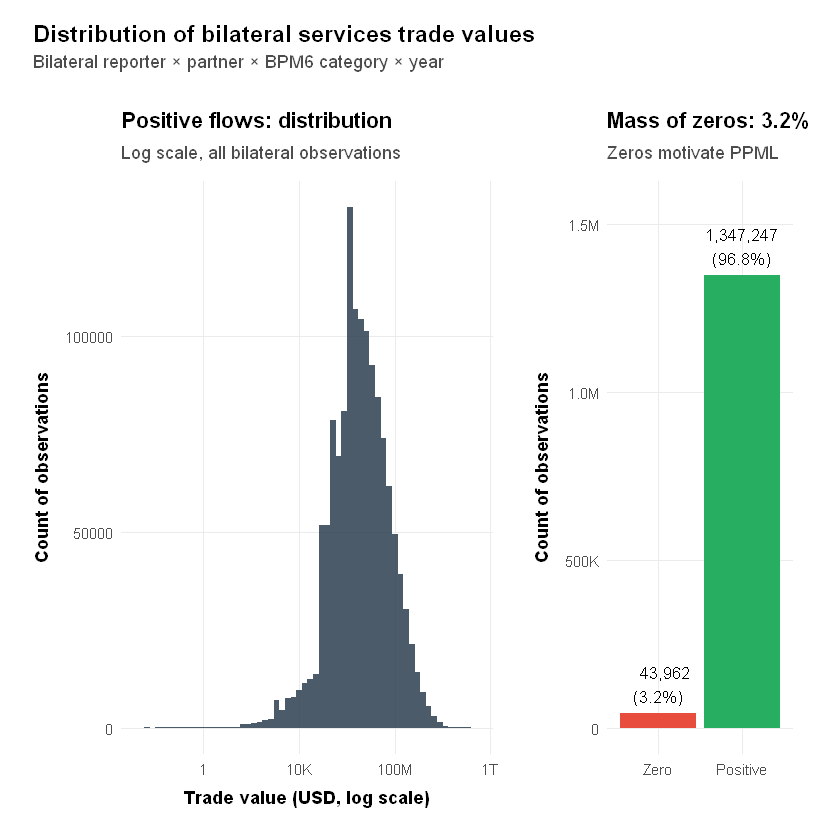

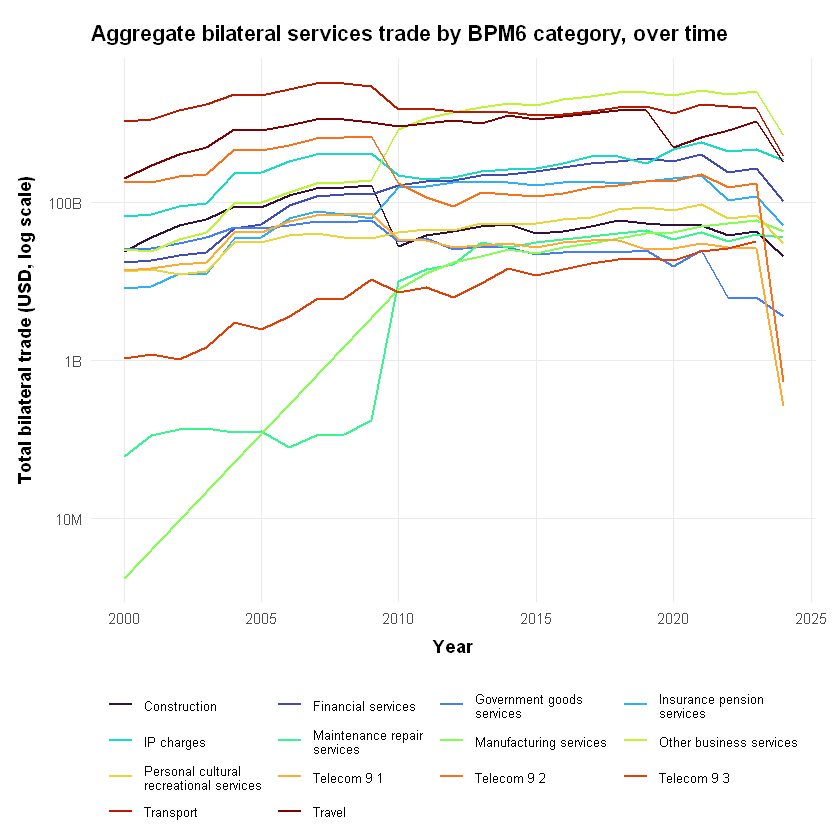

In [7]:
# --- 2.2 Distribution of trade values -----------------------------------------

# Histogram panel — short titles so they fit within the narrow panel
p_trade_dist <- df %>%
  filter(trade > 0) %>%
  ggplot(aes(x = trade)) +
  geom_histogram(bins = 60, fill = "#2C3E50", alpha = 0.85) +
  scale_x_log10(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  labs(title    = "Positive flows: distribution",
       subtitle = "Log scale, all bilateral observations",
       x        = "Trade value (USD, log scale)",
       y        = "Count of observations")

mass_of_zeros <- mean(df$trade == 0)

# Zero-mass panel — short title so it fits the narrow column
p_zeros <- df %>%
  count(has_trade) %>%
  mutate(pct = n / sum(n),
         lab = sprintf("%s\n(%.1f%%)",
                       format(n, big.mark = ","), 100 * pct)) %>%
  ggplot(aes(x = factor(has_trade,
                         levels = c(0, 1),
                         labels = c("Zero", "Positive")),
             y = n, fill = factor(has_trade))) +
  geom_col() +
  geom_text(aes(label = lab), vjust = -0.3, size = 3.5) +
  scale_fill_manual(values = c("#E74C3C", "#27AE60"), guide = "none") +
  scale_y_continuous(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  expand_limits(y = max(table(df$has_trade)) * 1.15) +
  labs(title    = sprintf("Mass of zeros: %.1f%%", 100 * mass_of_zeros),
       subtitle = "Zeros motivate PPML",
       x = NULL, y = "Count of observations")

# Combine with one shared figure-level title above both panels.
p_dist_panel <- (p_trade_dist + p_zeros) +
  plot_layout(widths = c(2, 1)) +
  plot_annotation(
    title    = "Distribution of bilateral services trade values",
    subtitle = "Bilateral reporter × partner × BPM6 category × year",
    theme    = theme(plot.title    = element_text(face = "bold", size = 14,
                                                    margin = margin(b = 4)),
                     plot.subtitle = element_text(colour = "grey30",
                                                    margin = margin(b = 10)))
  )

ggsave(file.path(FIGURES_DIR, "fig_trade_distribution.png"),
       p_dist_panel, width = 13, height = 6, dpi = 300, bg = "white")
print(p_dist_panel)

# --- 2.3 Trade trends over time ---------------------------------------------

trade_by_yr_cat <- df %>%
  group_by(year, bpm6_category) %>%
  summarise(total_trade = sum(trade, na.rm = TRUE), .groups = "drop")

p_trends <- ggplot(trade_by_yr_cat,
                    aes(x = year, y = total_trade, colour = bpm6_category)) +
  geom_line(linewidth = 0.8) +
  scale_y_log10(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  scale_colour_viridis_d(option = "turbo",
                          labels = function(x) stringr::str_wrap(
                            gsub("_", " ", x), width = 24)) +
  labs(title    = "Aggregate bilateral services trade by BPM6 category, over time",
       x        = "Year",
       y        = "Total bilateral trade (USD, log scale)",
       colour   = NULL) +
  theme(legend.text = element_text(size = 8),
        legend.key.height = unit(1.0, "lines")) +
  guides(colour = guide_legend(ncol = 4, byrow = TRUE))

ggsave(file.path(FIGURES_DIR, "fig_trade_trends.png"),
       p_trends, width = 12, height = 7.5, dpi = 300, bg = "white")
print(p_trends)

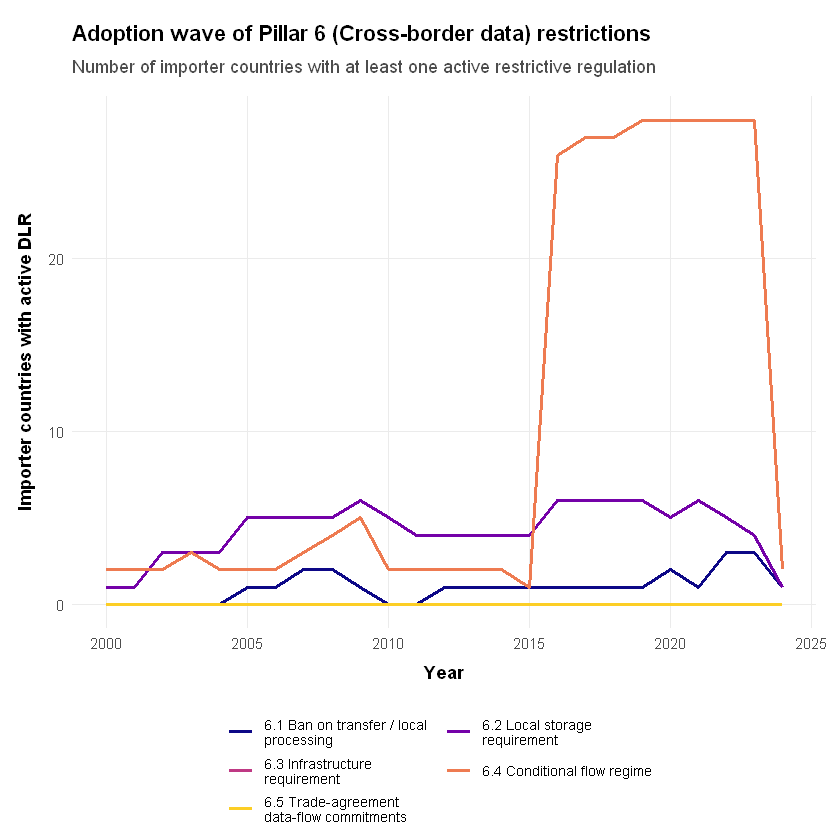

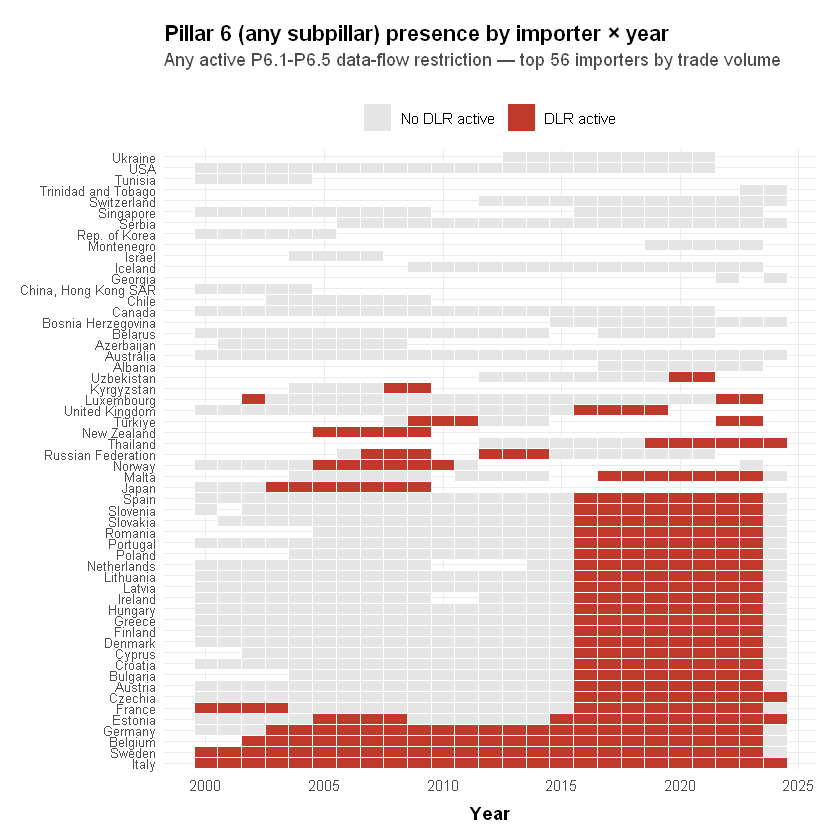

In [8]:
# --- 2.4 Adoption curve: cumulative DLR-active countries by year ---------

# For each Pillar 6 subpillar, count importers with the negative effect = 1 in
# each year. This is the "wave" plot of data localization adoption.

p6_labels <- c(p6_1 = "6.1 Ban on transfer / local processing",
               p6_2 = "6.2 Local storage requirement",
               p6_3 = "6.3 Infrastructure requirement",
               p6_4 = "6.4 Conditional flow regime",
               p6_5 = "6.5 Trade-agreement data-flow commitments")

adopt <- df %>%
  group_by(importer, year) %>%
  summarise(across(starts_with("p6_") & ends_with("_neg_effect"),
                    ~ as.integer(any(.x == 1))),
            .groups = "drop") %>%
  pivot_longer(starts_with("p6_"),
                names_to = "pillar",
                values_to = "active") %>%
  mutate(pillar = sub("_neg_effect$", "", pillar)) %>%
  group_by(pillar, year) %>%
  summarise(n_active = sum(active, na.rm = TRUE), .groups = "drop") %>%
  mutate(pillar_label = factor(pillar, levels = names(p6_labels),
                                labels = p6_labels))

p_adopt <- ggplot(adopt, aes(x = year, y = n_active, colour = pillar_label)) +
  geom_line(linewidth = 1) +
  scale_colour_viridis_d(option = "plasma", end = 0.9,
                          labels = function(x) stringr::str_wrap(x, width = 28)) +
  labs(title    = "Adoption wave of Pillar 6 (Cross-border data) restrictions",
       subtitle = "Number of importer countries with at least one active restrictive regulation",
       x = "Year", y = "Importer countries with active DLR",
       colour = NULL) +
  theme(legend.position = "bottom",
        legend.text = element_text(size = 8.5),
        legend.key.height = unit(0.9, "lines")) +
  guides(colour = guide_legend(nrow = 3, byrow = TRUE,
                                keywidth = unit(1.2, "lines")))

ggsave(file.path(FIGURES_DIR, "fig_dlr_adoption_curve.png"),
       p_adopt, width = 11, height = 7.5, dpi = 300, bg = "white")
print(p_adopt)

# --- 2.5 Heatmap of P6 (any subpillar) prevalence by country and year -------

# Switched from P6.1-only (dlr) to any-active-P6 (dlr_any). The heatmap shows
# whether each top-importer country had ANY active data-flow restriction
# (P6.1 through P6.5) in each year. This matches the headline DLR variable
# used in Models 1-6 and gives a complete picture of regulatory activity
# rather than just the narrow ban-on-transfer subpillar.

heat_df <- df %>%
  group_by(importer, year) %>%
  summarise(any_dlr = as.integer(any(dlr_any == 1, na.rm = TRUE)),
            .groups = "drop")

# Order countries by total years of treatment for visual clarity.
country_order <- heat_df %>%
  group_by(importer) %>%
  summarise(yrs_treated = sum(any_dlr), .groups = "drop") %>%
  arrange(desc(yrs_treated)) %>%
  pull(importer)

# Cap at the top 60 importers by trade volume, but never request more than
# the number actually present (smaller panels stay legible without padding).
N_TOP_HEATMAP <- min(60, n_distinct(df$importer))
top_importers <- df %>%
  group_by(importer) %>%
  summarise(tot = sum(trade, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(tot)) %>%
  head(N_TOP_HEATMAP) %>%
  pull(importer)

heat_top <- heat_df %>% filter(importer %in% top_importers) %>%
  mutate(importer = factor(importer,
                            levels = intersect(country_order, top_importers)))

p_heat <- ggplot(heat_top, aes(x = year, y = importer, fill = factor(any_dlr))) +
  geom_tile(colour = "white", linewidth = 0.1) +
  scale_fill_manual(values = c(`0` = "grey90", `1` = "#C0392B"),
                     labels = c(`0` = "No DLR active", `1` = "DLR active"),
                     name = NULL) +
  scale_x_continuous(breaks = scales::pretty_breaks(n = 8)) +
  labs(title    = "Pillar 6 (any subpillar) presence by importer × year",
       subtitle = sprintf("Any active P6.1-P6.5 data-flow restriction — top %d importers by trade volume",
                          N_TOP_HEATMAP),
       x = "Year", y = NULL) +
  theme(axis.text.y = element_text(size = 7.5),
        axis.text.x = element_text(size = 9),
        legend.position = "top",
        plot.title = element_text(margin = margin(b = 4)),
        plot.subtitle = element_text(margin = margin(b = 10)))

ggsave(file.path(FIGURES_DIR, "fig_dlr_heatmap.png"),
       p_heat, width = 11, height = 13, dpi = 300, bg = "white")
print(p_heat)

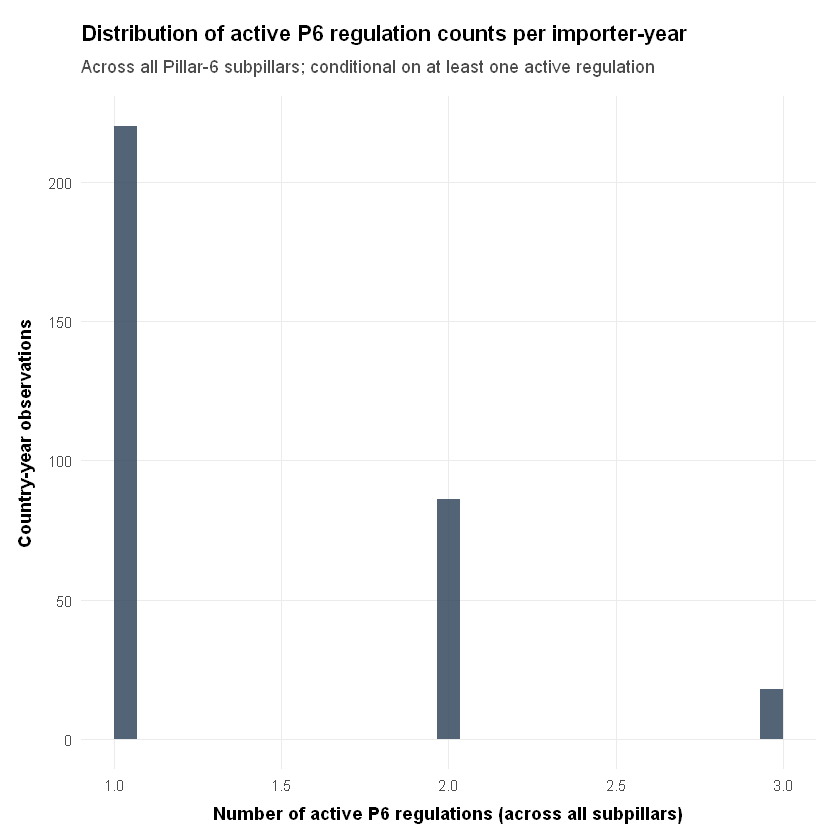

Warning message in cor(df[, p6_neg], use = "pairwise.complete.obs"):
"the standard deviation is zero"


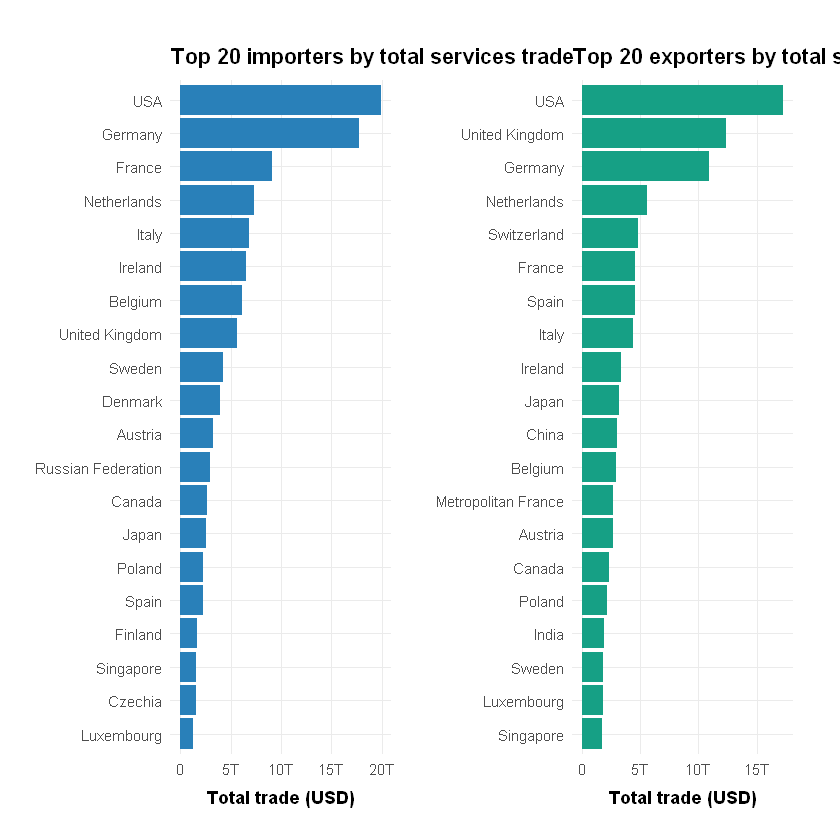

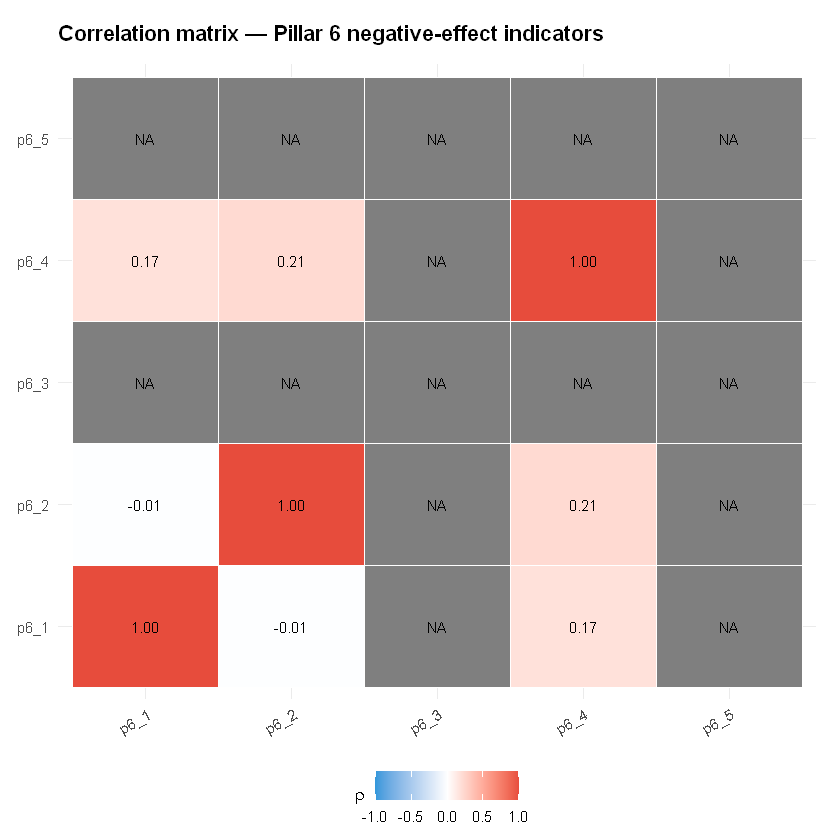


All Section 2 figures saved to: ../outputs/gravity_results/figures 


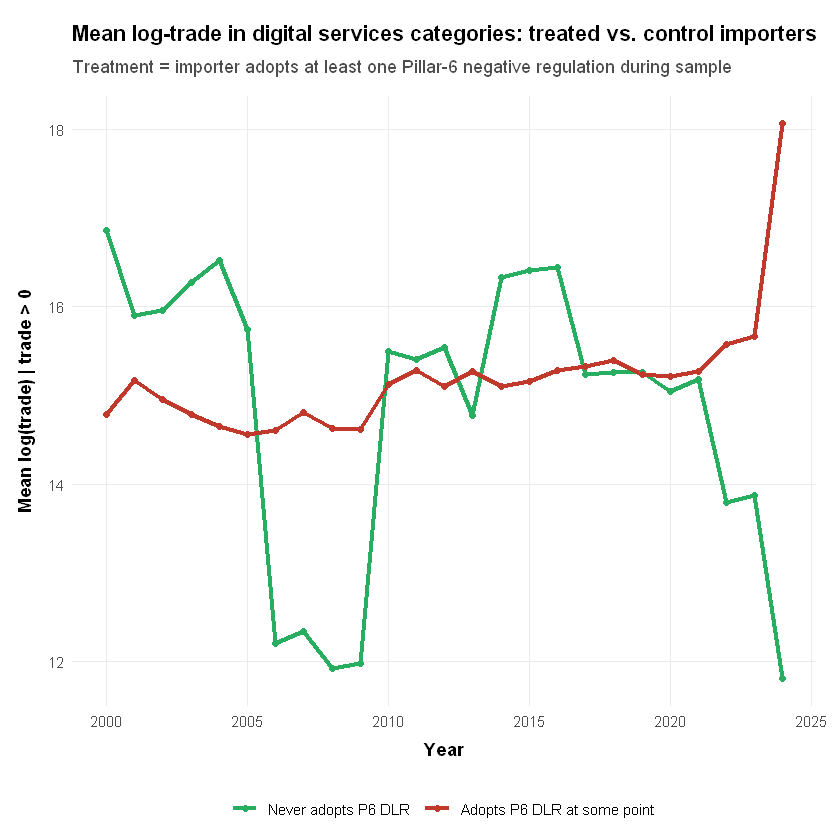

In [9]:
# --- 2.6 Distribution of P6 regulation counts per country-year ------------

# Switched from P6.1-only (dlr_count) to the full Pillar-6 count
# (dlr_any_count). The histogram now shows how many P6 instruments (across
# P6.1-P6.5) are active in each treated importer-year, matching Model 2
# which uses dlr_any_count as the dose-response regressor.

count_dist <- df %>%
  group_by(importer, year) %>%
  summarise(n_neg = max(dlr_any_count, na.rm = TRUE), .groups = "drop") %>%
  filter(n_neg > 0)

p_counts <- ggplot(count_dist, aes(x = n_neg)) +
  geom_histogram(bins = 30, fill = "#34495E", alpha = 0.85) +
  labs(title    = "Distribution of active P6 regulation counts per importer-year",
       subtitle = "Across all Pillar-6 subpillars; conditional on at least one active regulation",
       x = "Number of active P6 regulations (across all subpillars)",
       y = "Country-year observations")

ggsave(file.path(FIGURES_DIR, "fig_count_distribution.png"),
       p_counts, width = 8, height = 5, dpi = 300, bg = "white")
print(p_counts)

# --- 2.7 Top reporters and partners by trade volume ------------------------

top_imp <- df %>%
  group_by(importer) %>%
  summarise(total = sum(trade, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total)) %>%
  head(20)

top_exp <- df %>%
  group_by(exporter) %>%
  summarise(total = sum(trade, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total)) %>%
  head(20)

p_imp <- ggplot(top_imp, aes(x = reorder(importer, total), y = total)) +
  geom_col(fill = "#2980B9") +
  coord_flip() +
  scale_y_continuous(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  labs(title = "Top 20 importers by total services trade", x = NULL, y = "Total trade (USD)")

p_exp <- ggplot(top_exp, aes(x = reorder(exporter, total), y = total)) +
  geom_col(fill = "#16A085") +
  coord_flip() +
  scale_y_continuous(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  labs(title = "Top 20 exporters by total services trade", x = NULL, y = "Total trade (USD)")

p_top <- p_imp + p_exp + plot_layout(widths = c(1, 1))
ggsave(file.path(FIGURES_DIR, "fig_top_traders.png"),
       p_top, width = 14, height = 7, dpi = 300, bg = "white")
print(p_top)

# --- 2.8 Correlation matrix among Pillar 6 (negative) flags ----------------

p6_neg <- grep("^p6_[0-9]+_neg_effect$", names(df), value = TRUE)
cor_p6 <- cor(df[, p6_neg], use = "pairwise.complete.obs")
rownames(cor_p6) <- colnames(cor_p6) <-
  sub("_neg_effect$", "", rownames(cor_p6))

cor_long <- as.data.frame(as.table(cor_p6))
names(cor_long) <- c("Var1", "Var2", "rho")

p_cor <- ggplot(cor_long, aes(Var1, Var2, fill = rho)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = sprintf("%.2f", rho)), size = 3.2) +
  scale_fill_gradient2(low = "#3498DB", mid = "white", high = "#E74C3C",
                       limits = c(-1, 1)) +
  labs(title = "Correlation matrix — Pillar 6 negative-effect indicators",
       x = NULL, y = NULL, fill = expression(rho)) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 9),
        axis.text.y = element_text(size = 9),
        plot.title = element_text(margin = margin(b = 12)))

ggsave(file.path(FIGURES_DIR, "fig_correlation_p6.png"),
       p_cor, width = 8, height = 6.5, dpi = 300, bg = "white")
print(p_cor)

# --- 2.9 Treated-vs-control trajectory (digital services only) -------------

# Define "treated" = importer has any P6 negative effect ever in the panel.
treat_status <- df %>%
  group_by(importer) %>%
  summarise(treated = as.integer(any(dlr_any == 1, na.rm = TRUE)),
            .groups = "drop")

traj <- df %>%
  filter(bpm6_category %in% DIGITAL_BPM6_CATS, trade > 0) %>%
  inner_join(treat_status, by = "importer") %>%
  group_by(year, treated) %>%
  summarise(mean_log_trade = mean(log_trade, na.rm = TRUE), .groups = "drop") %>%
  mutate(group = factor(treated, levels = c(0, 1),
                         labels = c("Never adopts P6 DLR",
                                    "Adopts P6 DLR at some point")))

p_traj <- ggplot(traj, aes(x = year, y = mean_log_trade, colour = group)) +
  geom_line(linewidth = 1.2) + geom_point(size = 1.6) +
  scale_colour_manual(values = c("#27AE60", "#C0392B")) +
  labs(title    = "Mean log-trade in digital services categories: treated vs. control importers",
       subtitle = "Treatment = importer adopts at least one Pillar-6 negative regulation during sample",
       x = "Year", y = "Mean log(trade) | trade > 0",
       colour = NULL)

ggsave(file.path(FIGURES_DIR, "fig_treated_control_trajectory.png"),
       p_traj, width = 10, height = 6, dpi = 300, bg = "white")
print(p_traj)

cat("\nAll Section 2 figures saved to:", FIGURES_DIR, "\n")

### 3a. Baseline structural gravity PPML

The baseline specification follows the Heid, Larch and Yotov (2021) prescription for **non-discriminatory** national policies — measures that the regulating jurisdiction applies uniformly to all foreign partners, of which data localization is a textbook example. The estimating equation is

$$
X_{ij,k,t} = \exp\!\Big[\eta_{j,t} + \pi_{i,k,t} + \mu_{ij,k} + \beta\,\text{DLR}_{j,k,t}\Big]\varepsilon_{ij,k,t}.
$$

**A note on the variation level of DLR.** Because the upstream DTI×BPM6 mapping conditions each regulation's effect flag on whether the instrument's scope actually bites on each specific service category, the treatment variable $\text{DLR}_{j,k,t}$ varies along *three* dimensions: importer ($j$), product ($k$), and year ($t$). For example, $\text{DLR} = 1$ for "Germany, Telecommunications 9.1, 2014" but may equal $0$ for "Germany, Travel, 2014" even when Germany has an active P6 regulation, because cross-border data-transfer restrictions are not mapped to travel services. This product-level variation is critical for the FE-identification logic that follows.

The three sets of fixed effects absorb:

1. **Importer-time** $\eta_{j,t}$ — destination-country macroeconomic shocks, aggregate inward multilateral resistance, and the size of the destination market.
2. **Exporter-product-time** $\pi_{i,k,t}$ — outward multilateral resistance and exporter-side supply at the product-year level, including the average productivity distribution that scales the firm-level export decision in the Melitz framework.
3. **Pair-product** $\mu_{ij,k}$ — every time-invariant bilateral trade-cost component (distance, contiguity, language, colonial ties, unobserved bilateral preference) at the product level.

Identification of $\beta$ combines two sources of variation in $\text{DLR}_{j,k,t}$:

- **Within-pair-product over time** — how does importer $j$'s purchase of product $k$ from exporter $i$ change when $j$ activates DLR coverage on $k$, holding the pair's average trade and exporter $i$'s product-year outflows fixed?
- **Cross-product within importer-year** — within a given $(j, t)$ cell, products that DLR affects (per the DTI×BPM6 mapping) are compared to products that the same regulation does not reach.

A full importer-product-time fixed effect $\chi_{j,k,t}$ would absorb the *level* of $\text{DLR}_{j,k,t}$ mechanically, because the regulation indicator is constant within each $(j, k, t)$ cell by construction. The baseline therefore uses the *less* demanding $\eta_{j,t}$, which preserves the level effect for estimation. Connected to the thesis's Melitz framing: $\beta$ captures the bilateral trade response to a fixed-cost shock at the importer-product level, holding the productivity distribution and aggregate market size fixed. The estimated $\hat\beta$ is interpreted as $(\exp(\hat\beta) - 1) \times 100$ percent — the average percent change in bilateral services trade in category $k$ when importer $j$ adopts a Pillar-6 regulation that the mapping identifies as binding on $k$.

**A more demanding specification** with full importer-product-time fixed effects $\chi_{j,k,t}$ becomes feasible when we move from the *level* of $\text{DLR}_{j,k,t}$ to an *interaction* that introduces a fourth dimension. In Model 4 below we use $\text{DLR}_{j,k,t} \times \text{exp\_digital\_share}_i$, an interaction with a pre-period exporter trait. The interaction varies on $(i, j, k, t)$ — adding the exporter dimension to DLR's natural $(j, k, t)$ variation — and is therefore identified under the most saturated FE set in the thesis: $\chi_{j,k,t}$ (importer-product-time) absorbs the level of $\text{DLR}_{j,k,t}$, $\pi_{i,k,t}$ (exporter-product-time) absorbs the level of $\text{exp\_digital\_share}_i$ (which is time-invariant in exporter), and $\mu_{ij,k}$ (pair-product) absorbs all time-invariant bilateral characteristics, but the four-way interaction survives all three because no single fixed effect spans all of $(i, j, k, t)$.

In the Melitz-with-data-localization story this is the cleaner heterogeneity test: it asks whether DLR depresses bilateral services trade *most* for exporters specialized in digital-services production, exactly the prediction of fixed-cost-stacking on heterogeneous firms. A significantly negative interaction coefficient is direct evidence for the Melitz mechanism, identified off the cross-exporter variation that remains after removing every additive effect at the importer-product-time, exporter-product-time, and pair-product level.

In [10]:
# --- 3a.1 Baseline PPML — Heid, Larch & Yotov (2021) FE structure ----------

# IDENTIFICATION NOTE. The DLR variable varies at the (importer, product,
# year) level because the upstream DTI×BPM6 mapping conditions each
# regulation's effect flag on whether the instrument's scope bites on each
# specific service category. So `dlr_any = 1` for "Germany, Telecom, 2014"
# but may equal `0` for "Germany, Travel, 2014" even when Germany has an
# active P6 regulation — because Travel is outside the scope of cross-border
# data-transfer restrictions.
#
# Given (j, k, t) variation, the canonical Heid-Larch-Yotov three-way
# structure is admissible:
#   - importer-year:        aggregate destination shocks (inward MR + macro)
#   - exporter-product-year: outward MR + product-level supply
#   - pair-product:         all time-invariant bilateral trade costs
#
# Under imp_time (j,t), dlr_any survives because it also varies across k
# within each (j,t) cell. Identification combines (i) within-pair-product
# over-time variation in DLR with (ii) cross-product variation within
# importer-year. Note: imp_prod_time (j,k,t) WOULD absorb dlr_any
# completely; we therefore use imp_time, not imp_prod_time, in the headline.
#
# Treatment variable: dlr_any (any active P6.1-P6.5 negative effect),
# matching the thesis's research interest in data-flow restrictions broadly.

cat("\n--- Estimating baseline PPML ---\n")
cat("Formula: trade ~ dlr_any | imp_time + exp_prod_time + pair_prod\n")
cat("Cluster: pair_id\n\n")

t0 <- Sys.time()
m_baseline <- fepois(
  trade ~ dlr_any | imp_time + exp_prod_time + pair_prod,
  data    = df,
  cluster = ~ pair_id
)
cat(sprintf("Estimation time: %.1f sec\n",
            as.numeric(Sys.time() - t0, units = "secs")))

print(summary(m_baseline))


--- Estimating baseline PPML ---
Formula: trade ~ dlr_any | imp_time + exp_prod_time + pair_prod
Cluster: pair_id



NOTE: 3/8,261/4,814 fixed-effects (25,061 observations) removed because of only 0 outcomes or singletons.



Estimation time: 106.2 sec
Poisson estimation, Dep. Var.: trade
Observations: 1,366,148
Fixed-effects: imp_time: 961,  exp_prod_time: 28,930,  pair_prod: 31,553
Standard-errors: Clustered (pair_id) 
         Estimate Std. Error  z value Pr(>|z|)    
dlr_any -0.102604   0.045329 -2.26354 0.023603 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -8.036e+13   Adj. Pseudo R2: 0.742727
           BIC:  1.607e+14     Squared Cor.: 0.524582


### 3b. Robustness and extensions

Five alternative specifications (Models 2-6) probe the robustness of the baseline result and engage with the thesis's theoretical framing. Most use the **Heid-Larch-Yotov (2021) three-way FE structure** — importer-year + exporter-product-year + pair-product — which identifies $\beta_{\text{DLR}}$ off the (j, k, t) variation that survives `imp_time` because the upstream DTI×BPM6 mapping makes the regulation effect product-specific. Model 4 alone uses the more demanding `imp_prod_time` FE, where the level of DLR is absorbed and identification rests on cross-exporter variation in the interaction.

**Model 2 — Count of active P6 regulations.** Replaces the binary `dlr_any` with the count of active P6 negative regulations summed across all five subpillars. The coefficient is the marginal effect of one additional active regulation, after the mapping conditions on each regulation's product-scope. Under Melitz fixed-cost stacking, each additional regulation should add an independent fixed-cost layer, predicting a roughly linear dose-response.

**Model 3 — Reverse-causality / anticipation placebo.** Adds a two-year forward lead of `dlr_any`. A significant negative coefficient on the lead would indicate trade was already responding *before* regulation enactment, which would be inconsistent with the causal interpretation of $\beta_{\text{DLR}}$. The standard placebo design following Wolfers (2006) and Borusyak, Jaravel and Spiess (2024).

**Model 4 — DLR × Exporter digital share, with full importer-product-year FE.** The most demanding identification design: under $\chi_{j,k,t}$ (importer-product-time FE), the level effect of DLR is absorbed by construction. Identification comes from the interaction with a pre-determined exporter characteristic — the exporter's average share of digital services in total exports during the first five panel years, demeaned across exporters. The interaction varies across exporters within each $(j, k, t)$ cell and is therefore identified. A significantly negative coefficient is direct evidence that data localization raises fixed market-access costs MOST for exporters specialised in digital services — the Melitz prediction. Note: `exp_digital_share_c` itself is absorbed by both `exp_prod_time` and `pair_prod` because it is time-invariant in exporter; this is the correct specification, not an omission.

**Model 5 — DLR × Digital product, HLY FE.** Cross-validates the Melitz mechanism via *product heterogeneity*: does data localization depress digital BPM6 categories (Telecom 9.1/9.2/9.3, IP charges, Other business services) more than non-digital categories (Travel, Construction, Insurance, ...)? Identification combines the level effect of DLR (cross-product within importer-year) with the additional differential effect on digital products. Note: `is_digital` itself is absorbed by `pair_prod` because it is time-invariant in product. The level of `dlr_any` is identified; the interaction captures the *extra* depression specific to digital products.

**Model 6 — Robustness: DLR with trade-policy controls.** Adds the standard structural-gravity trade-policy controls (`both_wto`, `both_eu`, `rta_services`) to the headline. The RTA control is `rta_services` rather than `fta_wto`: for a thesis on digital-services trade, the services-coverage indicator is the methodologically appropriate measure because it isolates services-inclusive RTAs (e.g., CPTPP, EU single market) from goods-only PSAs that bear little relevance for services flows. Following Borchert, Larch, Shikher and Yotov (2021, *European Economic Review*). The objective: demonstrate that $\hat\beta_{\text{DLR}}$ is robust to including correlated policy variables.

**A note on identification and absorbed regressors.** Under each model's specific FE structure, certain regressors are necessarily absorbed:

| Variable | Variation | Absorbed by |
|---|---|---|
| `dlr_any`, `dlr_any_count` | (j, k, t) | imp_prod_time (in Model 4 only); identified under imp_time |
| `exp_digital_share_c` | (i) | exp_prod_time and pair_prod (all models containing it) |
| `is_digital` | (k) | pair_prod and exp_prod_time |
| `dlr_any:exp_digital_share_c` | (i, j, k, t) | none of the standard FE structures |
| `dlr_any:is_digital` | (j, k, t) | imp_prod_time (so absent from Models 4); identified under imp_time |

This is the structural-gravity FE machinery doing what it's supposed to do: removing nuisance variation while preserving the policy-coefficient identification.

In [11]:
# --- 3b.1 Model 2: Count of active P6 regulations ----------------------------

# Dose-response across all five P6 subpillars. Marginal effect of one
# additional active P6 regulation. Same FE structure as Model 1 because
# dlr_any_count varies on (j, k, t) like dlr_any.

cat("\n--- Model 2: count of active P6 regulations ---\n")
m_count <- fepois(
  trade ~ dlr_any_count | imp_time + exp_prod_time + pair_prod,
  data    = df,
  cluster = ~ pair_id
)
print(summary(m_count))

# --- 3b.2 Model 3: Reverse-causality / anticipation placebo ------------------

# 2-year forward lead of dlr_any using CALENDAR-CORRECT alignment. The
# previous implementation used dplyr::lead(x, n = 2L), which returns the
# next observation in the sorted rows -- not the value 2 calendar years
# ahead. UN Comtrade has reporting gaps (countries skip years, re-categorize
# products mid-panel), so the row-based lead silently picks up values from
# 3, 4, or 5 calendar years ahead in panel-incomplete rows. This contaminates
# the lead coefficient with sample-selection on reporting completeness.
#
# Fix: construct the lead via an explicit calendar-year join keyed on
# (importer, bpm6_category, year) -- the actual variation level of dlr_any.
# The exporter dimension is irrelevant here because dlr_any depends only
# on the importer's regulatory regime and the BPM6 product mapping, not on
# the exporter. Joining on the smaller key also avoids the many-to-many
# warnings caused by the panel structure.
#
# A significant negative coefficient on the lead would indicate that trade
# was responding 2 calendar years BEFORE the formal DLR activation date.
# Two interpretations: (i) anticipation effects from pre-announced
# regulations (GDPR was published 2016, enforced 2018; Russia 242-FZ passed
# 2014, enforced 2015), or (ii) reverse causality. The thesis discussion
# section interprets this explicitly.

cat("\n--- Model 3: forward-lead placebo (calendar-correct) ---\n")

# Build the calendar-year lookup at the (importer, bpm6_category, year) level
# -- the actual variation level of dlr_any. Deduplicate first since dlr_any
# is identical across exporter rows within each (importer, product, year).
lead_lookup <- df %>%
  select(importer, bpm6_category, year, dlr_any) %>%
  distinct() %>%
  rename(year_minus2 = year, dlr_any_lead2 = dlr_any) %>%
  mutate(year = year_minus2 - 2L) %>%
  select(importer, bpm6_category, year, dlr_any_lead2)

# Sanity check: the lookup table should have one row per
# (importer, bpm6_category, year). If not, there's an upstream data issue.
n_lookup_rows <- nrow(lead_lookup)
n_lookup_keys <- nrow(lead_lookup %>% distinct(importer, bpm6_category, year))
if (n_lookup_rows != n_lookup_keys) {
  warning(sprintf("Lead lookup has %d rows but %d unique keys -- duplicates remain",
                  n_lookup_rows, n_lookup_keys))
} else {
  cat(sprintf("  Lead lookup table: %s rows, all unique on (importer, bpm6, year)\n",
              format(n_lookup_rows, big.mark = ",")))
}

# Now join the lookup to df. With a clean lookup key, this is many-to-one
# (multiple df rows per importer-product-year share the same lead value).
lead_df <- df %>%
  left_join(lead_lookup,
            by = c("importer", "bpm6_category", "year"),
            relationship = "many-to-one")

# Diagnostic: how many rows have a valid t+2 lead?
cat(sprintf("  Rows with valid t+2 lead:    %s (%.1f%% of panel)\n",
            format(sum(!is.na(lead_df$dlr_any_lead2)), big.mark = ","),
            100 * mean(!is.na(lead_df$dlr_any_lead2))))
cat(sprintf("  Rows missing the t+2 lead:   %s (%.1f%%) -- excluded from\n",
            format(sum(is.na(lead_df$dlr_any_lead2)), big.mark = ","),
            100 * mean(is.na(lead_df$dlr_any_lead2))))
cat("    estimation (last 2 panel years per product + reporting gaps)\n")

lead_df_used <- lead_df %>% filter(!is.na(dlr_any_lead2))

m_lead <- fepois(
  trade ~ dlr_any + dlr_any_lead2 | imp_time + exp_prod_time + pair_prod,
  data    = lead_df_used,
  cluster = ~ pair_id
)
print(summary(m_lead))

# --- 3b.3 Build interaction-component variables ------------------------------

# is_digital: time-invariant product attribute. Identifies which BPM6
# categories correspond to digitally-delivered services.
df$is_digital <- as.integer(df$bpm6_category %in% DIGITAL_BPM6_CATS)

# exp_digital_share: pre-period exporter trait. Computed as each exporter's
# average share of digital services in total services exports during the
# first five panel years. Time-invariant by construction (pre-determined),
# so exogenous to DLR adoption.
pre_period_end <- min(df$year, na.rm = TRUE) + 4

exp_digital_share <- df %>%
  filter(year <= pre_period_end, trade > 0) %>%
  group_by(exporter) %>%
  summarise(
    digital_trade = sum(trade[bpm6_category %in% DIGITAL_BPM6_CATS],
                         na.rm = TRUE),
    total_trade   = sum(trade, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(exp_digital_share = ifelse(total_trade > 0,
                                     digital_trade / total_trade, NA_real_)) %>%
  select(exporter, exp_digital_share)

cat(sprintf("\nExporter digital-share computed over pre-period years %d-%d\n",
            min(df$year, na.rm = TRUE), pre_period_end))
cat(sprintf("Mean: %.3f, SD: %.3f, n_exporters: %d\n",
            mean(exp_digital_share$exp_digital_share, na.rm = TRUE),
            sd(exp_digital_share$exp_digital_share, na.rm = TRUE),
            sum(!is.na(exp_digital_share$exp_digital_share))))

df <- df %>% left_join(exp_digital_share, by = "exporter")
df$exp_digital_share_c <- df$exp_digital_share -
  mean(df$exp_digital_share, na.rm = TRUE)

# --- 3b.4 Model 4: DLR x Exporter digital share (full imp_prod_time FE) ------

# Most demanding identification design in the headline. Under the full
# importer-product-year FE, dlr_any IS absorbed (varies on j,k,t like the
# FE). Identification comes from the interaction with a pre-period exporter
# characteristic, which varies across exporters within each (j, k, t)
# cell. A significantly negative coefficient is direct evidence that data
# localization raises fixed market-access costs MOST for exporters whose
# comparative advantage lies in digital services — the Melitz prediction.
#
# Note on main effects:
#   - dlr_any is absorbed by imp_prod_time (correct under this FE).
#   - exp_digital_share_c is absorbed by exp_prod_time AND pair_prod
#     (time-invariant in exporter). Correctly absent from the formula.

cat("\n--- Model 4: DLR x Exporter digital share, full imp_prod_time FE ---\n")
# Named data object so fixest::summary() can refetch the data for SEs.
digital_df <- df %>% filter(!is.na(exp_digital_share_c))

m_digital <- fepois(
  trade ~ dlr_any:exp_digital_share_c | imp_prod_time + exp_prod_time + pair_prod,
  data    = digital_df,
  cluster = ~ pair_id
)
print(summary(m_digital))

# --- 3b.5 Model 5: DLR x Digital product (HLY FE, drops imp_prod_time) -------

# Cross-validates the Melitz mechanism through PRODUCT heterogeneity:
# does data localization depress digital BPM6 categories more than
# non-digital ones? Both dlr_any and dlr_any:is_digital vary on (j, k, t),
# so we use the headline HLY structure (imp_time, not imp_prod_time) where
# both survive identification. The level coefficient on dlr_any is the
# average DLR effect across all services categories; the interaction is the
# ADDITIONAL effect on digital categories beyond that average.
#
# Note on main effects:
#   - is_digital is absorbed by pair_prod (time-invariant in product).
#     Correctly absent from the formula.

cat("\n--- Model 5: DLR + DLR x Digital product, HLY FE ---\n")
m_product <- fepois(
  trade ~ dlr_any + dlr_any:is_digital | imp_time + exp_prod_time + pair_prod,
  data    = df,
  cluster = ~ pair_id
)
print(summary(m_product))

# --- 3b.6 Model 6: Robustness — DLR with trade-policy controls --------------

# Same HLY FE as the headline, plus structural-gravity trade-policy controls.
# The RTA control is `rta_services` (services-inclusive RTAs) rather than
# `fta_wto` (any RTA, including goods-only PSAs). For a thesis on digital
# services trade, the services-coverage indicator isolates RTAs that
# actually liberalise services flows, following Borchert, Larch, Shikher and
# Yotov (2021, EER).
#
# The point: if countries adopt DLR around the same time they accede to the
# WTO, join the EU, or sign services-inclusive RTAs, the headline could be
# confounded. If beta_DLR barely moves when these controls are added, the
# confounding channel is ruled out. The policy-control coefficients
# themselves are weakly identified under pair-product FE (only pair-year
# switchers contribute); their proper estimates are in Section 3d.

if (exists("has_gravity_controls") && has_gravity_controls) {
  cat("\n--- Model 6: DLR + trade-policy controls (HLY FE) ---\n")
  # Named data object so fixest::summary() can refetch the data for SEs.
  with_policy_df <- df %>%
    filter(!is.na(both_wto), !is.na(both_eu), !is.na(rta_services))

  m_with_policy <- fepois(
    trade ~ dlr_any + both_wto + both_eu + rta_services
          | imp_time + exp_prod_time + pair_prod,
    data    = with_policy_df,
    cluster = ~ pair_id
  )
  print(summary(m_with_policy))
} else {
  cat("\n--- Model 6 skipped: CEPII gravity controls not loaded ---\n")
  m_with_policy <- NULL
}


--- Model 2: count of active P6 regulations ---


NOTE: 3/8,261/4,814 fixed-effects (25,061 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,366,148
Fixed-effects: imp_time: 961,  exp_prod_time: 28,930,  pair_prod: 31,553
Standard-errors: Clustered (pair_id) 
               Estimate Std. Error  z value Pr(>|z|)    
dlr_any_count -0.064438    0.03376 -1.90869 0.056302 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -8.036e+13   Adj. Pseudo R2: 0.742724
           BIC:  1.607e+14     Squared Cor.: 0.524519

--- Model 3: forward-lead placebo (calendar-correct) ---
  Lead lookup table: 10,630 rows, all unique on (importer, bpm6, year)
  Rows with valid t+2 lead:    1,213,422 (87.2% of panel)
  Rows missing the t+2 lead:   177,787 (12.8%) -- excluded from
    estimation (last 2 panel years per product + reporting gaps)


NOTE: 1/5,421/2,854 fixed-effects (9,883 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,203,539
Fixed-effects: imp_time: 833,  exp_prod_time: 24,608,  pair_prod: 29,211
Standard-errors: Clustered (pair_id) 
               Estimate Std. Error   z value Pr(>|z|) 
dlr_any       -0.046809   0.048273 -0.969679  0.33221 
dlr_any_lead2 -0.051329   0.062005 -0.827816  0.40777 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -7.103e+13   Adj. Pseudo R2: 0.73459 
           BIC:  1.421e+14     Squared Cor.: 0.478215

Exporter digital-share computed over pre-period years 2000-2004
Mean: 0.051, SD: 0.079, n_exporters: 167

--- Model 4: DLR x Exporter digital share, full imp_prod_time FE ---


...

Poisson estimation, Dep. Var.: trade
Observations: 1,355,475
Fixed-effects: imp_prod_time: 10,466,  exp_prod_time: 27,122,
 pair_prod: 30,778
Standard-errors: Clustered (pair_id) 
                             Estimate Std. Error   z value Pr(>|z|) 
dlr_any:exp_digital_share_c -0.390137   0.525017 -0.743094  0.45743 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -7.742e+13   Adj. Pseudo R2: 0.751117
           BIC:  1.548e+14     Squared Cor.: 0.552861

--- Model 5: DLR + DLR x Digital product, HLY FE ---


NOTE: 3/8,261/4,814 fixed-effects (25,061 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,366,148
Fixed-effects: imp_time: 961,  exp_prod_time: 28,930,  pair_prod: 31,553
Standard-errors: Clustered (pair_id) 
                    Estimate Std. Error   z value Pr(>|z|) 
dlr_any            -0.101669   0.070752 -1.436978  0.15072 
dlr_any:is_digital -0.001556   0.080685 -0.019281  0.98462 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -8.036e+13   Adj. Pseudo R2: 0.742727
           BIC:  1.607e+14     Squared Cor.: 0.524583

--- Model 6: DLR + trade-policy controls (HLY FE) ---


NOTE: 3/7,788/4,676 fixed-effects (23,910 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,364,569
Fixed-effects: imp_time: 961,  exp_prod_time: 28,631,  pair_prod: 31,471
Standard-errors: Clustered (pair_id) 
              Estimate Std. Error   z value Pr(>|z|)    
dlr_any      -0.102751   0.045321 -2.267193 0.023378 *  
both_wto     -0.277427   0.135077 -2.053837 0.039991 *  
both_eu       0.002891   0.053382  0.054163 0.956806    
rta_services -0.086663   0.034381 -2.520710 0.011712 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -8.031e+13   Adj. Pseudo R2: 0.742752
           BIC:  1.606e+14     Squared Cor.: 0.524563


### 3c. Results table (headline)

The table below presents all six specifications side by side. Standard errors are cluster-robust at the symmetric country-pair level. Coefficient-on-binary interpretation: a coefficient of $\hat\beta$ implies a $(\exp(\hat\beta) - 1) \times 100\%$ change in bilateral services trade when DLR switches from 0 to 1. Coefficient-on-count interpretation (Model 2): the same percent change per additional active regulation, conditional on the regulation's product-scope.

In [12]:
# --- 3c.1 Combined results table ----------------------------------------------

# Headline models
models <- list(
  "(1) Baseline\nany P6 DLR"          = m_baseline,
  "(2) Count of\nactive P6 regs"      = m_count,
  "(3) Forward lead\n(placebo)"       = m_lead,
  "(4) DLR x Exporter\ndigital share" = m_digital,
  "(5) DLR x Digital\nproduct"        = m_product
)

# Model 6 only if CEPII gravity / policy controls are loaded
if (!is.null(m_with_policy)) {
  models[["(6) DLR + trade\npolicy controls"]] <- m_with_policy
}

# Coefficient labels for the table
coef_labels <- c(
  "dlr_any"                     = "DLR (any active P6 regulation)",
  "dlr_any_count"               = "Count of active P6 regulations",
  "dlr_any_lead2"               = "DLR (forward lead, t+2)",
  
  # Standalone variables used in interaction models
  "exp_digital_share_c"         = "Exporter digital share (demeaned)",
  "is_digital"                  = "Digital product",
  
  # Interaction terms
  "dlr_any:exp_digital_share_c" = "DLR x Exporter digital share (demeaned)",
  "dlr_any:is_digital"          = "DLR x Digital product",
  
  # Trade policy controls
  "both_wto"                    = "Both WTO members",
  "both_eu"                     = "Both EU members",
  "rta_services"                = "RTA covers services"
)

# Goodness-of-fit rows
gof_map <- data.frame(
  raw   = c(
    "nobs", "r2",
    "FE: imp_time",
    "FE: imp_prod_time",
    "FE: exp_prod_time",
    "FE: pair_prod"
  ),
  clean = c(
    "Observations",
    "Pseudo-R²",
    "Importer-year FE",
    "Importer-product-year FE",
    "Exporter-product-year FE",
    "Pair-product FE"
  ),
  fmt   = c(0, 3, 0, 0, 0, 0),
  stringsAsFactors = FALSE
)

# HTML output for display in notebook
ms_html <- modelsummary(
  models,
  coef_map = coef_labels,
  gof_map  = gof_map,
  stars    = c("*" = .1, "**" = .05, "***" = .01),
  output   = "kableExtra",
  title    = "Structural gravity PPML — effect of data localization on bilateral services trade",
  notes    = list(
    "Cluster-robust standard errors at the symmetric country-pair level in parentheses.",
    "All models are estimated using PPML via fepois.",
    "DLR variable: dlr_any equals 1 when there is any active Pillar 6 data-localization regulation.",
    "Interaction models include both interaction components as standalone regressors.",
    "Trade policy control: rta_services indicates whether the RTA covers services.",
    "Sample period depends on data availability; CEPII controls are available through 2019 unless forward-filled."
  )
)

# Save HTML
modelsummary(
  models,
  coef_map = coef_labels,
  gof_map  = gof_map,
  stars    = c("*" = .1, "**" = .05, "***" = .01),
  output   = file.path(TABLES_DIR, "regression_results.html"),
  title    = "Structural gravity PPML — effect of data localization on bilateral services trade",
  notes    = list(
    "Cluster-robust standard errors at the symmetric country-pair level in parentheses.",
    "All models are estimated using PPML via fepois.",
    "DLR variable: dlr_any equals 1 when there is any active Pillar 6 data-localization regulation.",
    "Interaction models include both interaction components as standalone regressors.",
    "Trade policy control: rta_services indicates whether the RTA covers services.",
    "Sample period depends on data availability; CEPII controls are available through 2019 unless forward-filled."
  )
)

# Save LaTeX
modelsummary(
  models,
  coef_map = coef_labels,
  gof_map  = gof_map,
  stars    = c("*" = .1, "**" = .05, "***" = .01),
  output   = file.path(TABLES_DIR, "regression_results.tex"),
  title    = "Structural gravity PPML — effect of data localization on bilateral services trade",
  notes    = list(
    "Cluster-robust standard errors at the symmetric country-pair level in parentheses.",
    "All models are estimated using PPML via fepois.",
    "DLR variable: dlr_any equals 1 when there is any active Pillar 6 data-localization regulation.",
    "Interaction models include both interaction components as standalone regressors.",
    "Trade policy control: rta_services indicates whether the RTA covers services.",
    "Sample period depends on data availability; CEPII controls are available through 2019 unless forward-filled."
  )
)

cat(sprintf("Saved: %s\n", file.path(TABLES_DIR, "regression_results.html")))
cat(sprintf("Saved: %s\n", file.path(TABLES_DIR, "regression_results.tex")))

print(ms_html)

Warning message:
"To compile a LaTeX document with this table, the following commands must be placed in the document preamble:

\usepackage{tabularray}
\usepackage{float}
\usepackage{graphicx}
\usepackage{codehigh}
\usepackage[normalem]{ulem}
\UseTblrLibrary{booktabs}
\UseTblrLibrary{siunitx}
\newcommand{\tinytableTabularrayUnderline}[1]{\underline{#1}}
\newcommand{\tinytableTabularrayStrikeout}[1]{\sout{#1}}
\NewTableCommand{\tinytableDefineColor}[3]{\definecolor{#1}{#2}{#3}}

To disable `siunitx` and prevent `modelsummary` from wrapping numeric entries in `\num{}`, call:

options("modelsummary_format_numeric_latex" = "plain")
 This warning appears once per session."


Saved: ../outputs/gravity_results/tables/regression_results.html
Saved: ../outputs/gravity_results/tables/regression_results.tex
<table style="NAborder-bottom: 0; width: auto !important; margin-left: auto; margin-right: auto;" class="table">
<caption>Structural gravity PPML — effect of data localization on bilateral services trade</caption>
 <thead>
  <tr>
   <th style="text-align:left;">   </th>
   <th style="text-align:center;"> &amp;nbsp;(1) Baseline
any P6 DLR </th>
   <th style="text-align:center;"> &amp;nbsp;(2) Count of
active P6 regs </th>
   <th style="text-align:center;"> &amp;nbsp;(3) Forward lead
(placebo) </th>
   <th style="text-align:center;"> &amp;nbsp;(4) DLR x Exporter
digital share </th>
   <th style="text-align:center;"> &amp;nbsp;(5) DLR x Digital
product </th>
   <th style="text-align:center;"> &amp;nbsp;(6) DLR + trade
policy controls </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> DLR (any active P6 regulation) </td>
   <td style="text-al

### Interpretation

* **Baseline DLR effect in column (1).** The coefficient $\hat\beta_{\text{DLR}}$ identifies the average percent change in bilateral services trade when importer $j$ activates a data-localization regulation whose mapped scope covers product category $k$. Identification: within-pair-product over time, cross-product within importer-year. Sign expectation: negative (data localization raises fixed costs of cross-border service delivery, predominantly affecting digitally-delivered services).

* **Dose-response in column (2).** Marginal effect of each additional active P6 regulation, after accounting for product-scope. A coefficient close to that on `dlr_any` divided by the average number of mapped-active regulations per treated cell indicates a roughly linear cost-stacking pattern (consistent with each instrument adding an independent fixed-cost layer). A much smaller-magnitude coefficient would suggest diminishing returns — the first instrument binds most.

* **Placebo in column (3).** A non-significant coefficient on `dlr_any_lead2` (the t+2 forward lead) supports the causal interpretation: trade was not already responding before regulation enactment. A significant negative lead would flag pre-trends or anticipation effects and require an event-study redesign.

* **Melitz exporter heterogeneity in column (4).** Under the most demanding FE (imp_prod_time + exp_prod_time + pair_prod), DLR's level is absorbed. The interaction with the pre-period exporter digital share identifies whether DLR hits digital-specialised exporters more than diversified ones, holding the importer's product-year demand fixed. A significantly negative interaction supports the Melitz-with-data-localization story.

* **Melitz product heterogeneity in column (5).** Under HLY FE, both the level of `dlr_any` and its interaction with `is_digital` are identified. The level captures the average DLR effect across services categories; the interaction captures the ADDITIONAL effect specific to digital BPM6 categories. The sum of the two coefficients is the total effect on digital products.

* **Robustness in column (6).** The DLR coefficient should change little when `both_wto`, `both_eu`, and `rta_services` are added. A meaningful shift would indicate DLR is partly proxying for unobserved trade-policy adoption. The control coefficients themselves are weakly identified under pair-product FE; their proper estimation is in Section 3d.

**Reporting in the thesis.** The headline coefficient should be reported with both raw $\hat\beta$ and the percent-change transformation $(\exp(\hat\beta) - 1) \times 100\%$, plus a 95% confidence interval. Example: $\hat\beta = -0.20$ implies trade falls by $(\exp(-0.20) - 1) \times 100\% \approx -18.1\%$ when DLR switches on. The CI follows from the cluster-robust standard error.

### 3d. Classic structural gravity with CEPII trade-cost controls

This section runs three classic-gravity specifications, progressively saturated with fixed effects, to estimate the effects of the standard trade-cost variables — distance, contiguity, common language, colonial ties, social connectedness — and the trade-policy variables that motivated this exercise: WTO, EU, and services-RTA membership. The three specifications are NOT alternatives to the headline models 1-8 (which identify the DLR coefficient under the most demanding FE structure). They are a parallel exercise: same data, different question, less demanding FE. Together with the headline they tell the full gravity story.

The specifications follow Yotov, Piermartini, Monteiro and Larch (2016, ch. 1) and Anderson, Larch and Yotov (2018, *European Economic Review*). The key methodological principle in this section: **never include a fixed effect that absorbs the variable you want to interpret**. Each spec progressively adds an FE and loses the variables it absorbs, allowing us to estimate each layer of gravity controls under the strongest possible FE structure where it remains identifiable.

**Spec A — Tinbergen 1962 (year FE only).** Year fixed effects absorb global trends, inflation, and worldwide demand shocks. Everything else is identified: GDP, distance, all bilateral controls, policy variables. Coefficients recovered:

* `log_gdp_o`, `log_gdp_d` — Tinbergen's income elasticities. Both should be near 1.0 in a clean panel; deviations indicate the "missing globalisation" puzzle (Yi 2003).
* `log_dist` — distance elasticity, expected −0.7 to −1.0 for services.
* `contig`, `comlang_off`, `col45` — neighbour, language, and colonial premia, expected positive.
* `both_wto`, `both_eu`, `rta_services` — trade-policy effects, expected positive. The RTA measure is `rta_services` (services-inclusive RTAs only, following Borchert, Larch, Shikher and Yotov 2021), not the broader `fta_wto` (any RTA, including goods-only PSAs).
* `log(1 + scaled_sci_2021)` — social-connectedness elasticity, expected positive (Bailey et al. 2021).

This spec is biased — it ignores multilateral resistance terms, so all coefficients are inflated by unobserved bilateral heterogeneity. It is reported as the textbook benchmark that motivates the move to fixed-effects specifications.

**Spec B — Anderson and van Wincoop (2003) structural baseline.** Adds importer-year and exporter-year fixed effects, which absorb the multilateral resistance terms exactly as Anderson and van Wincoop derive them from the demand system. GDP drops out (absorbed by the new FE). Distance, language, contiguity, colonial, SCI, and the policy variables remain identified — off *cross-pair* variation within each importer-year and exporter-year. This is the workhorse modern gravity specification.

**Spec C — Anderson, Larch and Yotov (2018) with pair fixed effects.** Adds pair fixed effects on top of Spec B, absorbing all time-invariant pair characteristics. Only `both_wto`, `both_eu`, `rta_services` remain — identified purely off *within-pair over-time* variation in institutional status. This is the cleanest causal estimate of trade-agreement effects in the modern literature. Pair switchers during 2000-2024 are limited (Russia WTO accession 2012, EU enlargements 2004/2007/2013, Brexit 2021, ~10 FTA accessions), so the standard errors will be wider than in Spec B but the identification is the most credible.

**Sample restriction.** All three specs run on the **2000-2019 subsample with strictly positive trade** in the digital services categories. Why digital services only: the gravity controls being estimated here apply to bilateral trade in general, but the thesis's research interest is digital-services trade, so we estimate the gravity model on the same sample where the DLR effects in Sections 3a-3c are estimated. Why strictly positive trade: classic gravity historically uses log-linearised trade as the dependent variable; PPML on levels would mix zeros into specs that are designed to recover the textbook log-linear elasticities. We report PPML on levels in all three specs for consistency with the headline, but readers comparing to textbook results should bear in mind that those typically use OLS on logs.

**A note on what this section is NOT.** It is not the place where the DLR coefficient is identified — that's the headline. It is the place where the *gravity controls* are credibly estimated, and where the question "does WTO/EU/FTA membership matter for services trade" gets answered.

In [13]:
# --- 3d.1 Sample preparation -------------------------------------------------

# Section 3d runs on the 2000-2019 sample (CEPII coverage) with strictly
# positive trade in digital-services categories. We rely on the gravity
# controls being attached by Section 1B; if they aren't, this section skips
# itself gracefully.

if (!exists("has_gravity_controls") || !has_gravity_controls) {
  cat("\\n--- Section 3d skipped: CEPII gravity controls not loaded ---\\n")
  cat("Run Section 1B successfully to enable the classic gravity specifications.\\n")
} else {

  # Build the classic-gravity subsample.
  classic_df <- df %>%
    filter(year >= 2000, year <= 2019,
           !is.na(log_dist), !is.na(contig), !is.na(comlang_off),
           !is.na(col45), !is.na(both_wto), !is.na(both_eu),
           !is.na(rta_services), !is.na(scaled_sci_2021),
           bpm6_category %in% DIGITAL_BPM6_CATS) %>%
    # SCI is large (scaled to [1, 1e9]); log1p handles potential zeros safely.
    mutate(log_sci = log1p(scaled_sci_2021))

  cat(sprintf("\\nClassic gravity subsample: %s rows (%.1f%% of full panel)\\n",
              format(nrow(classic_df), big.mark = ","),
              100 * nrow(classic_df) / nrow(df)))
  cat(sprintf("  Years covered:    %d-%d\\n",
              min(classic_df$year), max(classic_df$year)))
  cat(sprintf("  Digital categories: %s\\n",
              paste(intersect(DIGITAL_BPM6_CATS, unique(classic_df$bpm6_category)),
                    collapse = ", ")))

  # GDP variables are pulled from WDI (Section 1B.9). If they failed to load
  # (no internet, API rate-limited), Spec A's GDP terms will be dropped by
  # fixest as missing-variable - which is fine.
  has_gdp <- "log_gdp_o" %in% names(classic_df) &&
             "log_gdp_d" %in% names(classic_df) &&
             sum(!is.na(classic_df$log_gdp_o)) > 0
  cat(sprintf("  WDI GDP available: %s\\n", has_gdp))

  # --- 3d.2 Spec A: Tinbergen with year FE ---------------------------------

  cat("\\n--- Spec A: Tinbergen baseline (year FE only) ---\\n")
  if (has_gdp) {
    spec_a_formula <- trade ~ log_gdp_o + log_gdp_d + log_dist +
                                contig + comlang_off + col45 +
                                both_wto + both_eu + rta_services + log_sci | year
  } else {
    spec_a_formula <- trade ~ log_dist + contig + comlang_off + col45 +
                                both_wto + both_eu + rta_services + log_sci | year
  }
  m_spec_a <- fepois(spec_a_formula,
                      data    = classic_df,
                      cluster = ~ pair_id)
  print(summary(m_spec_a))

  # --- 3d.3 Spec B: Anderson and van Wincoop (2003) ------------------------

  # Importer-year + exporter-year FE absorb the multilateral resistance terms
  # AND the GDPs. We therefore drop GDP from the formula explicitly; fixest
  # would do so anyway but printing a clean formula is clearer.

  cat("\\n--- Spec B: Anderson and van Wincoop (importer-year + exporter-year FE) ---\\n")
  m_spec_b <- fepois(
    trade ~ log_dist + contig + comlang_off + col45 +
            both_wto + both_eu + rta_services + log_sci
          | imp_time + exp_time,
    data    = classic_df,
    cluster = ~ pair_id
  )
  print(summary(m_spec_b))

  # --- 3d.4 Spec C: Anderson, Larch, Yotov (2018) --------------------------

  # Pair FE absorbs all time-invariant pair controls. Only the time-varying
  # policy variables remain. This is the cleanest causal estimate of trade-
  # agreement effects in the gravity literature.

  cat("\\n--- Spec C: Anderson, Larch and Yotov (importer-year + exporter-year + pair FE) ---\\n")
  m_spec_c <- fepois(
    trade ~ both_wto + both_eu + rta_services
          | imp_time + exp_time + pair,
    data    = classic_df,
    cluster = ~ pair_id
  )
  print(summary(m_spec_c))

  # --- 3d.5 Classic gravity results table ----------------------------------

  classic_models <- list(
    "Spec A:\\nTinbergen"     = m_spec_a,
    "Spec B:\\nAvW (2003)"    = m_spec_b,
    "Spec C:\\nALY (2018)"    = m_spec_c
  )

  classic_coef_labels <- c(
    "log_gdp_o"   = "log GDP (exporter)",
    "log_gdp_d"   = "log GDP (importer)",
    "log_dist"    = "log Distance",
    "contig"      = "Contiguity",
    "comlang_off" = "Common official language",
    "col45"       = "Colonial relationship (post-1945)",
    "both_wto"    = "Both WTO members",
    "both_eu"     = "Both EU members",
    "rta_services"     = "RTA covers services",
    "log_sci"     = "log Social Connectedness Index"
  )

  classic_gof_map <- data.frame(
    raw   = c("nobs", "r2", "FE: year", "FE: imp_time",
              "FE: exp_time", "FE: pair"),
    clean = c("Observations", "Pseudo-R²",
              "Year FE",
              "Importer-year FE",
              "Exporter-year FE",
              "Pair FE"),
    fmt   = c(0, 3, 0, 0, 0, 0),
    stringsAsFactors = FALSE
  )

  cat("\\n--- Classic gravity results table ---\\n")
  classic_ms <- modelsummary(
    classic_models,
    coef_map = classic_coef_labels,
    gof_map  = classic_gof_map,
    stars    = c('*' = .1, '**' = .05, '***' = .01),
    output   = "kableExtra",
    title    = "Classic structural gravity — PPML estimates with progressive FE saturation",
    notes    = list(
      "Cluster-robust standard errors at symmetric country-pair level in parentheses.",
      "Sample: bilateral trade in digital-services BPM6 categories, 2000-2019.",
      "Spec A: year FE only (Tinbergen baseline). Spec B: importer-year + exporter-year FE (Anderson-van Wincoop 2003).",
      "Spec C: importer-year + exporter-year + pair FE (Anderson-Larch-Yotov 2018); time-invariant controls absorbed."
    )
  )

  modelsummary(classic_models, coef_map = classic_coef_labels,
                gof_map = classic_gof_map,
                stars = c('*' = .1, '**' = .05, '***' = .01),
                output = file.path(TABLES_DIR, "classic_gravity_results.html"))

  modelsummary(classic_models, coef_map = classic_coef_labels,
                gof_map = classic_gof_map,
                stars = c('*' = .1, '**' = .05, '***' = .01),
                output = file.path(TABLES_DIR, "classic_gravity_results.tex"))

  cat(sprintf("Saved: %s\\n", file.path(TABLES_DIR, "classic_gravity_results.html")))
  cat(sprintf("Saved: %s\\n", file.path(TABLES_DIR, "classic_gravity_results.tex")))

  print(classic_ms)
}

\nClassic gravity subsample: 269,192 rows (19.3% of full panel)\n  Years covered:    2000-2019\n  Digital categories: Telecom_9_1, Telecom_9_2, Telecom_9_3, Other_business_services\n  WDI GDP available: TRUE\n\n--- Spec A: Tinbergen baseline (year FE only) ---\n

NOTE: 3,054 observations removed because of NA values (RHS: 3,054).



Poisson estimation, Dep. Var.: trade
Observations: 266,138
Fixed-effects: year: 20
Standard-errors: Clustered (pair_id) 
              Estimate Std. Error  z value     Pr(>|z|)    
log_gdp_o     0.872696   0.041054 21.25707    < 2.2e-16 ***
log_gdp_d     0.698384   0.042390 16.47538    < 2.2e-16 ***
log_dist     -0.361177   0.088175 -4.09614 0.0000420092 ***
contig       -0.329256   0.254307 -1.29472 0.1954161719    
comlang_off   1.019784   0.279451  3.64924 0.0002630201 ***
col45         0.332847   0.332256  1.00178 0.3164503008    
both_wto      0.876920   0.222938  3.93347 0.0000837297 ***
both_eu       0.530851   0.188625  2.81432 0.0048880072 ** 
rta_services -0.374656   0.140153 -2.67319 0.0075133759 ** 
log_sci       0.272381   0.057615  4.72758 0.0000022721 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -2.658e+13   Adj. Pseudo R2: 0.531356
           BIC:  5.316e+13     Squared Cor.: 0.190497
\n--- Spec B: Anderson and van Wincoop (impo

NOTE: 0/215 fixed-effects (255 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 268,937
Fixed-effects: imp_time: 702,  exp_time: 1,831
Standard-errors: Clustered (pair_id) 
              Estimate Std. Error   z value       Pr(>|z|)    
log_dist     -0.298185   0.070157 -4.250223 0.000021355759 ***
contig       -0.083920   0.168041 -0.499398 0.617498864128    
comlang_off   0.200556   0.181115  1.107338 0.268147815420    
col45         0.064229   0.134811  0.476434 0.633765370046    
both_wto      0.108766   0.455071  0.239009 0.811098236701    
both_eu       0.240510   0.193356  1.243868 0.213548166355    
rta_services  0.346920   0.122170  2.839649 0.004516324080 ** 
log_sci       0.327809   0.060179  5.447204 0.000000051168 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -1.948e+13   Adj. Pseudo R2: 0.657869
           BIC:  3.896e+13     Squared Cor.: 0.313658
\n--- Spec C: Anderson, Larch and Yotov (importer-year + exporter-year + pair FE) ---\n

NOTE: 0/220/76 fixed-effects (315 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 268,877
Fixed-effects: imp_time: 702,  exp_time: 1,826,  pair: 2,498
Standard-errors: Clustered (pair_id) 
              Estimate Std. Error   z value Pr(>|z|) 
both_wto      0.018901   0.258413  0.073141  0.94169 
both_eu       0.173343   0.150537  1.151495  0.24953 
rta_services -0.075579   0.070232 -1.076134  0.28187 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -1.753e+13   Adj. Pseudo R2: 0.692033
           BIC:  3.507e+13     Squared Cor.: 0.363897
\n--- Classic gravity results table ---\nSaved: ../outputs/gravity_results/tables/classic_gravity_results.html\nSaved: ../outputs/gravity_results/tables/classic_gravity_results.tex\n<table style="NAborder-bottom: 0; width: auto !important; margin-left: auto; margin-right: auto;" class="table">
<caption>Classic structural gravity — PPML estimates with progressive FE saturation</caption>
 <thead>
  <tr>
   <th style="text-align:left;">   </th>
   <t

### Interpretation of Section 3d

The three specifications progressively isolate the identifying variation. Reading the table across columns:

* **GDP elasticities (Spec A).** Coefficients close to 1.0 on `log_gdp_o` and `log_gdp_d` would confirm the textbook Tinbergen result that bilateral trade is approximately proportional to the size of each partner. Substantial deviation from 1.0 may indicate the "missing globalisation" puzzle (Yi 2003) — trade has grown faster than predicted by income, suggesting falling trade costs or omitted variables.

* **Distance elasticity (Specs A and B).** The canonical gravity finding is $-0.7$ to $-1.0$ for goods; services typically show smaller magnitudes ($-0.3$ to $-0.6$) because much of services trade is delivered electronically and is less distance-sensitive. The coefficient should *attenuate* from Spec A to Spec B as multilateral resistance gets absorbed.

* **Cultural and colonial controls (Specs A and B).** Common language, contiguity, and colonial ties typically show positive coefficients in the 0.2-1.0 log-point range, reflecting persistent trade-cost reductions from shared institutions and networks.

* **Social Connectedness (Specs A and B).** Bailey, Gupta, Hillenbrand, Kuchler, Richmond and Stroebel (2021) document a positive SCI-trade elasticity around 0.3-0.6. A coefficient in this range would confirm that pair-level social ties remain important for services trade after controlling for the standard gravity covariates.

* **WTO membership (all specs).** Mixed evidence in the services-gravity literature: GATS commitments are weaker than GATT, and many WTO members impose effective barriers to services trade through domestic regulation. A small or insignificant coefficient is consistent with this; a significant positive coefficient would be a strong defense of GATS's services provisions.

* **EU membership (all specs).** The EU services single market predicts a large positive coefficient (the canonical literature finds 0.3-0.7 for services). This is the cleanest test of whether deep economic integration delivers measurable services-trade gains.

* **FTA effects (all specs).** Effects should be positive but variable depending on the depth of services provisions in the underlying agreements. Spec C — identifying off within-pair switches — is the most credible causal estimate of "does signing an FTA boost services trade?"

**Pattern to watch across columns.** As FEs get more demanding (A → B → C), coefficients on the policy variables typically *attenuate* toward zero. This is expected and reflects that part of what looks like an "FTA effect" in Spec A is unobserved pair-level heterogeneity that the FE structure progressively absorbs. The Spec C coefficient is the closest to a causal effect; the Spec A coefficient is the textbook one. A thesis-defensible reading of the policy effects is whatever Spec C delivers, with Specs A and B reported for transparency.

### 3e. Event study around DLR adoption (calendar-cohort design)

The forward-lead placebo in Model 3 is a single-period pre-trend test. A richer design is the full event study, which traces the dynamic response of bilateral services trade to DLR adoption across multiple pre and post periods.

**Calendar-cohort identification.** The previous implementation used `dplyr::lead/lag` over row order to build leads and lags, which is incorrect when the panel has reporting gaps. Comtrade panels have substantial year-skipping (countries change product taxonomies, switch from BPM5 to BPM6, miss reporting years) — `dplyr::lead(x, n = 2L)` returns the *next existing observation*, not the value 2 calendar years ahead. The previous results were therefore contaminated by year-misalignment (a 2-year row lead might be a 4- or 5-calendar-year lead in panel-incomplete pair-products).

The corrected design identifies, for each $(j, k)$ pair, the first calendar year in which `dlr_any` switches on — the *adoption year* for that pair. Event time is then the calendar-year difference between the observation year and the adoption year. Pair-products that never adopt have `event_time = NA` and serve as the never-treated comparison group. The specification estimates

$$X_{ij,k,t} = \exp\Big[\pi_{i,k,t} + \chi_{j,t} + \mu_{ij,k} + \sum_{\tau \in \{-2,0,+1,+2\}} \beta_\tau\,\mathbb{1}[\text{event\_time}_{j,k,t} = \tau] + \beta_{\text{pre}}\,\mathbb{1}[\text{ev} < -2] + \beta_{\text{post}}\,\mathbb{1}[\text{ev} > +2]\Big]\,\varepsilon$$

with $\mathbb{1}[\text{event\_time} = -1]$ as the **reference category** (standard convention since Borusyak, Jaravel and Spiess 2024) so all $\beta_\tau$ are interpretable as effects relative to one calendar year before adoption.

**Interpretation.** Coefficients on $t-2$ should be statistically zero if there are no pre-trends — significantly negative would indicate either anticipation effects (firms responding to pre-announced regulation, as with GDPR's 2-year gap between publication in 2016 and enforcement in 2018) or reverse causality. Coefficients on $t, t+1, t+2$ trace the dynamic adjustment to enforcement. The `ev_pre` and `ev_post` bins absorb everything outside the $t \pm 2$ window so the comparison group is consistent across event times.


--- Event-study cohort design ---
  Treated (importer, product) cells:    78
  Adoption-year distribution: range 2000-2024, median 2016

  Event-time distribution (counts per period):
    Pre-window  (t < -2):     35,627 rows
    t = -2:                   3,057 rows
    t = -1 (reference):       4,222 rows
    t =  0 (adoption):        4,877 rows
    t = +1:                   5,154 rows
    t = +2:                   5,216 rows
    Post-window (t > +2):     43,844 rows
    Never-treated:            1,289,212 rows

--- Estimating calendar-cohort event study ---


NOTE: 3/8,261/4,814 fixed-effects (25,061 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,366,148
Fixed-effects: imp_time: 961,  exp_prod_time: 28,930,  pair_prod: 31,553
Standard-errors: Clustered (pair_id) 
         Estimate Std. Error   z value   Pr(>|z|)    
ev_pre  -0.020873   0.086699 -0.240758 0.80974280    
ev_neg2 -0.049637   0.052036 -0.953887 0.34014082    
ev_0    -0.071265   0.044888 -1.587608 0.11237504    
ev_pos1 -0.195209   0.053252 -3.665773 0.00024659 ***
ev_pos2 -0.150358   0.060305 -2.493303 0.01265608 *  
ev_post -0.091151   0.070700 -1.289268 0.19730484    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -8.036e+13   Adj. Pseudo R2: 0.742727
           BIC:  1.607e+14     Squared Cor.: 0.524557

--- Event-study coefficient summary ---
        period          term estimate std_error  ci_low ci_high
ev_pre      -3        ev_pre  -0.0209    0.0867 -0.1908  0.1491
ev_neg2     -2       ev_neg2  -0.0496    0.0520 -0.1516  0.0524
...3        -1 ev_neg1 (ref)   0.0000     

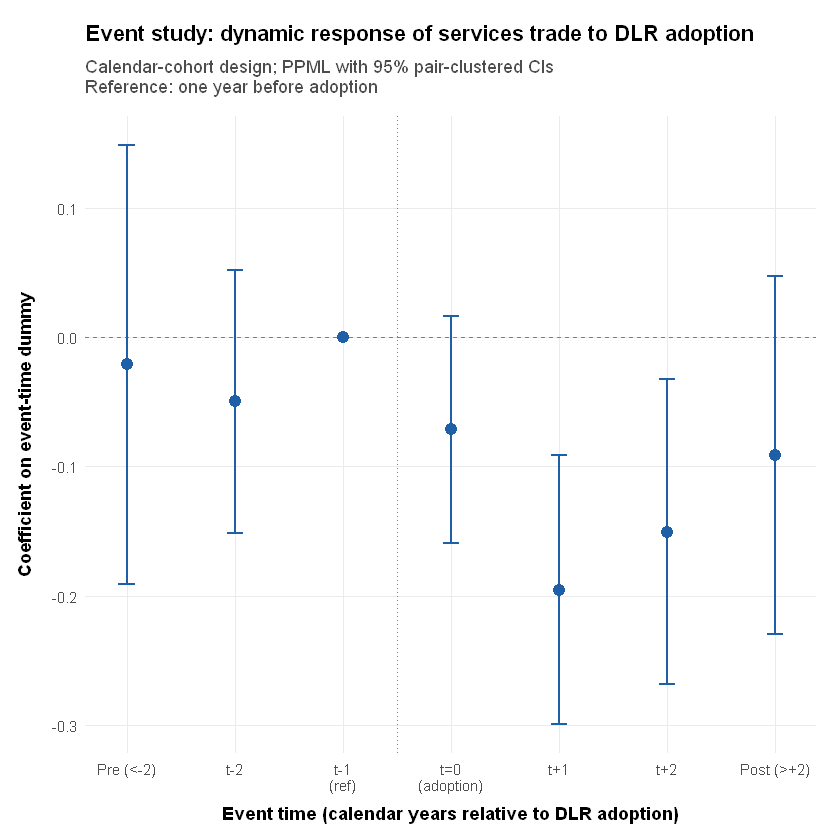

In [20]:
# --- 3e.1 Build calendar-cohort event-time indicators ------------------------

# Step 1: For each (importer, bpm6_category), find the FIRST calendar year
# where dlr_any switches on. This is the treatment-event year (the
# "adoption year") for that importer-product. Importer-products that never
# adopt have adoption_year = NA and serve as never-treated controls.

adoption_year <- df %>%
  filter(dlr_any == 1) %>%
  group_by(importer, bpm6_category) %>%
  summarise(adoption_year = min(year, na.rm = TRUE), .groups = "drop")

n_adopters <- nrow(adoption_year)
n_never    <- length(unique(df$importer)) * length(unique(df$bpm6_category)) - n_adopters

cat(sprintf("\n--- Event-study cohort design ---\n"))
cat(sprintf("  Treated (importer, product) cells:    %s\n",
            format(n_adopters, big.mark = ",")))
cat(sprintf("  Adoption-year distribution: range %d-%d, median %d\n",
            min(adoption_year$adoption_year), max(adoption_year$adoption_year),
            median(adoption_year$adoption_year)))

# Step 2: Attach adoption_year to the full panel. Compute event_time and
# build period dummies. ev_neg1 is the OMITTED reference category.

event_df <- df %>%
  left_join(adoption_year, by = c("importer", "bpm6_category")) %>%
  mutate(
    event_time = year - adoption_year,
    # Never-treated rows have event_time = NA. Without an explicit guard,
    # `as.integer(NA == -2)` returns NA, which would cause fepois to drop
    # all never-treated observations from the regression — collapsing the
    # sample from ~1.4M to the treated-only window (~100K) and rendering
    # the event-time coefficients identified only off within-treated
    # variation. We assign 0 to every event dummy for never-treated rows
    # so they serve as the cross-sectional control group, as the
    # calendar-cohort design requires.
    ev_neg2 = ifelse(is.na(event_time), 0L, as.integer(event_time == -2)),
    ev_neg1 = ifelse(is.na(event_time), 0L, as.integer(event_time == -1)),
    ev_0    = ifelse(is.na(event_time), 0L, as.integer(event_time ==  0)),
    ev_pos1 = ifelse(is.na(event_time), 0L, as.integer(event_time ==  1)),
    ev_pos2 = ifelse(is.na(event_time), 0L, as.integer(event_time ==  2)),
    ev_pre  = ifelse(is.na(event_time), 0L, as.integer(event_time < -2)),
    ev_post = ifelse(is.na(event_time), 0L, as.integer(event_time >  2))
  )

cat(sprintf("\n  Event-time distribution (counts per period):\n"))
cat(sprintf("    Pre-window  (t < -2):     %s rows\n",
            format(sum(event_df$ev_pre, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    t = -2:                   %s rows\n",
            format(sum(event_df$ev_neg2, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    t = -1 (reference):       %s rows\n",
            format(sum(event_df$ev_neg1, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    t =  0 (adoption):        %s rows\n",
            format(sum(event_df$ev_0, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    t = +1:                   %s rows\n",
            format(sum(event_df$ev_pos1, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    t = +2:                   %s rows\n",
            format(sum(event_df$ev_pos2, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    Post-window (t > +2):     %s rows\n",
            format(sum(event_df$ev_post, na.rm = TRUE), big.mark = ",")))
cat(sprintf("    Never-treated:            %s rows\n",
            format(sum(is.na(event_df$event_time)), big.mark = ",")))

# --- 3e.2 Estimate event-study specification --------------------------------

# Omit ev_neg1 as the reference category (standard event-study convention).
# All beta coefficients are interpreted as effects relative to one calendar
# year before DLR adoption.

cat("\n--- Estimating calendar-cohort event study ---\n")
m_event <- fepois(
  trade ~ ev_pre + ev_neg2 + ev_0 + ev_pos1 + ev_pos2 + ev_post
        | imp_time + exp_prod_time + pair_prod,
  data    = event_df,
  cluster = ~ pair_id
)
print(summary(m_event))

# --- 3e.3 Extract coefficients and plot the event-time path -----------------

ev_ct <- summary(m_event)$coeftable
ev_plot_df <- data.frame(
  term      = rownames(ev_ct),
  estimate  = ev_ct[, 1],
  std_error = ev_ct[, 2]
) %>%
  mutate(
    period = case_when(
      term == "ev_pre"   ~ -3L,
      term == "ev_neg2"  ~ -2L,
      term == "ev_0"     ~  0L,
      term == "ev_pos1"  ~  1L,
      term == "ev_pos2"  ~  2L,
      term == "ev_post"  ~  3L,
      TRUE               ~ NA_integer_
    ),
    ci_low  = estimate - 1.96 * std_error,
    ci_high = estimate + 1.96 * std_error
  ) %>%
  filter(!is.na(period)) %>%
  arrange(period)

# Add the reference category (t = -1) as a zero with no CI so the plot
# shows the conventional "kink at -1" baseline.
ref_row <- data.frame(
  term = "ev_neg1 (ref)", estimate = 0, std_error = NA,
  period = -1L, ci_low = NA, ci_high = NA
)
ev_plot_df <- bind_rows(ev_plot_df, ref_row) %>% arrange(period)

p_event <- ggplot(ev_plot_df, aes(x = period, y = estimate)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50") +
  geom_vline(xintercept = -0.5, linetype = "dotted", colour = "grey50") +
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), width = 0.15,
                colour = "#1f5fa8", linewidth = 0.6, na.rm = TRUE) +
  geom_point(size = 3, colour = "#1f5fa8") +
  scale_x_continuous(breaks = -3:3,
                     labels = c("Pre (<-2)", "t-2", "t-1\n(ref)", "t=0\n(adoption)",
                                "t+1", "t+2", "Post (>+2)")) +
  labs(title    = "Event study: dynamic response of services trade to DLR adoption",
       subtitle = "Calendar-cohort design; PPML with 95% pair-clustered CIs\nReference: one year before adoption",
       x        = "Event time (calendar years relative to DLR adoption)",
       y        = "Coefficient on event-time dummy") +
  theme_thesis()

ggsave(file.path(FIGURES_DIR, "fig_event_study.png"),
       p_event, width = 10, height = 6, dpi = 300, bg = "white")
print(p_event)

# --- 3e.4 Report event-study coefficient table -------------------------------

cat("\n--- Event-study coefficient summary ---\n")
print(ev_plot_df %>%
        select(period, term, estimate, std_error, ci_low, ci_high) %>%
        mutate(across(c(estimate, std_error, ci_low, ci_high),
                       ~ round(.x, 4))))

readr::write_csv(ev_plot_df, file.path(TABLES_DIR, "event_study_coefficients.csv"))
cat(sprintf("\nSaved: %s\n", file.path(TABLES_DIR, "event_study_coefficients.csv")))

### 3f. Robustness: DLR effect on high-data Telecom services

Model 5 estimated the differential effect of DLR on the entire digital BPM6 set (Telecom 9.1/9.2/9.3, Other business services, IP charges) versus non-digital services. This section re-estimates the same logic but restricts the "digital" indicator to the three pure-data-transmission categories — Telecom 9.1 (Telecommunications), Telecom 9.2 (Computer services), Telecom 9.3 (Information services) — using the indicator `is_high_data`.

Empirical motivation: when the upstream DTI×BPM6 mapping was inspected, P6 regulations were found to fire on the Telecom 9.1-9.3 subset but not on Other business services or IP charges. Within the digital set, the actively-treated subset is therefore exactly the high-data Telecom categories. This specification confirms that the differential effect on digital products in Model 5 is in fact concentrated in this narrower high-data subset, rather than being averaged across categories where DLR does not bind.

Original specification (preserved as historical context): an initial design attempted a three-tier triple-difference `dlr_any + dlr_any:is_digital_medium + dlr_any:is_high_data` to identify $\beta_2 < \beta_3 < 0$ heterogeneity within the digital set. The "medium-data" interaction was perfectly collinear with `dlr_any` at zero (DLR never fires on the medium-digital categories), so fixest dropped that term and the remaining specification collapsed to `dlr_any + dlr_any:is_high_data`. We report it accordingly: Model 8 is a robustness restriction of Model 5 to the actively-treated high-data subset, NOT a triple-difference design.

**Coefficient interpretation:**

* $\beta_1$ on `dlr_any` — DLR effect on the non-high-data baseline (everything outside Telecom 9.1-9.3)
* $\beta_2$ on `dlr_any:is_high_data` — additional effect on Telecom 9.1-9.3 relative to that baseline

The combined effect on Telecom 9.1-9.3 is $\beta_1 + \beta_2$. Sign expectation: $\beta_1 \leq 0$ (DLR depresses any service it bites on, including non-digital incidentally-affected categories) and $\beta_2 \leq 0$ (the high-data Telecom categories are hit harder, consistent with the Melitz fixed-cost prediction for data-intensive services).

In [21]:
# --- 3f.1 Build the high-data Telecom indicator ------------------------------

high_data_cats <- c("Telecom_9_1", "Telecom_9_2", "Telecom_9_3")
df$is_high_data <- as.integer(df$bpm6_category %in% high_data_cats)

cat(sprintf("\n--- Model 8 setup: high-data Telecom robustness ---\n"))
cat(sprintf("  High-data Telecom categories: %s\n",
            paste(high_data_cats, collapse = ", ")))
cat(sprintf("  Share of panel rows in high-data Telecom: %.1f%%\n",
            100 * mean(df$is_high_data)))
cat(sprintf("  Share of panel rows in any digital category: %.1f%%\n",
            100 * mean(df$is_digital)))

# --- 3f.2 Estimate Model 8: DLR x High-data Telecom --------------------------

# Same FE as Model 1 / Model 5 (Heid-Larch-Yotov 3-way structure).
# is_high_data is time-invariant in product, absorbed by pair_prod.
# dlr_any:is_high_data varies on (j, k, t) and survives all three FE.
#
# Note: the original specification included `dlr_any:is_digital_medium`
# as a third coefficient (digital-but-not-high-data). That term is
# identically zero across the panel because the DTI x BPM6 mapping does not
# flag P6 regulations as binding on Other business services or IP charges.
# fixest correctly drops it for collinearity. We omit it here for clarity.

cat("\n--- Model 8: DLR x High-data Telecom (robustness on Model 5) ---\n")
m_high_data <- fepois(
  trade ~ dlr_any + dlr_any:is_high_data
        | imp_time + exp_prod_time + pair_prod,
  data    = df,
  cluster = ~ pair_id
)
print(summary(m_high_data))

# --- 3f.3 Compute implied total effect on high-data Telecom -----------------

ct <- summary(m_high_data)$coeftable
b_dlr        <- ct["dlr_any", 1]
b_high_data  <- if ("dlr_any:is_high_data" %in% rownames(ct))
                  ct["dlr_any:is_high_data", 1] else NA_real_

total_baseline <- b_dlr
total_high_data <- b_dlr + b_high_data

cat("\n--- Implied total effect of DLR by category tier ---\n")
cat(sprintf("  Baseline (non-Telecom 9.1-9.3):  %+.4f -> %+.1f%% trade change\n",
            total_baseline, 100 * (exp(total_baseline) - 1)))
cat(sprintf("  High-data Telecom (9.1/9.2/9.3): %+.4f -> %+.1f%% trade change\n",
            total_high_data, 100 * (exp(total_high_data) - 1)))

implied_df <- data.frame(
  tier = c("Baseline (non high-data)",
           "High-data Telecom (9.1, 9.2, 9.3)"),
  beta_total = c(total_baseline, total_high_data),
  pct_change = round(100 * (exp(c(total_baseline, total_high_data)) - 1), 2)
)
readr::write_csv(implied_df, file.path(TABLES_DIR, "model8_implied_effects.csv"))
cat(sprintf("\nSaved: %s\n", file.path(TABLES_DIR, "model8_implied_effects.csv")))


--- Model 8 setup: high-data Telecom robustness ---
  High-data Telecom categories: Telecom_9_1, Telecom_9_2, Telecom_9_3
  Share of panel rows in high-data Telecom: 9.7%
  Share of panel rows in any digital category: 29.5%

--- Model 8: DLR x High-data Telecom (robustness on Model 5) ---


NOTE: 3/8,261/4,814 fixed-effects (25,061 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,366,148
Fixed-effects: imp_time: 961,  exp_prod_time: 28,930,  pair_prod: 31,553
Standard-errors: Clustered (pair_id) 
                      Estimate Std. Error   z value Pr(>|z|) 
dlr_any              -0.101669   0.070752 -1.436978  0.15072 
dlr_any:is_high_data -0.001556   0.080685 -0.019281  0.98462 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -8.036e+13   Adj. Pseudo R2: 0.742727
           BIC:  1.607e+14     Squared Cor.: 0.524583

--- Implied total effect of DLR by category tier ---
  Baseline (non-Telecom 9.1-9.3):  -0.1017 -> -9.7% trade change
  High-data Telecom (9.1/9.2/9.3): -0.1032 -> -9.8% trade change

Saved: ../outputs/gravity_results/tables/model8_implied_effects.csv


### 3g. Heterogeneity by exporter income level

The Melitz-with-data-localization mechanism predicts that fixed-cost shocks fall more heavily on smaller, less productive firms (Melitz 2003) — and by extension, on exporters whose firms are smaller or less productive on average. A natural empirical proxy at the country level: exporter income. High-income exporters (advanced economies) have larger, more productive firms with deeper compliance capacities; middle and low-income exporters have smaller firms with thinner margins.

The Melitz prediction: $|\hat\beta_{\text{DLR}}^{\text{lower-income}}| > |\hat\beta_{\text{DLR}}^{\text{high-income}}|$ — i.e., data localization disproportionately depresses imports *from* lower-income countries.

**Classification.** Exporters are split into high-income vs. middle/low-income using the World Bank country-classification convention. For thesis purposes, we use a simple GDP-per-capita-based split: exporters in the top tercile of average pre-period GDP per capita are "high-income"; the rest are "middle/lower-income." Pre-period averaging (first five panel years) ensures the classification is exogenous to DLR adoption.

The baseline specification is estimated on each subsample separately. A statistically significant difference in coefficients between the two subsamples — testable via interacted specification — would support the firm-heterogeneity channel.

In [22]:
# --- 3g.1 Build exporter-income classification -------------------------------

# We need a pre-period GDP-per-capita classification. WDI was already pulled
# in Section 1B if has_gravity_controls is TRUE. If not, this section skips.

if (exists("has_gravity_controls") && has_gravity_controls &&
    "gdpcap_o" %in% names(df) && sum(!is.na(df$gdpcap_o)) > 0) {

  pre_period_end_g <- min(df$year, na.rm = TRUE) + 4

  exp_income <- df %>%
    filter(year <= pre_period_end_g, !is.na(gdpcap_o)) %>%
    group_by(exporter) %>%
    summarise(avg_gdpcap = mean(gdpcap_o, na.rm = TRUE), .groups = "drop")

  # Split at the 66.7th percentile (top tercile = high-income).
  income_threshold <- quantile(exp_income$avg_gdpcap, 0.667, na.rm = TRUE)
  exp_income$income_tier <- ifelse(exp_income$avg_gdpcap >= income_threshold,
                                    "high", "middle_low")

  cat(sprintf("\nExporter income split at GDP/capita = $%.0f (top tercile)\n",
              income_threshold))
  cat(sprintf("  High-income exporters:        %d countries\n",
              sum(exp_income$income_tier == "high")))
  cat(sprintf("  Middle/lower-income exporters: %d countries\n",
              sum(exp_income$income_tier == "middle_low")))

  df_inc <- df %>%
    left_join(exp_income %>% select(exporter, income_tier),
              by = "exporter") %>%
    filter(!is.na(income_tier))

  # --- 3g.2 Estimate baseline on each subsample ---

  cat("\n--- Model 8a: Baseline DLR on HIGH-INCOME exporters only ---\n")
  m_inc_high <- fepois(
    trade ~ dlr_any | imp_time + exp_prod_time + pair_prod,
    data    = df_inc %>% filter(income_tier == "high"),
    cluster = ~ pair_id
  )
  print(summary(m_inc_high))

  cat("\n--- Model 8b: Baseline DLR on MIDDLE/LOWER-INCOME exporters only ---\n")
  m_inc_low <- fepois(
    trade ~ dlr_any | imp_time + exp_prod_time + pair_prod,
    data    = df_inc %>% filter(income_tier == "middle_low"),
    cluster = ~ pair_id
  )
  print(summary(m_inc_low))

  # --- 3g.3 Interacted specification for formal difference test ---

  # An interaction with the income-tier indicator on the full sample lets us
  # formally test whether the DLR effect differs across the two groups.
  df_inc$is_high_inc <- as.integer(df_inc$income_tier == "high")

  cat("\n--- Model 8: DLR x exporter income tier (formal difference test) ---\n")
  m_income_int <- fepois(
    trade ~ dlr_any + dlr_any:is_high_inc
          | imp_time + exp_prod_time + pair_prod,
    data    = df_inc,
    cluster = ~ pair_id
  )
  print(summary(m_income_int))

  # --- 3g.4 Implied effects ---

  ct_inc <- summary(m_income_int)$coeftable
  b_dlr_low  <- ct_inc["dlr_any", 1]
  b_dlr_high <- if ("dlr_any:is_high_inc" %in% rownames(ct_inc))
                  b_dlr_low + ct_inc["dlr_any:is_high_inc", 1] else b_dlr_low

  cat("\n--- Implied DLR effects by exporter income tier ---\n")
  cat(sprintf("  Middle/lower-income exporters: %+.4f -> %+.1f%% trade change\n",
              b_dlr_low,  100 * (exp(b_dlr_low) - 1)))
  cat(sprintf("  High-income exporters:         %+.4f -> %+.1f%% trade change\n",
              b_dlr_high, 100 * (exp(b_dlr_high) - 1)))

  if ("dlr_any:is_high_inc" %in% rownames(ct_inc)) {
    diff_p <- ct_inc["dlr_any:is_high_inc", 4]
    cat(sprintf("  Difference (high - middle/low): p-value = %.4g\n", diff_p))
    if (diff_p < 0.05) {
      cat("  -> Statistically significant heterogeneity by exporter income.\n")
    } else {
      cat("  -> Cannot reject equal effects across income tiers (p >= 0.05).\n")
    }
  }
} else {
  cat("\n--- Section 3g skipped: WDI GDP/capita data not available ---\n")
  cat("Run Section 1B with has_gravity_controls = TRUE to enable.\n")
  m_inc_high <- NULL
  m_inc_low  <- NULL
  m_income_int <- NULL
}


Exporter income split at GDP/capita = $8216 (top tercile)
  High-income exporters:        52 countries
  Middle/lower-income exporters: 104 countries

--- Model 8a: Baseline DLR on HIGH-INCOME exporters only ---


NOTE: 3/1,402/1,156 fixed-effects (4,593 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 873,582
Fixed-effects: imp_time: 960,  exp_prod_time: 12,118,  pair_prod: 17,568
Standard-errors: Clustered (pair_id) 
         Estimate Std. Error  z value Pr(>|z|)    
dlr_any -0.104361   0.049841 -2.09387 0.036271 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -6.733e+13   Adj. Pseudo R2: 0.733332
           BIC:  1.347e+14     Squared Cor.: 0.528227

--- Model 8b: Baseline DLR on MIDDLE/LOWER-INCOME exporters only ---


NOTE: 0/4,467/2,365 fixed-effects (11,972 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 464,848
Fixed-effects: imp_time: 949,  exp_prod_time: 14,194,  pair_prod: 12,641
Standard-errors: Clustered (pair_id) 
         Estimate Std. Error  z value Pr(>|z|) 
dlr_any -0.105785   0.113227 -0.93428  0.35016 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -1.213e+13   Adj. Pseudo R2: 0.722826
           BIC:  2.427e+13     Squared Cor.: 0.447279

--- Model 8: DLR x exporter income tier (formal difference test) ---


NOTE: 3/5,869/3,521 fixed-effects (16,565 observations) removed because of only 0 outcomes or singletons.



Poisson estimation, Dep. Var.: trade
Observations: 1,338,430
Fixed-effects: imp_time: 961,  exp_prod_time: 26,312,  pair_prod: 30,209
Standard-errors: Clustered (pair_id) 
                     Estimate Std. Error   z value Pr(>|z|)    
dlr_any             -0.169693   0.079460 -2.135584 0.032713 *  
dlr_any:is_high_inc  0.077228   0.083818  0.921373 0.356855    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood: -7.957e+13   Adj. Pseudo R2: 0.741848
           BIC:  1.591e+14     Squared Cor.: 0.525018

--- Implied DLR effects by exporter income tier ---
  Middle/lower-income exporters: -0.1697 -> -15.6% trade change
  High-income exporters:         -0.0925 -> -8.8% trade change
  Difference (high - middle/low): p-value = 0.3569
  -> Cannot reject equal effects across income tiers (p >= 0.05).


### 3h. Extensive margin: probability of any bilateral trade

The headline PPML models (Section 3a-3b) and their extensions (Sections 3e-3g) estimate the **combined intensive-and-extensive margin** effect of data localization: when DLR fires, both the number of active trade relationships and the volume of existing relationships can change, and PPML on levels picks up the joint movement. The thesis title, however, focuses specifically on the **extensive margin** — the probability that any positive bilateral trade occurs in a given (importer, exporter, product, year) cell. This section isolates that pure extensive-margin effect.

The dependent variable is a binary indicator:

$$y_{ij,k,t} = \mathbb{1}\{X_{ij,k,t} > 0\}$$

We estimate two complementary specifications:

**Linear Probability Model (LPM)** with the same three-way FE structure as the headline. The coefficient is directly interpretable as a percentage-point change in the probability of positive trade. Linear estimation avoids the incidental-parameters bias that plagues nonlinear estimators with many fixed effects (Greene 2004); cluster-robust standard errors at pair_id handle the heteroscedasticity inherent in binary outcomes and within-pair serial correlation across time and products. This is the workhorse modern-gravity extensive-margin specification (Heid, Larch and Yotov 2021).

**Pooled Probit** with explicit gravity controls instead of fixed effects, following Helpman, Melitz and Rubinstein (2008, *QJE*). The structural-functional-form alternative to LPM. Coefficients are not directly interpretable; we report average marginal effects (AMEs) via `marginaleffects::avg_slopes`, which translate the Probit coefficient into the same percentage-point interpretation as the LPM. We also re-estimate the same specification under a Logit link as a sensitivity check — if Probit and Logit AMEs agree closely, the link-function choice is not binding.

**A note on diagnostics.** Conventional residual-normality and Durbin-Watson tests are not informative for binary-outcome models: LPM errors are non-normal by construction (Bernoulli outcome) and heteroscedasticity is inherent. We rely instead on (i) the predicted-probability out-of-range check for LPM, (ii) the within-pair-product switching rate as a sample-quality measure, (iii) the Pregibon (1980) linktest for Probit functional-form fit, and (iv) the Probit-vs-Logit AME comparison for link-function sensitivity. Cluster-robust standard errors at pair_id handle heteroscedasticity and serial correlation in both models.

**Three specifications for each estimator.** Each is the extensive-margin counterpart of a headline model:

| # | Model | Estimator | Counterpart |
|---|---|---|---|
| 10 | Baseline | LPM | Model 1 |
| 11 | DLR x Digital product | LPM | Model 5 |
| 12 | DLR + trade-policy controls | LPM | Model 6 |
| 13 | Baseline (pooled) | Probit | Model 1 / Model 10 |
| 14 | Baseline (sensitivity) | Logit | Model 13 |

The two-tier reading: LPM gives the within-pair-product extensive-margin response (sharp identification); pooled Probit gives the cross-sectional structural-form interpretation with gravity controls (broader identification, parametric).

In [23]:
# --- 3h.1 Build the binary extensive-margin outcome --------------------------

df$trade_positive <- as.integer(df$trade > 0)

cat("\n--- Extensive margin: dependent-variable summary ---\n")
cat(sprintf("  Total rows in panel:           %s\n",
            format(nrow(df), big.mark = ",")))
cat(sprintf("  Rows with trade > 0:           %s (%.1f%%)\n",
            format(sum(df$trade_positive), big.mark = ","),
            100 * mean(df$trade_positive)))
cat(sprintf("  Rows with trade = 0:           %s (%.1f%%)\n",
            format(sum(!df$trade_positive), big.mark = ","),
            100 * (1 - mean(df$trade_positive))))

# --- 3h.2 Sample-quality check: within-pair-product switching rate -----------

switch_rates <- df %>%
  group_by(importer, exporter, bpm6_category) %>%
  summarise(
    n_obs      = n(),
    n_switches = sum(diff(trade_positive) != 0, na.rm = TRUE),
    has_switch = as.integer(n_switches > 0),
    .groups = "drop"
  )

cat(sprintf("\n  Within-pair-product switching rate: %.1f%% of pair-products\n",
            100 * mean(switch_rates$has_switch)))
cat("  (Pair-products that switch from 0 to positive or vice versa at\n")
cat("  least once during the panel period - these are the cells\n")
cat("  contributing identifying variation to the LPM extensive margin.)\n")

# --- 3h.3 LPM Models 10-12 ---------------------------------------------------

cat("\n--- Model 10: LPM baseline ---\n")
m_lpm_baseline <- feols(
  trade_positive ~ dlr_any | imp_time + exp_prod_time + pair_prod,
  data    = df,
  cluster = ~ pair_id
)
print(summary(m_lpm_baseline))

fv_baseline <- fitted(m_lpm_baseline)
pct_oor <- 100 * mean(fv_baseline < 0 | fv_baseline > 1, na.rm = TRUE)
cat(sprintf("\n  Predicted probabilities outside [0, 1]: %.2f%%\n", pct_oor))
if (pct_oor > 20) {
  cat("  -> LPM is fitting poorly at the tails; rely on Probit results.\n")
} else if (pct_oor > 5) {
  cat("  -> Minor caveat; LPM remains acceptable but note in thesis.\n")
} else {
  cat("  -> LPM predictions are well-behaved; minimal concern.\n")
}

cat("\n--- Model 11: LPM with DLR x Digital product ---\n")
m_lpm_digital <- feols(
  trade_positive ~ dlr_any + dlr_any:is_digital
                 | imp_time + exp_prod_time + pair_prod,
  data    = df,
  cluster = ~ pair_id
)
print(summary(m_lpm_digital))

if (exists("has_gravity_controls") && has_gravity_controls) {
  cat("\n--- Model 12: LPM with trade-policy controls ---\n")

  # Named data object so fixest::summary() can refetch the data when
  # computing cluster-robust SEs. An anonymous `df %>% filter(...)`
  # expression doesn't survive to that call.
  lpm_policy_df <- df %>%
    filter(!is.na(both_wto), !is.na(both_eu), !is.na(rta_services))

  m_lpm_policy <- feols(
    trade_positive ~ dlr_any + both_wto + both_eu + rta_services
                   | imp_time + exp_prod_time + pair_prod,
    data    = lpm_policy_df,
    cluster = ~ pair_id
  )
  print(summary(m_lpm_policy))
} else {
  cat("\n--- Model 12 skipped: CEPII gravity controls not loaded ---\n")
  m_lpm_policy <- NULL
}

# --- 3h.4 Pooled Probit (Model 13) ------------------------------------------

m_probit   <- NULL
m_logit    <- NULL
ame_probit <- NULL
ame_logit  <- NULL
p_link     <- NA_real_

if (exists("has_gravity_controls") && has_gravity_controls) {

  cat("\n--- Model 13: Pooled Probit with gravity controls ---\n")

  # Build derived variables on df FIRST, before filtering. Several columns
  # the Probit needs are produced in Section 3d's classic_df subsample
  # (log_sci, log_gdp_o, log_gdp_d) but not in the master df. We construct
  # them here defensively so Section 3h is self-contained and does not
  # depend on Section 3d having run successfully.

  # log_sci from scaled_sci_2021 (matches Section 3d's transformation).
  if ("scaled_sci_2021" %in% names(df) && !"log_sci" %in% names(df)) {
    df$log_sci <- log1p(df$scaled_sci_2021)
  }

  # log_gdp_o and log_gdp_d from gdpcap_o and gdpcap_d if not already present.
  # CEPII / WDI typically loaded as gdp_o, gdp_d, gdpcap_o, gdpcap_d.
  if (!"log_gdp_o" %in% names(df)) {
    if ("gdp_o" %in% names(df)) {
      df$log_gdp_o <- ifelse(df$gdp_o > 0, log(df$gdp_o), NA_real_)
    } else if ("gdpcap_o" %in% names(df)) {
      df$log_gdp_o <- ifelse(df$gdpcap_o > 0, log(df$gdpcap_o), NA_real_)
    }
  }
  if (!"log_gdp_d" %in% names(df)) {
    if ("gdp_d" %in% names(df)) {
      df$log_gdp_d <- ifelse(df$gdp_d > 0, log(df$gdp_d), NA_real_)
    } else if ("gdpcap_d" %in% names(df)) {
      df$log_gdp_d <- ifelse(df$gdpcap_d > 0, log(df$gdpcap_d), NA_real_)
    }
  }

  # Diagnostic: confirm the required columns exist before filtering.
  required_cols <- c("log_dist", "contig", "comlang_off", "col45",
                      "both_wto", "both_eu", "rta_services", "log_sci")
  missing_cols <- setdiff(required_cols, names(df))
  if (length(missing_cols) > 0) {
    cat(sprintf("  WARNING: missing required Probit columns: %s\n",
                paste(missing_cols, collapse = ", ")))
    cat("  Probit (Model 13) and Logit (Model 14) will be skipped.\n")
    probit_df <- NULL
  } else {
    probit_df <- df %>%
      filter(!is.na(log_dist), !is.na(contig), !is.na(comlang_off),
             !is.na(col45), !is.na(both_wto), !is.na(both_eu),
             !is.na(rta_services), !is.na(log_sci))
  }

  if (!is.null(probit_df)) {

    has_gdp_probit <- "log_gdp_o" %in% names(probit_df) &&
                      "log_gdp_d" %in% names(probit_df) &&
                      sum(!is.na(probit_df$log_gdp_o)) > 0
    if (has_gdp_probit) {
      probit_df <- probit_df %>% filter(!is.na(log_gdp_o), !is.na(log_gdp_d))
    }

    probit_df$year_factor <- as.factor(probit_df$year)
    probit_df$bpm6_factor <- as.factor(probit_df$bpm6_category)

    cat(sprintf("  Probit sample: %s rows (%.1f%% of full panel)\n",
                format(nrow(probit_df), big.mark = ","),
                100 * nrow(probit_df) / nrow(df)))

    if (has_gdp_probit) {
      probit_formula <- trade_positive ~ dlr_any +
                        log_gdp_o + log_gdp_d + log_dist + contig +
                        comlang_off + col45 + both_wto + both_eu +
                        rta_services + log_sci + bpm6_factor + year_factor
    } else {
      probit_formula <- trade_positive ~ dlr_any +
                        log_dist + contig + comlang_off + col45 +
                        both_wto + both_eu + rta_services + log_sci +
                        bpm6_factor + year_factor
    }

    m_probit <- glm(probit_formula,
                     family = binomial(link = "probit"),
                     data   = probit_df)

    for (pkg in c("sandwich", "lmtest", "marginaleffects", "car")) {
      if (!requireNamespace(pkg, quietly = TRUE)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      }
    }
    probit_vcov <- sandwich::vcovCL(m_probit, cluster = ~ pair_id)
    probit_test <- lmtest::coeftest(m_probit, vcov. = probit_vcov)

    rows_to_show <- c("(Intercept)", "dlr_any",
                       "log_gdp_o", "log_gdp_d", "log_dist", "contig",
                       "comlang_off", "col45", "both_wto", "both_eu",
                       "rta_services", "log_sci")
    show_rows <- intersect(rows_to_show, rownames(probit_test))
    cat("\n  Probit coefficients (cluster-robust SEs at pair_id):\n")
    print(round(probit_test[show_rows, , drop = FALSE], 4))

    cat("\n--- Average marginal effects on DLR (Probit) ---\n")
    ame_probit <- tryCatch({
      marginaleffects::avg_slopes(m_probit, variables = "dlr_any",
                                   vcov = probit_vcov)
    }, error = function(e) {
      cat(sprintf("  AME computation failed: %s\n", e$message)); NULL
    })
    if (!is.null(ame_probit)) {
      print(ame_probit)
      cat(sprintf("\n  Interpretation: DLR adoption changes the probability of\n"))
      cat(sprintf("  positive bilateral trade by %.2f pp on average (Probit).\n",
                  100 * ame_probit$estimate[1]))
    }

    cat("\n--- Pregibon linktest for Probit functional form ---\n")
    probit_df$linpred    <- predict(m_probit, type = "link")
    probit_df$linpred_sq <- probit_df$linpred^2
    m_link <- glm(trade_positive ~ linpred + linpred_sq,
                   family = binomial(link = "probit"),
                   data   = probit_df)
    link_ct <- summary(m_link)$coefficients
    if ("linpred_sq" %in% rownames(link_ct)) {
      p_link <- link_ct["linpred_sq", "Pr(>|z|)"]
      cat(sprintf("  Coefficient on linpred^2: %.4f (p = %.4g)\n",
                  link_ct["linpred_sq", "Estimate"], p_link))
      if (p_link < 0.05) {
        cat("  -> Reject H0 of correct Probit functional form (p < 0.05).\n")
        cat("     Interpret the Logit sensitivity check carefully.\n")
      } else {
        cat("  -> Cannot reject Probit functional form (p >= 0.05). OK.\n")
      }
    }

    cat("\n--- VIF check on Probit gravity controls ---\n")
    vif_probit <- tryCatch(car::vif(m_probit),
                            error = function(e) NULL)
    if (!is.null(vif_probit)) {
      if (is.matrix(vif_probit)) {
        gvif_adj <- vif_probit[, 3]
        cat("  Generalized VIF^(1/(2*Df)) (>2 conventionally flagged):\n")
        print(round(gvif_adj[gvif_adj > 1.5], 2))
      } else {
        cat("  VIF (>10 conventionally flagged):\n")
        print(round(vif_probit[vif_probit > 2], 2))
      }
    }

    # --- 3h.5 Model 14: Logit sensitivity check ---

    cat("\n--- Model 14: Pooled Logit (link-function sensitivity check) ---\n")
    m_logit <- glm(probit_formula,
                    family = binomial(link = "logit"),
                    data   = probit_df)
    logit_vcov <- sandwich::vcovCL(m_logit, cluster = ~ pair_id)
    logit_test <- lmtest::coeftest(m_logit, vcov. = logit_vcov)
    print(round(logit_test[show_rows, , drop = FALSE], 4))

    cat("\n--- AME on DLR (Logit) ---\n")
    ame_logit <- tryCatch({
      marginaleffects::avg_slopes(m_logit, variables = "dlr_any",
                                   vcov = logit_vcov)
    }, error = function(e) {
      cat(sprintf("  AME computation failed: %s\n", e$message)); NULL
    })
    if (!is.null(ame_logit) && !is.null(ame_probit)) {
      print(ame_logit)
      cat(sprintf("\n  Logit AME: %.4f pp; Probit AME: %.4f pp\n",
                  100 * ame_logit$estimate[1],
                  100 * ame_probit$estimate[1]))
      rel_diff <- abs(ame_logit$estimate[1] - ame_probit$estimate[1]) /
                    abs(ame_probit$estimate[1])
      cat(sprintf("  Relative difference: %.1f%%\n", 100 * rel_diff))
      if (rel_diff < 0.20) {
        cat("  -> Probit and Logit AMEs agree (<20%% difference). OK.\n")
      } else {
        cat("  -> Notable difference; report both in the thesis.\n")
      }
    }
  }
} else {
  cat("\n--- Models 13-14 skipped: CEPII gravity controls not loaded ---\n")
}

# --- 3h.6 Self-contained export: extensive_margin_results.xlsx + CSV --------

cat("\n--- Building extensive-margin results export ---\n")

em_models <- list()
if (!is.null(m_lpm_baseline)) em_models[["m_lpm_baseline"]] <- m_lpm_baseline
if (!is.null(m_lpm_digital))  em_models[["m_lpm_digital"]]  <- m_lpm_digital
if (!is.null(m_lpm_policy))   em_models[["m_lpm_policy"]]   <- m_lpm_policy

em_labels <- c(
  m_lpm_baseline = "(10) LPM baseline",
  m_lpm_digital  = "(11) LPM x Digital product",
  m_lpm_policy   = "(12) LPM + trade policy controls"
)

# Inline sig_stars helper (may not exist yet if Section 5 has not run).
sig_stars_em <- function(p) {
  ifelse(is.na(p), "",
    ifelse(p < 0.01, "***",
      ifelse(p < 0.05, "**",
        ifelse(p < 0.10, "*", ""))))
}

em_coef_long <- purrr::map_dfr(names(em_models), function(nm) {
  fit <- em_models[[nm]]
  ct  <- summary(fit)$coeftable
  data.frame(
    model          = em_labels[[nm]],
    model_internal = nm,
    variable       = rownames(ct),
    estimate       = ct[, 1],
    std_error      = ct[, 2],
    z_stat         = ct[, 3],
    p_value        = ct[, 4],
    stars          = sig_stars_em(ct[, 4]),
    ci_low_95      = ct[, 1] - 1.96 * ct[, 2],
    ci_high_95     = ct[, 1] + 1.96 * ct[, 2],
    stringsAsFactors = FALSE
  )
})

if (!is.null(m_probit)) {
  probit_long <- data.frame(
    model       = "(13) Probit (pooled)",
    model_internal = "m_probit",
    variable    = rownames(probit_test),
    estimate    = probit_test[, "Estimate"],
    std_error   = probit_test[, "Std. Error"],
    z_stat      = probit_test[, "z value"],
    p_value     = probit_test[, "Pr(>|z|)"],
    stars       = sig_stars_em(probit_test[, "Pr(>|z|)"]),
    ci_low_95   = probit_test[, "Estimate"] - 1.96 * probit_test[, "Std. Error"],
    ci_high_95  = probit_test[, "Estimate"] + 1.96 * probit_test[, "Std. Error"],
    stringsAsFactors = FALSE
  ) %>%
    filter(variable %in% c("(Intercept)", "dlr_any",
                            "log_gdp_o", "log_gdp_d", "log_dist", "contig",
                            "comlang_off", "col45", "both_wto", "both_eu",
                            "rta_services", "log_sci"))
  em_coef_long <- bind_rows(em_coef_long, probit_long)
}

if (!is.null(m_logit)) {
  logit_long <- data.frame(
    model       = "(14) Logit (sensitivity)",
    model_internal = "m_logit",
    variable    = rownames(logit_test),
    estimate    = logit_test[, "Estimate"],
    std_error   = logit_test[, "Std. Error"],
    z_stat      = logit_test[, "z value"],
    p_value     = logit_test[, "Pr(>|z|)"],
    stars       = sig_stars_em(logit_test[, "Pr(>|z|)"]),
    ci_low_95   = logit_test[, "Estimate"] - 1.96 * logit_test[, "Std. Error"],
    ci_high_95  = logit_test[, "Estimate"] + 1.96 * logit_test[, "Std. Error"],
    stringsAsFactors = FALSE
  ) %>%
    filter(variable %in% c("(Intercept)", "dlr_any",
                            "log_gdp_o", "log_gdp_d", "log_dist", "contig",
                            "comlang_off", "col45", "both_wto", "both_eu",
                            "rta_services", "log_sci"))
  em_coef_long <- bind_rows(em_coef_long, logit_long)
}

ame_table <- data.frame(
  model = character(0), variable = character(0),
  ame_estimate = numeric(0), ame_std_error = numeric(0),
  ame_p_value = numeric(0), ame_pct_pts = numeric(0),
  stringsAsFactors = FALSE
)
if (!is.null(ame_probit)) {
  ame_table <- bind_rows(ame_table, data.frame(
    model = "(13) Probit", variable = "dlr_any",
    ame_estimate  = ame_probit$estimate[1],
    ame_std_error = ame_probit$std.error[1],
    ame_p_value   = ame_probit$p.value[1],
    ame_pct_pts   = round(100 * ame_probit$estimate[1], 3),
    stringsAsFactors = FALSE
  ))
}
if (!is.null(ame_logit)) {
  ame_table <- bind_rows(ame_table, data.frame(
    model = "(14) Logit", variable = "dlr_any",
    ame_estimate  = ame_logit$estimate[1],
    ame_std_error = ame_logit$std.error[1],
    ame_p_value   = ame_logit$p.value[1],
    ame_pct_pts   = round(100 * ame_logit$estimate[1], 3),
    stringsAsFactors = FALSE
  ))
}

# Helper: format a value as a character string for display, handling NA.
fmt_diag <- function(x, digits = 2) {
  if (is.na(x)) return(NA_character_)
  if (is.numeric(x)) return(format(round(x, digits), big.mark = ",", scientific = FALSE))
  return(as.character(x))
}

em_diagnostics <- data.frame(
  diagnostic = c(
    "Total panel observations",
    "Rows with trade > 0",
    "Share of positive-trade rows (%)",
    "Within-pair-product switching rate (%)",
    "LPM predicted probabilities outside [0, 1] (%)",
    "Pregibon linktest p-value (Probit)",
    "Probit AME on dlr_any (pp)",
    "Logit AME on dlr_any (pp)",
    "Probit vs Logit AME relative difference (%)"
  ),
  value = c(
    format(nrow(df), big.mark = ","),
    format(sum(df$trade_positive), big.mark = ","),
    fmt_diag(100 * mean(df$trade_positive), 1),
    fmt_diag(100 * mean(switch_rates$has_switch), 1),
    fmt_diag(pct_oor, 2),
    fmt_diag(p_link, 4),
    if (!is.null(ame_probit)) fmt_diag(100 * ame_probit$estimate[1], 3) else NA_character_,
    if (!is.null(ame_logit))  fmt_diag(100 * ame_logit$estimate[1], 3)  else NA_character_,
    if (!is.null(ame_probit) && !is.null(ame_logit))
      fmt_diag(100 * abs(ame_logit$estimate[1] - ame_probit$estimate[1]) /
                 abs(ame_probit$estimate[1]), 1)
    else NA_character_
  ),
  stringsAsFactors = FALSE
)

em_model_stats <- data.frame(
  model = character(0), estimator = character(0),
  n_obs = integer(0), fixed_effects = character(0),
  cluster = character(0), stringsAsFactors = FALSE
)
for (nm in names(em_models)) {
  fit <- em_models[[nm]]
  fe_str <- tryCatch(paste(fit$fixef_vars, collapse = " + "),
                      error = function(e) NA_character_)
  em_model_stats <- bind_rows(em_model_stats, data.frame(
    model         = em_labels[[nm]],
    estimator     = "LPM (feols)",
    n_obs         = nobs(fit),
    fixed_effects = fe_str,
    cluster       = "pair_id",
    stringsAsFactors = FALSE
  ))
}
if (!is.null(m_probit)) {
  em_model_stats <- bind_rows(em_model_stats, data.frame(
    model = "(13) Probit (pooled)",
    estimator = "Probit (glm)",
    n_obs = nobs(m_probit),
    fixed_effects = "year + bpm6 (regressors, not absorbed)",
    cluster = "pair_id (sandwich::vcovCL)",
    stringsAsFactors = FALSE
  ))
}
if (!is.null(m_logit)) {
  em_model_stats <- bind_rows(em_model_stats, data.frame(
    model = "(14) Logit (sensitivity)",
    estimator = "Logit (glm)",
    n_obs = nobs(m_logit),
    fixed_effects = "year + bpm6 (regressors, not absorbed)",
    cluster = "pair_id (sandwich::vcovCL)",
    stringsAsFactors = FALSE
  ))
}

em_readme <- data.frame(
  sheet = c("readme", "coefficients", "ame_comparison",
             "diagnostics", "model_stats"),
  description = c(
    "This sheet - describes what every other sheet contains.",
    "One row per (model x variable). LPM 10-12, Probit 13, Logit 14. Columns: estimate, SE, z-stat, p-value, stars, 95% CI.",
    "Average marginal effects on dlr_any from Probit and Logit. The ame_pct_pts column is the thesis-quotable number.",
    "Sample-quality and functional-form diagnostics: switching rate, LPM out-of-range share, Pregibon linktest p-value, link-function sensitivity.",
    "Per-model: estimator, n obs, fixed effects, clustering scheme."
  ),
  stringsAsFactors = FALSE
)

EXTENSIVE_MARGIN_XLSX <- file.path(TABLES_DIR, "extensive_margin_results.xlsx")
EXTENSIVE_MARGIN_CSV  <- file.path(TABLES_DIR, "extensive_margin_coefficients.csv")

if (!requireNamespace("writexl", quietly = TRUE)) {
  install.packages("writexl", repos = "https://cloud.r-project.org")
}

em_sheets <- list(
  readme         = em_readme,
  coefficients   = em_coef_long,
  ame_comparison = ame_table,
  diagnostics    = em_diagnostics,
  model_stats    = em_model_stats
)
em_sheets <- em_sheets[sapply(em_sheets, function(x) is.data.frame(x) && nrow(x) > 0)]

writexl::write_xlsx(em_sheets, path = EXTENSIVE_MARGIN_XLSX)
cat(sprintf("\nSaved: %s (%.1f KB)\n",
            EXTENSIVE_MARGIN_XLSX,
            file.info(EXTENSIVE_MARGIN_XLSX)$size / 1e3))

readr::write_csv(em_coef_long, EXTENSIVE_MARGIN_CSV)
cat(sprintf("Saved: %s\n", EXTENSIVE_MARGIN_CSV))

cat("\nSection 3h complete.\n")


--- Extensive margin: dependent-variable summary ---
  Total rows in panel:           1,391,209
  Rows with trade > 0:           1,347,247 (96.8%)
  Rows with trade = 0:           43,962 (3.2%)

  Within-pair-product switching rate: 5.6% of pair-products
  (Pair-products that switch from 0 to positive or vice versa at
  least once during the panel period - these are the cells
  contributing identifying variation to the LPM extensive margin.)

--- Model 10: LPM baseline ---


NOTE: 3/6,011/2,861 fixed-effect singletons were removed (8,078 observations).



OLS estimation, Dep. Var.: trade_positive
Observations: 1,383,131
Fixed-effects: imp_time: 961,  exp_prod_time: 31,191,  pair_prod: 33,519
Standard-errors: Clustered (pair_id) 
         Estimate Std. Error  t value  Pr(>|t|)    
dlr_any -0.004798    0.00156 -3.07624 0.0021152 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.091755     Adj. R2: 0.70784 
                 Within R2: 1.317e-5

  Predicted probabilities outside [0, 1]: 50.87%
  -> LPM is fitting poorly at the tails; rely on Probit results.

--- Model 11: LPM with DLR x Digital product ---


NOTE: 3/6,011/2,861 fixed-effect singletons were removed (8,078 observations).



OLS estimation, Dep. Var.: trade_positive
Observations: 1,383,131
Fixed-effects: imp_time: 961,  exp_prod_time: 31,191,  pair_prod: 33,519
Standard-errors: Clustered (pair_id) 
                    Estimate Std. Error   t value Pr(>|t|)    
dlr_any            -0.000733   0.000809 -0.906315 0.364842    
dlr_any:is_digital -0.005870   0.002229 -2.633878 0.008485 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.091755     Adj. R2: 0.707841
                 Within R2: 1.761e-5

--- Model 12: LPM with trade-policy controls ---


NOTE: 3/5,638/2,804 fixed-effect singletons were removed (7,690 observations).



OLS estimation, Dep. Var.: trade_positive
Observations: 1,380,789
Fixed-effects: imp_time: 961,  exp_prod_time: 30,792,  pair_prod: 33,356
Standard-errors: Clustered (pair_id) 
              Estimate Std. Error   t value  Pr(>|t|)    
dlr_any      -0.004803   0.001560 -3.079251 0.0020942 ** 
both_wto     -0.005678   0.006861 -0.827569 0.4079812    
both_eu       0.000674   0.001047  0.643664 0.5198431    
rta_services  0.001423   0.000723  1.968461 0.0491079 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.091307     Adj. R2: 0.704426
                 Within R2: 1.7e-5  

--- Model 13: Pooled Probit with gravity controls ---
  Probit sample: 1,229,003 rows (88.3% of full panel)


Warning message:
"glm.fit: algorithm did not converge"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"



  Probit coefficients (cluster-robust SEs at pair_id):
             Estimate Std. Error  z value Pr(>|z|)
(Intercept)   11.4080     0.9388  12.1519   0.0000
dlr_any        3.3815     0.3112  10.8671   0.0000
log_gdp_o      0.2882     0.0160  17.9856   0.0000
log_gdp_d     -0.7054     0.0266 -26.5401   0.0000
log_dist      -0.1798     0.0399  -4.5081   0.0000
contig        -0.0513     0.1353  -0.3793   0.7045
comlang_off    0.0669     0.1043   0.6414   0.5213
col45          0.1532     0.1861   0.8234   0.4103
both_wto       3.1508     0.1472  21.4085   0.0000
both_eu        0.8661     0.0955   9.0683   0.0000
rta_services  -0.1354     0.0565  -2.3964   0.0166
log_sci        0.1746     0.0284   6.1440   0.0000

--- Average marginal effects on DLR (Probit) ---

 Estimate Std. Error    z Pr(>|z|)   S  2.5 % 97.5 %
   0.0297   0.000639 46.5   <0.001 Inf 0.0284 0.0309

Term: dlr_any
Type:  response 
Comparison: 1 - 0


  Interpretation: DLR adoption changes the probability of
  positive bil

<a id="section-4"></a>
<div style="font-size: 25px; line-height: 1.25;">
SECTION 4 — POST-ESTIMATION DIAGNOSTICS
</div>

This section runs the standard PPML diagnostics:

1. **Pseudo-$R^2$** — the squared correlation between observed and fitted trade. Silva and Tenreyro (2006) note that the conventional $R^2$ is not defined for PPML estimated by maximum likelihood; the rank or Pearson correlation between $X_{ij,k,t}$ and $\widehat{X}_{ij,k,t}$ is the recommended substitute.
2. **Residual-vs-fitted plot** — the canonical visual check for systematic misfit. Under correct specification the residuals should be centred on zero across the range of fitted values.
3. **Overdispersion test** — the PPML moment condition is consistent under arbitrary patterns of overdispersion (Gourieroux, Monfort, and Trognon 1984), but documenting the dispersion ratio $\sum \hat\varepsilon^2_{ij,k,t} / \widehat{X}_{ij,k,t}$ vs. its theoretical value of 1 under Poisson is informative for choosing alternative estimators (e.g., Gamma PPML) in robustness work.
4. **RESET test** — the regression equation specification error test of Ramsey (1969), in the form recommended by Santos Silva and Tenreyro (2006) for PPML. The null is correct functional form; rejection suggests important non-linearities are missing.
5. **Influence diagnostics** — observations with very large fitted values relative to their leverage can drive the coefficient. Flagging the top-percentile-leverage points lets us re-estimate without them as a stability check.

--- Pseudo-R^2 (squared correlation, observed vs fitted) ---
  m_baseline          pseudo-R^2 = 0.5246
  m_count             pseudo-R^2 = 0.5245
  m_lead              pseudo-R^2 = 0.4782
  m_digital           pseudo-R^2 = 0.5529
  m_product           pseudo-R^2 = 0.5246
  m_with_policy       pseudo-R^2 = 0.5246
  m_event             pseudo-R^2 = 0.5246
  m_high_data         pseudo-R^2 = 0.5246
  m_inc_high          pseudo-R^2 = 0.5282
  m_inc_low           pseudo-R^2 = 0.4473
  m_income_int        pseudo-R^2 = 0.5250
  m_spec_a            pseudo-R^2 = 0.1905
  m_spec_b            pseudo-R^2 = 0.3137
  m_spec_c            pseudo-R^2 = 0.3639

Overdispersion ratio (Pearson): 172340987.69 (Poisson null = 1.0)
Note: substantial overdispersion — PPML coefficients remain consistent
but inference relies on cluster-robust standard errors. The cluster on
pair_id used in all specifications handles this directly.

--- RESET test on m_baseline ---
  Coefficient on squared linear predictor: 0.0627


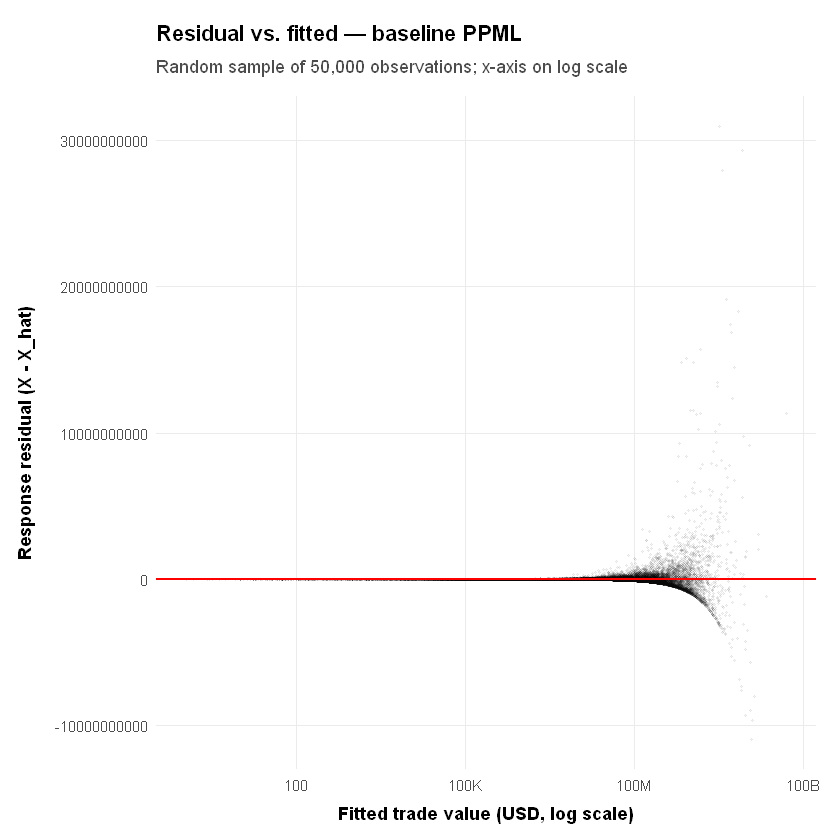

In [24]:
# --- 4.1 Pseudo-R^2 ----------------------------------------------------------

# Definition follows Silva & Tenreyro (2006): squared correlation between
# observed trade and PPML fitted values, computed on the estimation sample.
# fixest::fitted() and residuals() both return values aligned to the rows
# actually used in fitting (after singleton and zero-FE-group drops per
# Correia 2015), so observed = fitted + response-residual is automatically
# the right length.

pseudo_r2 <- function(fit) {
  fv <- as.numeric(fitted(fit, type = "response"))
  rs <- as.numeric(residuals(fit, type = "response"))
  obs <- fv + rs
  cor(obs, fv, use = "complete.obs")^2
}

cat("--- Pseudo-R^2 (squared correlation, observed vs fitted) ---\n")
all_fits <- list()
for (nm in c("m_baseline", "m_count", "m_lead",
             "m_digital", "m_product", "m_with_policy",
             "m_event", "m_high_data",
             "m_inc_high", "m_inc_low", "m_income_int",
             "m_spec_a",  "m_spec_b",  "m_spec_c")) {
  if (exists(nm) && !is.null(get(nm))) {
    all_fits[[nm]] <- get(nm)
  }
}
for (nm in names(all_fits)) {
  r2 <- tryCatch(pseudo_r2(all_fits[[nm]]), error = function(e) NA_real_)
  cat(sprintf("  %-18s  pseudo-R^2 = %s\n",
              nm,
              if (is.na(r2)) "NA" else sprintf("%.4f", r2)))
}

# --- 4.2 Residual-vs-fitted plot for the baseline ----------------------------

base_fit   <- as.numeric(fitted(m_baseline, type = "response"))
base_resid <- as.numeric(residuals(m_baseline, type = "response"))

# Both vectors have the same length (the estimation sample), so the data
# frame builds cleanly with no row mismatch.
resid_df <- data.frame(fitted = base_fit, residual = base_resid)
set.seed(42)
resid_sample <- resid_df %>% sample_n(min(50000, n()))

p_resid <- ggplot(resid_sample, aes(x = fitted + 1, y = residual)) +
  geom_point(alpha = 0.05, size = 0.4) +
  geom_hline(yintercept = 0, colour = "red", linewidth = 0.6) +
  scale_x_log10(labels = scales::label_number(scale_cut = scales::cut_short_scale())) +
  labs(title    = "Residual vs. fitted — baseline PPML",
       subtitle = "Random sample of 50,000 observations; x-axis on log scale",
       x = "Fitted trade value (USD, log scale)",
       y = "Response residual (X - X_hat)")

ggsave(file.path(FIGURES_DIR, "fig_residuals_vs_fitted.png"),
       p_resid, width = 10, height = 6, dpi = 300, bg = "white")
print(p_resid)

# --- 4.3 Overdispersion ratio ------------------------------------------------

dispersion_ratio <- sum(base_resid^2 / pmax(base_fit, 1e-9), na.rm = TRUE) /
                    df.residual(m_baseline)
cat(sprintf("\nOverdispersion ratio (Pearson): %.2f (Poisson null = 1.0)\n",
            dispersion_ratio))
if (dispersion_ratio > 5) {
  cat("Note: substantial overdispersion — PPML coefficients remain consistent\n")
  cat("but inference relies on cluster-robust standard errors. The cluster on\n")
  cat("pair_id used in all specifications handles this directly.\n")
}

# --- 4.4 RESET test for functional-form misspecification --------------------

# Ramsey RESET: regress trade on the original regressors PLUS the squared
# linear predictor on the SAME estimation sample. A significant coefficient
# on the squared term flags functional-form misspecification (Wooldridge
# 2010, ch. 9).
#
# Two technical fixes vs. the textbook version:
#   1. fixest drops singletons and all-zero FE groups (Correia 2015), so
#      predict(fit) returns FEWER rows than nrow(df). We use
#      fit$obs_selection$obsRemoved to subset df down to the kept rows.
#   2. R's update.formula() chokes on fixest's two-part formula syntax
#      (LHS | FE) because it treats the FE block as a numeric expression
#      and tries to evaluate `imp_time + exp_prod_time` as addition on
#      character vectors. We build the augmented formula manually via
#      as.formula() to avoid this.

cat("\n--- RESET test on m_baseline ---\n")

reset_test <- function(fit, df_full) {
  lin_pred <- predict(fit, type = "link")

  removed_idx <- fit$obs_selection$obsRemoved
  if (is.null(removed_idx) || length(removed_idx) == 0) {
    used_idx <- seq_len(nrow(df_full))
  } else {
    used_idx <- seq_len(nrow(df_full))[removed_idx]
  }

  if (length(used_idx) != length(lin_pred)) {
    cat(sprintf("  RESET aborted: lengths disagree (used=%d, predicted=%d)\n",
                length(used_idx), length(lin_pred)))
    return(invisible(NULL))
  }

  reset_df <- df_full[used_idx, , drop = FALSE]
  reset_df$lin_pred_sq <- as.numeric(lin_pred)^2

  # Build the augmented formula manually — matches m_baseline's structure plus
  # the new squared-predictor regressor. NOTE: imp_time, not imp_prod_time,
  # because imp_prod_time would absorb dlr and break the level test.
  reset_formula <- as.formula(
    "trade ~ dlr + lin_pred_sq | imp_time + exp_prod_time + pair_prod"
  )

  fit_reset <- fepois(
    reset_formula,
    data    = reset_df,
    cluster = ~ pair_id
  )

  ct <- summary(fit_reset)$coeftable
  if ("lin_pred_sq" %in% rownames(ct)) {
    cat(sprintf("  Coefficient on squared linear predictor: %.4f\n",
                ct["lin_pred_sq", 1]))
    cat(sprintf("  Standard error:                         %.4f\n",
                ct["lin_pred_sq", 2]))
    cat(sprintf("  p-value:                                %.4g\n",
                ct["lin_pred_sq", 4]))
    if (ct["lin_pred_sq", 4] < 0.05) {
      cat("  -> Reject H0 of correct functional form (p < 0.05). Consider\n")
      cat("     alternative functional forms or additional interactions.\n")
    } else {
      cat("  -> Cannot reject H0 of correct functional form (p >= 0.05).\n")
    }
  } else {
    cat("  RESET: lin_pred_sq dropped (collinearity with FE).\n")
  }
  invisible(fit_reset)
}

m_reset <- tryCatch(reset_test(m_baseline, df), error = function(e) {
  cat(sprintf("  RESET test failed: %s\n", e$message))
  NULL
})

# --- 4.5 Heteroscedasticity diagnostic --------------------------------------

# Correlation between squared residuals and the linear predictor. PPML
# coefficient estimates are robust to many forms of heteroscedasticity; this
# diagnostic is descriptive only. A low correlation confirms that the
# multiplicative-error structure assumed by PPML matches the data.

cat("\n--- Heteroscedasticity diagnostic on m_baseline ---\n")
lin_pred  <- as.numeric(predict(m_baseline, type = "link"))
resids_sq <- base_resid^2
if (length(resids_sq) == length(lin_pred)) {
  cor_sq <- cor(resids_sq, lin_pred, use = "complete.obs")
  cat(sprintf("  Correlation(squared residuals, linear predictor) = %.4f\n", cor_sq))
  cat("  Note: PPML cluster-robust SEs (used throughout) handle\n")
  cat("        heteroscedasticity by construction; this diagnostic is\n")
  cat("        descriptive only.\n")
} else {
  cat(sprintf("  Length mismatch — skipped (resids=%d, lin_pred=%d).\n",
              length(resids_sq), length(lin_pred)))
}

# --- 4.6 Influence — top observations by absolute residual ------------------

# Align identification columns (importer, exporter, bpm6, year) to the
# estimation sample so the residuals can be attributed to specific rows.

removed_idx <- m_baseline$obs_selection$obsRemoved
if (is.null(removed_idx) || length(removed_idx) == 0) {
  used_idx <- seq_len(nrow(df))
} else {
  used_idx <- seq_len(nrow(df))[removed_idx]
}

if (length(used_idx) == length(base_resid)) {
  infl <- data.frame(
    importer = df$importer[used_idx],
    exporter = df$exporter[used_idx],
    bpm6     = df$bpm6_category[used_idx],
    year     = df$year[used_idx],
    fitted   = base_fit,
    resid    = base_resid
  ) %>%
    arrange(desc(abs(resid))) %>%
    head(20)

  cat("\n--- Top 20 observations by |residual| ---\n")
  print(infl)

  readr::write_csv(infl, file.path(TABLES_DIR, "top_residuals.csv"))
  cat(sprintf("Saved: %s\n", file.path(TABLES_DIR, "top_residuals.csv")))
} else {
  cat(sprintf("\n--- Top residuals skipped: length mismatch ---\n"))
  cat(sprintf("    used_idx = %d, base_resid = %d\n",
              length(used_idx), length(base_resid)))
}

cat("\nSection 4 complete.\n")

<a id="section-5"></a>
<div style="font-size: 25px; line-height: 1.25;">
SECTION 5 — EXPORT
</div>

This final section serialises (a) all regression results into a single consolidated Excel workbook plus a tidy CSV, (b) the fitted model objects as an `.rds` file for later re-loading, and (c) the prepared dataset as an `.rds` file so that downstream analysis can resume without re-running the entire pipeline. A completion summary at the end lists every output file written by the notebook.

### 5.1 — Consolidated results workbook

`all_results_consolidated.xlsx` contains six sheets:

* **`readme`** — a cover sheet documenting what each subsequent sheet contains and how to interpret the columns.
* **`coefficients_long`** — every coefficient × model × variable as one row, with estimate, cluster-robust standard error, z-statistic, p-value, significance stars, and 95% confidence interval bounds. This is the format for downstream programmatic use (e.g., re-plotting in Stata or Python).
* **`headline_wide`** — Models 1-8 in publication-table format: one row per variable, one column per model. Each cell contains "estimate (SE) [stars]". This is the format to paste into the thesis appendix.
* **`classic_wide`** — Specs A/B/C from Section 3d in the same publication-table format.
* **`model_stats`** — one row per model with N, pseudo-R², log-likelihood, BIC, AIC, formula, fixed-effect structure, and cluster variable.
* **`elasticity_summary`** — for binary regressors and the count regressor, the implied percent change in trade $(\exp(\hateta) - 1) 	imes 100\%$ with the 95% confidence interval transformed the same way. This is what to quote in prose.

A parallel `all_results_long.csv` is also written for users who prefer the long-format CSV without Excel.

In [25]:
# --- 5.1 Consolidated results export ----------------------------------------

# Build a single Excel workbook plus a tidy CSV containing every coefficient,
# standard error, p-value, and goodness-of-fit measure from all 8 headline
# models plus the 3 classic-gravity specs in Section 3d. This is the
# thesis-friendly export — everything in one place, ready to paste into the
# manuscript.

if (!requireNamespace("writexl", quietly = TRUE)) {
  install.packages("writexl", repos = "https://cloud.r-project.org")
}
if (!requireNamespace("broom", quietly = TRUE)) {
  install.packages("broom", repos = "https://cloud.r-project.org")
}
suppressPackageStartupMessages({
  library(writexl)
  library(broom)
})

cat("\n--- Building consolidated results workbook ---\n")

# Significance stars helper (matches modelsummary conventions).
sig_stars <- function(p) {
  ifelse(is.na(p), "",
    ifelse(p < 0.01,  "***",
      ifelse(p < 0.05,  "**",
        ifelse(p < 0.10,  "*", ""))))
}

# A safe-tidy that handles fixest models including those with NULL coefficients
# (e.g., fully-collinear-with-FE variables that fixest drops silently).
safe_tidy <- function(fit) {
  if (is.null(fit)) return(NULL)
  tryCatch({
    td <- broom::tidy(fit, conf.int = TRUE)
    td
  }, error = function(e) {
    # Fall back to manual extraction from $coeftable
    ct <- summary(fit)$coeftable
    data.frame(
      term      = rownames(ct),
      estimate  = ct[, 1],
      std.error = ct[, 2],
      statistic = ct[, 3],
      p.value   = ct[, 4],
      conf.low  = ct[, 1] - 1.96 * ct[, 2],
      conf.high = ct[, 1] + 1.96 * ct[, 2],
      stringsAsFactors = FALSE
    )
  })
}

# --- Assemble the master models list -----------------------------------------

all_models <- list()

# Headline models (Section 3a-3b). m_with_policy may be NULL if no gravity controls.
for (nm in c("m_baseline", "m_count", "m_lead",
             "m_digital", "m_product", "m_with_policy",
             "m_event", "m_high_data",
             "m_inc_high", "m_inc_low", "m_income_int")) {
  if (exists(nm) && !is.null(get(nm))) {
    all_models[[nm]] <- get(nm)
  }
}

# Classic gravity models (Section 3d) — may not exist if has_gravity_controls FALSE.
for (nm in c("m_spec_a", "m_spec_b", "m_spec_c")) {
  if (exists(nm) && !is.null(get(nm))) {
    all_models[[nm]] <- get(nm)
  }
}

# Human-readable model labels — map internal names to display labels.
model_labels <- c(
  m_baseline    = "(1) Baseline any P6 DLR",
  m_count       = "(2) Count of active P6 regulations",
  m_lead        = "(3) Forward lead (placebo)",
  m_digital     = "(4) DLR x Exporter digital share",
  m_product     = "(5) DLR x Digital product",
  m_with_policy = "(6) DLR + trade policy controls",
  m_event       = "(7) Event study (leads/lags)",
  m_high_data   = "(8) DLR x High-data Telecom",
  m_inc_high    = "(9a) Baseline on high-income exporters",
  m_inc_low     = "(9b) Baseline on middle/lower-income exporters",
  m_income_int  = "(9) DLR x exporter income (interacted)",
  m_spec_a      = "Spec A: Tinbergen (year FE)",
  m_spec_b      = "Spec B: AvW 2003 (imp-time + exp-time FE)",
  m_spec_c      = "Spec C: ALY 2018 (+ pair FE)"
)

# Which table each model belongs to.
model_table <- c(
  m_baseline = "headline", m_count = "headline",
  m_lead = "headline", m_digital = "headline",
  m_product = "headline", m_with_policy = "headline",
  m_event = "extensions", m_high_data = "extensions",
  m_inc_high = "heterogeneity", m_inc_low = "heterogeneity",
  m_income_int = "heterogeneity",
  m_spec_a = "classic", m_spec_b = "classic", m_spec_c = "classic"
)

cat(sprintf("Assembled %d models for export: %s\n",
            length(all_models), paste(names(all_models), collapse = ", ")))

# --- Build the long-format coefficient table ---------------------------------

coef_long <- purrr::map_dfr(names(all_models), function(nm) {
  td <- safe_tidy(all_models[[nm]])
  if (is.null(td) || nrow(td) == 0) return(NULL)
  td %>%
    mutate(model_internal = nm,
           model          = model_labels[[nm]],
           table          = model_table[[nm]],
           stars          = sig_stars(p.value)) %>%
    select(table, model, model_internal, term,
           estimate, std.error, statistic, p.value, stars,
           conf.low, conf.high)
})

# Re-order columns for readability.
coef_long <- coef_long %>%
  select(table, model, model_internal, variable = term,
         estimate, std_error = std.error,
         z_stat = statistic, p_value = p.value, signif = stars,
         ci_low_95 = conf.low, ci_high_95 = conf.high)

cat(sprintf("  Coefficients table: %d rows\n", nrow(coef_long)))

# --- Build the wide-format publication tables --------------------------------

# Map raw fixest term names to human-readable variable labels.
var_labels <- c(
  "dlr_any"                       = "DLR (any active P6 regulation)",
  "dlr_any_count"                 = "Count of active P6 regulations",
  "dlr_any_lead2"                 = "DLR (forward lead, t+2)",
  "dlr_any:exp_digital_share_c"   = "DLR x Exporter digital share (demeaned)",
  "dlr_any:is_digital"            = "DLR x Digital product",
  "dlr_any:is_high_data"          = "DLR x High data-intensity",
  "dlr_any:is_high_inc"           = "DLR x High-income exporter",
  "dlr_any_lead2"                 = "DLR (lead, t-2)",
  "dlr_any_lead1"                 = "DLR (lead, t-1)",
  "dlr_any_lag1"                  = "DLR (lag, t+1)",
  "dlr_any_lag2"                  = "DLR (lag, t+2)",
  "both_wto"                      = "Both WTO members",
  "both_eu"                       = "Both EU members",
  "rta_services"                  = "RTA covers services",
  "log_dist"                      = "log Distance",
  "log_gdp_o"                     = "log GDP (exporter)",
  "log_gdp_d"                     = "log GDP (importer)",
  "contig"                        = "Contiguity",
  "comlang_off"                   = "Common official language",
  "col45"                         = "Colonial relationship (post-1945)",
  "log_sci"                       = "log Social Connectedness Index"
)

build_wide_table <- function(long_df, table_name) {
  d <- long_df %>%
    filter(table == table_name) %>%
    mutate(
      variable_label = ifelse(variable %in% names(var_labels),
                               var_labels[variable], variable),
      cell = sprintf("%.4f (%.4f)%s", estimate, std_error, signif)
    )
  if (nrow(d) == 0) return(NULL)
  d %>%
    select(variable_label, model, cell) %>%
    tidyr::pivot_wider(names_from = model, values_from = cell, values_fill = "")
}

headline_wide <- build_wide_table(coef_long, "headline")
classic_wide  <- build_wide_table(coef_long, "classic")

cat(sprintf("  Headline wide table: %d variables x %d models\n",
            ifelse(is.null(headline_wide), 0, nrow(headline_wide)),
            ifelse(is.null(headline_wide), 0, ncol(headline_wide) - 1)))
cat(sprintf("  Classic wide table:  %d variables x %d models\n",
            ifelse(is.null(classic_wide), 0, nrow(classic_wide)),
            ifelse(is.null(classic_wide), 0, ncol(classic_wide) - 1)))

# --- Build the model-stats table ---------------------------------------------

model_stats <- purrr::map_dfr(names(all_models), function(nm) {
  fit <- all_models[[nm]]
  if (is.null(fit)) return(NULL)

  # Pseudo-R^2: squared correlation between observed and fitted on the
  # estimation sample. Wrap in tryCatch for safety.
  pseudo_r2 <- tryCatch({
    fv <- as.numeric(fitted(fit))
    rs <- as.numeric(residuals(fit, type = "response"))
    cor(fv + rs, fv, use = "complete.obs")^2
  }, error = function(e) NA_real_)

  fe_str <- tryCatch(
    paste(fit$fixef_vars, collapse = " + "),
    error = function(e) NA_character_
  )

  formula_str <- tryCatch(
    deparse(formula(fit))[1],
    error = function(e) NA_character_
  )

  data.frame(
    model          = model_labels[[nm]],
    model_internal = nm,
    table          = model_table[[nm]],
    formula        = formula_str,
    fixed_effects  = fe_str,
    cluster        = "pair_id",
    n_obs          = tryCatch(nobs(fit), error = function(e) NA_integer_),
    pseudo_r2      = round(pseudo_r2, 4),
    log_lik        = tryCatch(as.numeric(logLik(fit)),
                               error = function(e) NA_real_),
    aic            = tryCatch(AIC(fit), error = function(e) NA_real_),
    bic            = tryCatch(BIC(fit), error = function(e) NA_real_),
    stringsAsFactors = FALSE
  )
})

cat(sprintf("  Model stats table: %d models\n", nrow(model_stats)))

# --- Build the elasticity-summary table --------------------------------------

# For binary indicators and counts, percent-change interpretation is
# (exp(beta) - 1) * 100. Computed for all rows in coef_long; users can filter
# in Excel to the variables they care about.

elasticity_summary <- coef_long %>%
  mutate(
    pct_change_est   = round(100 * (exp(estimate)  - 1), 2),
    pct_change_ci_lo = round(100 * (exp(ci_low_95) - 1), 2),
    pct_change_ci_hi = round(100 * (exp(ci_high_95)- 1), 2)
  ) %>%
  select(table, model, variable, estimate, std_error,
         pct_change_est, pct_change_ci_lo, pct_change_ci_hi,
         p_value, signif)

# --- Build the README sheet --------------------------------------------------

readme_df <- data.frame(
  sheet = c("readme", "coefficients_long", "headline_wide",
            "classic_wide", "model_stats", "elasticity_summary"),
  description = c(
    "This sheet — describes what every other sheet contains.",
    "One row per (model x variable). Columns: estimate, std_error, z_stat, p_value, signif stars, 95% CI bounds.",
    "Models 1-8 in publication-table format. Cells are 'estimate (SE)' followed by significance stars.",
    "Section 3d Specs A/B/C in publication-table format. Same cell format as headline_wide.",
    "One row per model: N obs, pseudo-R^2, log-likelihood, AIC, BIC, formula, fixed effects, cluster variable.",
    "Percent-change interpretation: (exp(beta)-1)*100 with 95% CI transformed the same way. Quote this in prose."
  ),
  stringsAsFactors = FALSE
)

# --- Write the Excel workbook ------------------------------------------------

sheets <- list(
  readme              = readme_df,
  coefficients_long   = coef_long,
  headline_wide       = headline_wide,
  classic_wide        = classic_wide,
  model_stats         = model_stats,
  elasticity_summary  = elasticity_summary
)

# Drop NULL sheets (e.g., classic_wide if Section 3d didn't run).
sheets <- sheets[!sapply(sheets, is.null)]

writexl::write_xlsx(sheets, path = ALL_RESULTS_XLSX)
cat(sprintf("Saved: %s (%.1f KB)\n",
            ALL_RESULTS_XLSX,
            file.info(ALL_RESULTS_XLSX)$size / 1e3))

# Also write the long-format coefficients to a standalone CSV.
readr::write_csv(coef_long, ALL_RESULTS_CSV)
cat(sprintf("Saved: %s\n", ALL_RESULTS_CSV))

# --- 5.2 Save fitted models ---------------------------------------------------

saveRDS(all_models, MODELS_RDS)
cat(sprintf("\nSaved fitted models: %s\n", MODELS_RDS))

# --- 5.3 Save the prepared dataset -------------------------------------------

# Drop the helper column that is only needed inside the RESET test.
df_to_save <- df %>% select(-any_of(c("lin_pred_baseline",
                                       "lin_pred_baseline_sq")))
saveRDS(df_to_save, FINAL_DATA_RDS)
cat(sprintf("Saved gravity dataset: %s (%.1f MB)\n",
            FINAL_DATA_RDS,
            file.info(FINAL_DATA_RDS)$size / 1e6))

# --- 5.4 Completion summary --------------------------------------------------

cat("\n+----------------------------------------------------------------+\n")
cat(  "|   GRAVITY PIPELINE COMPLETE                                    |\n")
cat(  "+----------------------------------------------------------------+\n\n")

list_dir_contents <- function(d, label) {
  if (!dir.exists(d)) {
    cat(sprintf("  %s — directory missing\n", label))
    return(invisible())
  }
  files <- list.files(d, full.names = TRUE)
  cat(sprintf("  %s (%d files):\n", label, length(files)))
  for (f in files) {
    sz <- file.info(f)$size
    cat(sprintf("    %s  (%s)\n", basename(f),
                if (sz > 1e6) sprintf("%.1f MB", sz / 1e6)
                else sprintf("%.1f KB", sz / 1e3)))
  }
}

list_dir_contents(TABLES_DIR,  "Tables")
list_dir_contents(FIGURES_DIR, "Figures")
cat(sprintf("\n  Models RDS:    %s\n", MODELS_RDS))
cat(sprintf("  Dataset RDS:   %s\n", FINAL_DATA_RDS))
cat(sprintf("  Consolidated:  %s\n", ALL_RESULTS_XLSX))

cat("\nDone.\n")


--- Building consolidated results workbook ---
Assembled 14 models for export: m_baseline, m_count, m_lead, m_digital, m_product, m_with_policy, m_event, m_high_data, m_inc_high, m_inc_low, m_income_int, m_spec_a, m_spec_b, m_spec_c
  Coefficients table: 44 rows
  Headline wide table: 8 variables x 6 models
  Classic wide table:  10 variables x 3 models
  Model stats table: 14 models
Saved: ../outputs/gravity_results/tables/all_results_consolidated.xlsx (20.3 KB)
Saved: ../outputs/gravity_results/tables/all_results_long.csv

Saved fitted models: ../outputs/gravity_results/fitted_models.rds
Saved gravity dataset: ../outputs/gravity_results/gravity_dataset.rds (36.4 MB)

+----------------------------------------------------------------+
|   GRAVITY PIPELINE COMPLETE                                    |
+----------------------------------------------------------------+

  Tables (14 files):
    all_results_consolidated.xlsx  (20.3 KB)
    all_results_long.csv  (8.2 KB)
    classic_gravit